# 用测试数据来测试test的

## 计算很多种数据类型

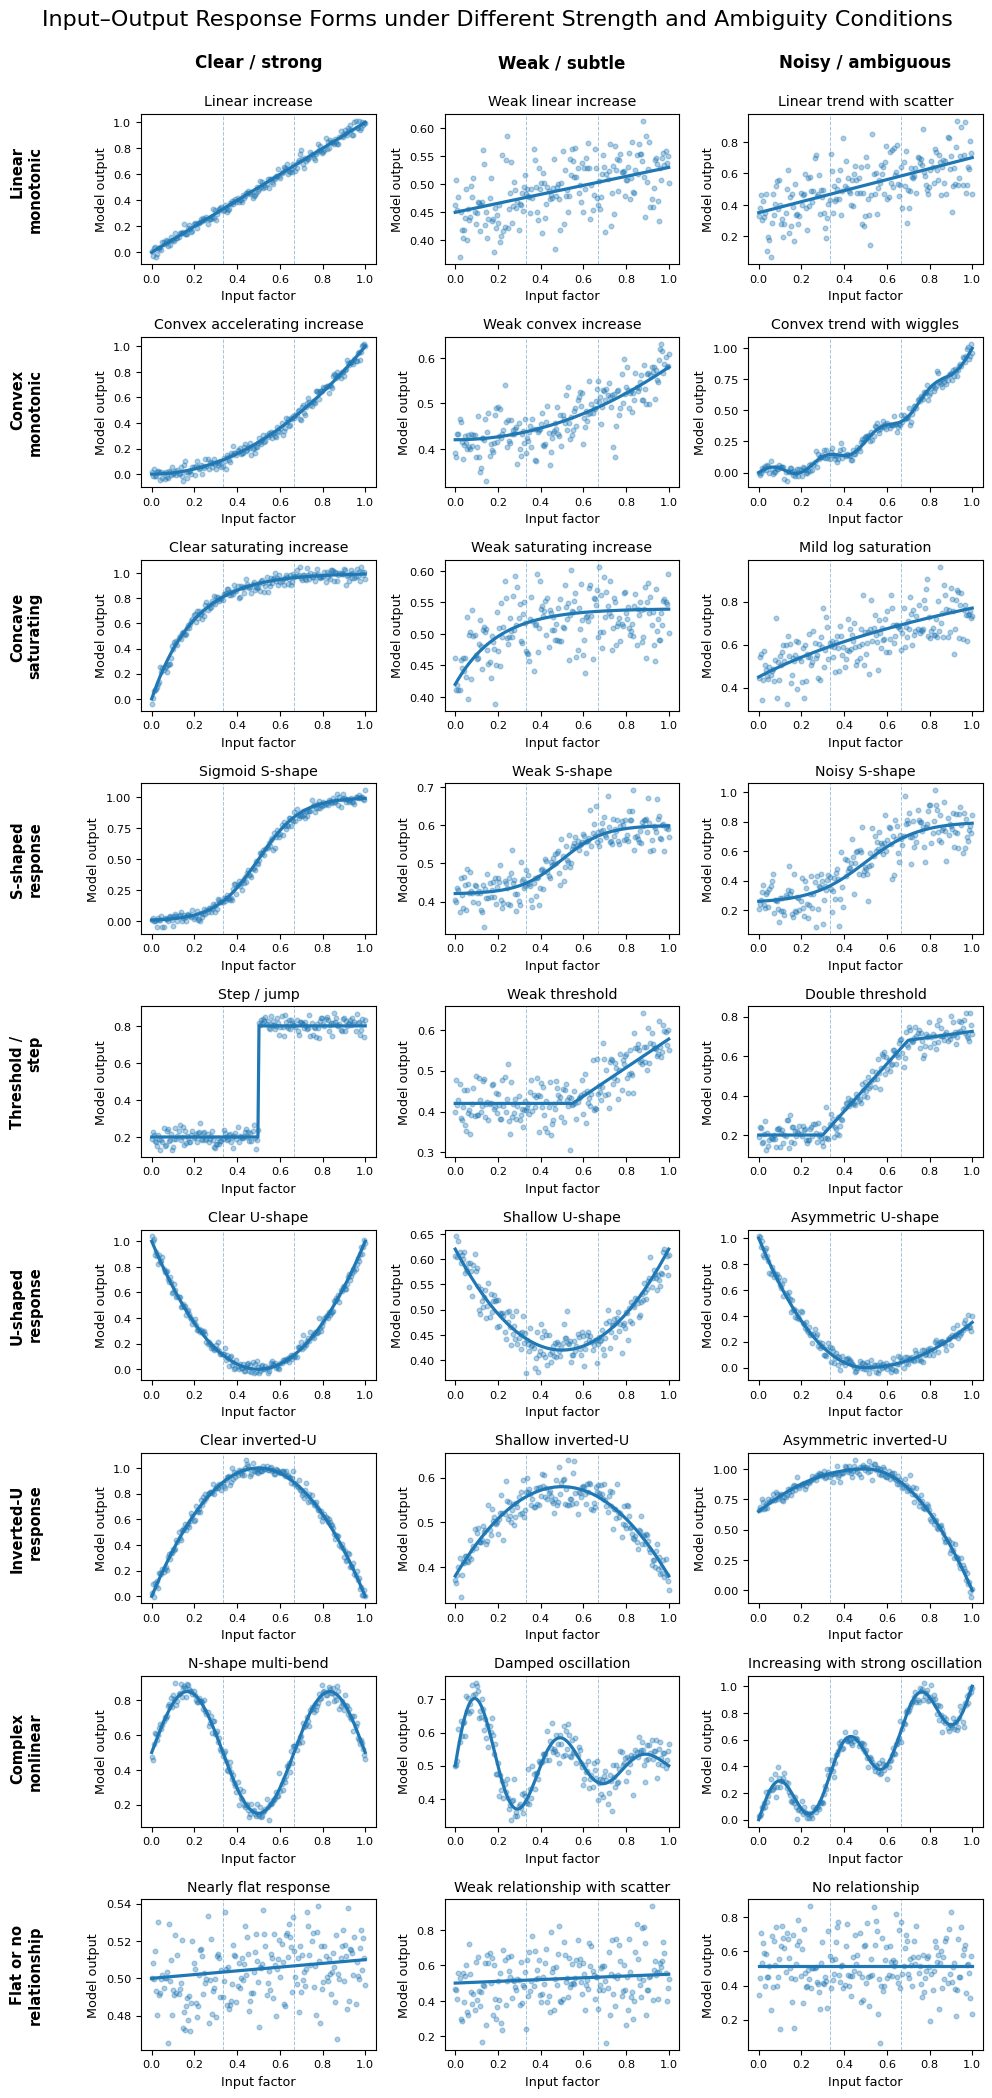

In [4]:
import numpy as np
import matplotlib.pyplot as plt


def plot_response_form_matrix(
    form_matrix,
    n=200,
    noise_default=0.035,
    seed=42,
    figsize=(13, 21),
    show_stage_dividers=True,
):
    rng = np.random.default_rng(seed)

    row_names = list(form_matrix.keys())
    col_names = list(next(iter(form_matrix.values())).keys())

    n_rows = len(row_names)
    n_cols = len(col_names)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=figsize,
        sharex=False,
        sharey=False
    )

    for i, row_name in enumerate(row_names):
        for j, col_name in enumerate(col_names):

            ax = axes[i, j]

            case = form_matrix[row_name][col_name]
            title = case["title"]
            func = case["func"]
            noise = case.get("noise", noise_default)
            x_range = case.get("x_range", (0, 1))

            xmin, xmax = x_range
            x = np.linspace(xmin, xmax, n)
            y_true = func(x)

            if case.get("fit_type", "curve") == "flat":
                y_scatter = y_true
                y_fit = np.full_like(x, np.nanmean(y_true))
            else:
                y_scatter = y_true + noise * rng.standard_normal(n)
                y_fit = y_true

            ax.scatter(x, y_scatter, s=11, alpha=0.35)
            ax.plot(x, y_fit, linewidth=2.3)

            if show_stage_dividers:
                x1 = xmin + (xmax - xmin) / 3
                x2 = xmin + 2 * (xmax - xmin) / 3
                ax.axvline(x1, linestyle="--", linewidth=0.7, alpha=0.42)
                ax.axvline(x2, linestyle="--", linewidth=0.7, alpha=0.42)

            ax.set_title(title, fontsize=10.2)
            ax.set_xlabel("Input factor", fontsize=9.2)
            ax.set_ylabel("Model output", fontsize=9.2)
            ax.tick_params(axis="both", labelsize=8.2)

            if j == 0:
                ax.annotate(
                    row_name,
                    xy=(-0.42, 0.5),
                    xycoords="axes fraction",
                    ha="right",
                    va="center",
                    fontsize=10.5,
                    fontweight="bold",
                    rotation=90
                )

            if i == 0:
                ax.annotate(
                    col_name,
                    xy=(0.5, 1.28),
                    xycoords="axes fraction",
                    ha="center",
                    va="bottom",
                    fontsize=12,
                    fontweight="bold"
                )

    plt.suptitle(
        "Input–Output Response Forms under Different Strength and Ambiguity Conditions",
        fontsize=16,
        y=0.997
    )

    plt.tight_layout()
    plt.show()


form_matrix = {
    "Linear\nmonotonic": {
        "Clear / strong": {
            "title": "Linear increase",
            "func": lambda x: x,
            "noise": 0.03,
        },
        "Weak / subtle": {
            "title": "Weak linear increase",
            "func": lambda x: 0.08 * x + 0.45,
            "noise": 0.04,
        },
        "Noisy / ambiguous": {
            "title": "Linear trend with scatter",
            "func": lambda x: 0.35 * x + 0.35,
            "noise": 0.13,
        },
    },

    "Convex\nmonotonic": {
        "Clear / strong": {
            "title": "Convex accelerating increase",
            "func": lambda x: x**2,
            "noise": 0.03,
        },
        "Weak / subtle": {
            "title": "Weak convex increase",
            "func": lambda x: 0.16 * x**2 + 0.42,
            "noise": 0.035,
        },
        "Noisy / ambiguous": {
            "title": "Convex trend with wiggles",
            "func": lambda x: x**2 + 0.04 * np.sin(8 * np.pi * x),
            "noise": 0.035,
        },
    },

    "Concave\nsaturating": {
        "Clear / strong": {
            "title": "Clear saturating increase",
            "func": lambda x: 1 - np.exp(-5 * x),
            "noise": 0.03,
        },
        "Weak / subtle": {
            "title": "Weak saturating increase",
            "func": lambda x: 0.12 * (1 - np.exp(-5 * x)) + 0.42,
            "noise": 0.035,
        },
        "Noisy / ambiguous": {
            "title": "Mild log saturation",
            "func": lambda x: 0.45 + 0.35 * np.log1p(1.5 * x),
            "noise": 0.08,
        },
    },

    "S-shaped\nresponse": {
        "Clear / strong": {
            "title": "Sigmoid S-shape",
            "func": lambda x: 1 / (1 + np.exp(-10 * (x - 0.5))),
            "noise": 0.03,
        },
        "Weak / subtle": {
            "title": "Weak S-shape",
            "func": lambda x: 0.42 + 0.18 / (1 + np.exp(-10 * (x - 0.5))),
            "noise": 0.035,
        },
        "Noisy / ambiguous": {
            "title": "Noisy S-shape",
            "func": lambda x: 0.25 + 0.55 / (1 + np.exp(-8 * (x - 0.5))),
            "noise": 0.10,
        },
    },

    "Threshold /\nstep": {
        "Clear / strong": {
            "title": "Step / jump",
            "func": lambda x: np.where(x < 0.5, 0.2, 0.8),
            "noise": 0.03,
        },
        "Weak / subtle": {
            "title": "Weak threshold",
            "func": lambda x: np.where(
                x < 0.55,
                0.42,
                0.42 + 0.35 * (x - 0.55)
            ),
            "noise": 0.04,
        },
        "Noisy / ambiguous": {
            "title": "Double threshold",
            "func": lambda x: np.piecewise(
                x,
                [x < 0.3, (x >= 0.3) & (x < 0.7), x >= 0.7],
                [
                    lambda x: 0.2,
                    lambda x: 0.2 + 1.2 * (x - 0.3),
                    lambda x: 0.68 + 0.15 * (x - 0.7),
                ],
            ),
            "noise": 0.04,
        },
    },

    "U-shaped\nresponse": {
        "Clear / strong": {
            "title": "Clear U-shape",
            "func": lambda x: 4 * (x - 0.5) ** 2,
            "noise": 0.03,
        },
        "Weak / subtle": {
            "title": "Shallow U-shape",
            "func": lambda x: 0.20 * (2 * x - 1.0) ** 2 + 0.42,
            "noise": 0.025,
        },
        "Noisy / ambiguous": {
            "title": "Asymmetric U-shape",
            "func": lambda x: np.where(
                x < 0.5,
                4 * (x - 0.5) ** 2,
                1.4 * (x - 0.5) ** 2,
            ),
            "noise": 0.035,
        },
    },

    "Inverted-U\nresponse": {
        "Clear / strong": {
            "title": "Clear inverted-U",
            "func": lambda x: 1 - 4 * (x - 0.5) ** 2,
            "noise": 0.03,
        },
        "Weak / subtle": {
            "title": "Shallow inverted-U",
            "func": lambda x: 0.58 - 0.20 * (2 * x - 1.0) ** 2,
            "noise": 0.025,
        },
        "Noisy / ambiguous": {
            "title": "Asymmetric inverted-U",
            "func": lambda x: np.where(
                x < 0.5,
                1 - 1.4 * (x - 0.5) ** 2,
                1 - 4 * (x - 0.5) ** 2,
            ),
            "noise": 0.035,
        },
    },

    "Complex\nnonlinear": {
        "Clear / strong": {
            "title": "N-shape multi-bend",
            "func": lambda x: 0.5 + 0.35 * np.sin(3 * np.pi * x),
            "noise": 0.03,
        },
        "Weak / subtle": {
            "title": "Damped oscillation",
            "func": lambda x: 0.5 + 0.25 * np.exp(-2.2 * x) * np.sin(5 * np.pi * x),
            "noise": 0.035,
        },
        "Noisy / ambiguous": {
            "title": "Increasing with strong oscillation",
            "func": lambda x: x + 0.20 * np.sin(6 * np.pi * x),
            "noise": 0.04,
        },
    },

    "Flat or no\nrelationship": {
        "Clear / strong": {
            "title": "Nearly flat response",
            "func": lambda x: 0.01 * x + 0.5,
            "noise": 0.015,
        },
        "Weak / subtle": {
            "title": "Weak relationship with scatter",
            "func": lambda x: 0.05 * x + 0.5,
            "noise": 0.13,
        },
        "Noisy / ambiguous": {
            "title": "No relationship",
            "func": lambda x: np.random.default_rng(123).normal(0.5, 0.16, len(x)),
            "noise": 0.0,
            "fit_type": "flat",
        },
    },
}


plot_response_form_matrix(
    form_matrix=form_matrix,
    n=200,
    noise_default=0.035,
    seed=42,
    figsize=(10, 21),
    show_stage_dividers=True
)

### 不画线，标题画图上

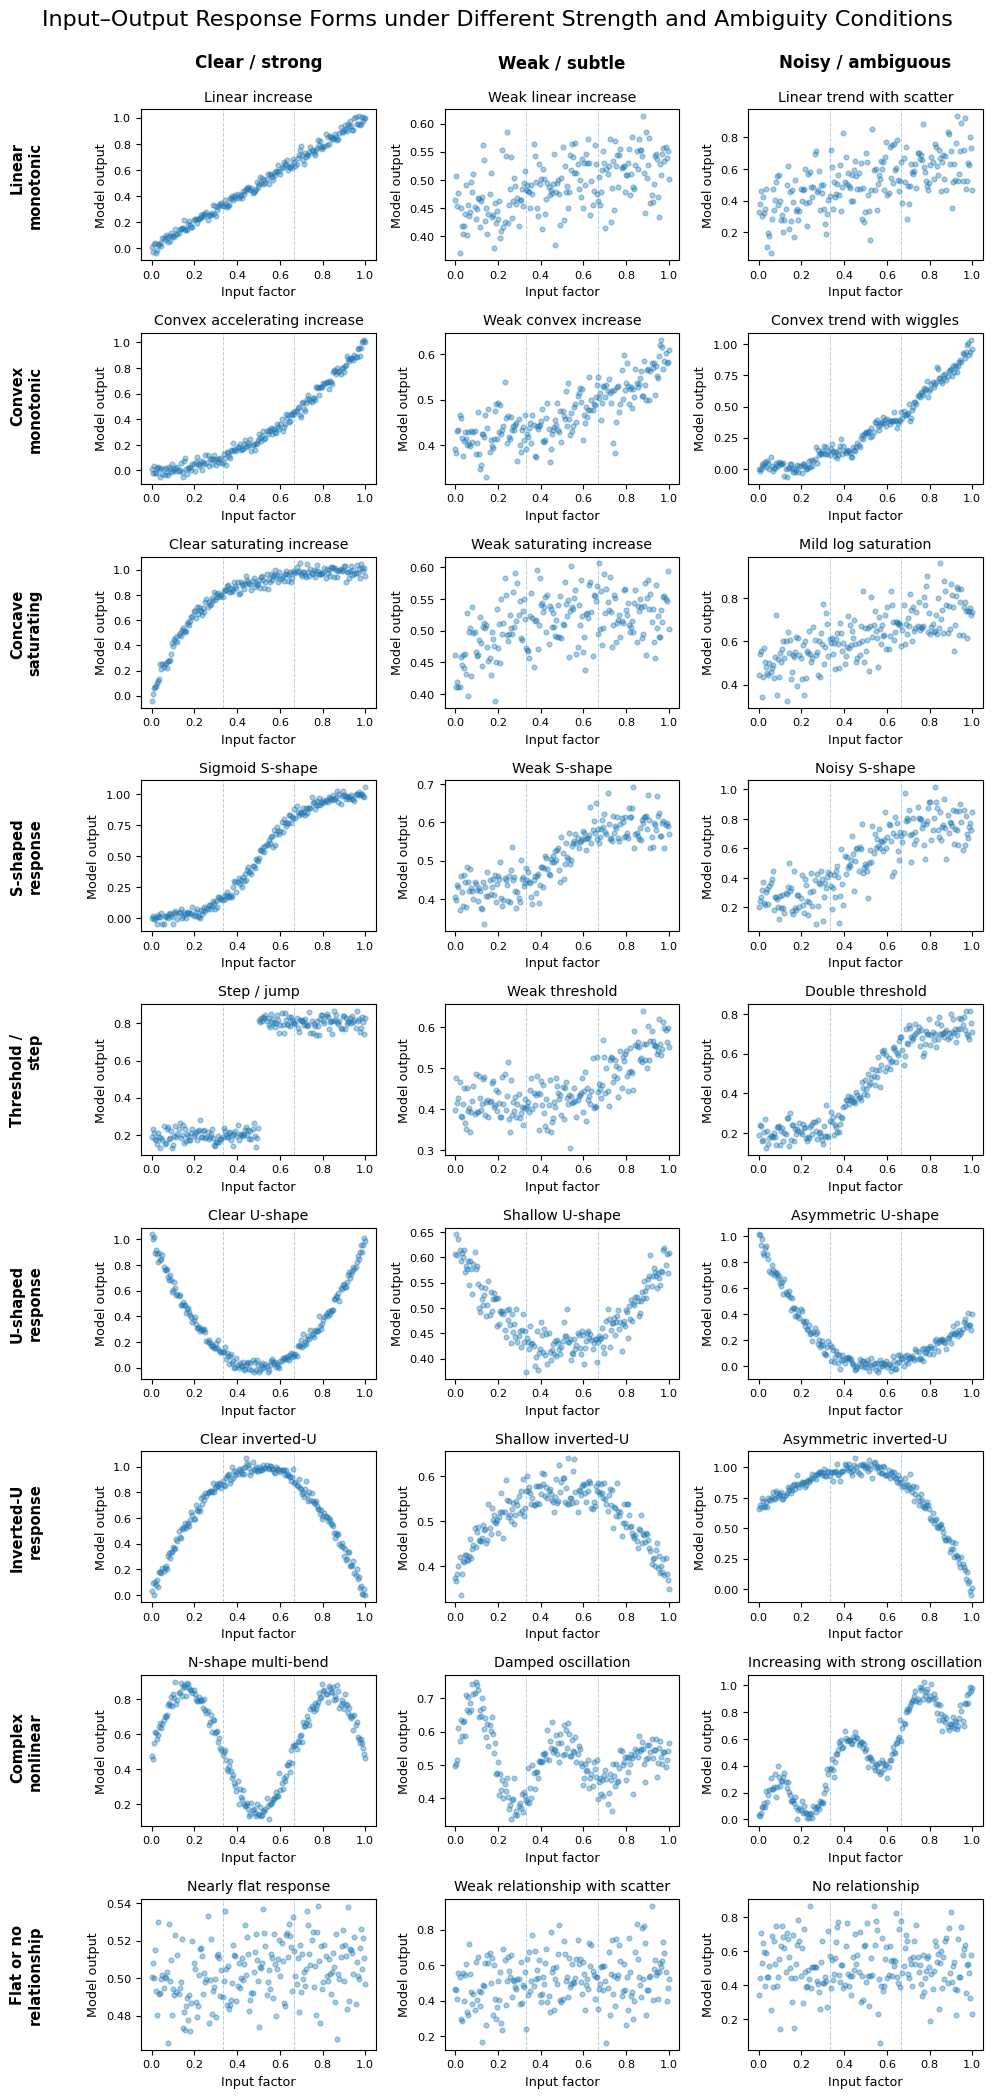

In [11]:
import numpy as np
import matplotlib.pyplot as plt


def plot_response_form_matrix_scatter_only(
    form_matrix,
    n=200,
    noise_default=0.035,
    seed=42,
    figsize=(13, 21),
    show_stage_dividers=True,
):
    rng = np.random.default_rng(seed)

    row_names = list(form_matrix.keys())
    col_names = list(next(iter(form_matrix.values())).keys())

    n_rows = len(row_names)
    n_cols = len(col_names)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=figsize,
        sharex=False,
        sharey=False
    )

    for i, row_name in enumerate(row_names):
        for j, col_name in enumerate(col_names):

            ax = axes[i, j]

            case = form_matrix[row_name][col_name]
            title = case["title"]
            func = case["func"]
            noise = case.get("noise", noise_default)
            x_range = case.get("x_range", (0, 1))

            xmin, xmax = x_range
            x = np.linspace(xmin, xmax, n)
            y_true = func(x)

            if case.get("fit_type", "curve") == "flat":
                y_scatter = y_true
            else:
                y_scatter = y_true + noise * rng.standard_normal(n)

            # scatter only, no fitted line
            ax.scatter(
                x,
                y_scatter,
                s=12,
                alpha=0.38
            )

            # optional early / middle / late dividers
            if show_stage_dividers:
                x1 = xmin + (xmax - xmin) / 3
                x2 = xmin + 2 * (xmax - xmin) / 3
                ax.axvline(x1, linestyle="--", linewidth=0.7, alpha=0.35)
                ax.axvline(x2, linestyle="--", linewidth=0.7, alpha=0.35)

            # use subtitle
            ax.set_title(title, fontsize=10.2, pad=6)

            ax.set_xlabel("Input factor", fontsize=9.2)
            ax.set_ylabel("Model output", fontsize=9.2)
            ax.tick_params(axis="both", labelsize=8.2)

            # row label on the left
            if j == 0:
                ax.annotate(
                    row_name,
                    xy=(-0.42, 0.5),
                    xycoords="axes fraction",
                    ha="right",
                    va="center",
                    fontsize=10.5,
                    fontweight="bold",
                    rotation=90
                )

            # column label on the top
            if i == 0:
                ax.annotate(
                    col_name,
                    xy=(0.5, 1.25),
                    xycoords="axes fraction",
                    ha="center",
                    va="bottom",
                    fontsize=12,
                    fontweight="bold"
                )

    plt.suptitle(
        "Input–Output Response Forms under Different Strength and Ambiguity Conditions",
        fontsize=16,
        y=0.997
    )

    plt.tight_layout()
    plt.show()


plot_response_form_matrix_scatter_only(
    form_matrix=form_matrix,
    n=200,
    noise_default=0.035,
    seed=42,
    figsize=(10, 21),
    show_stage_dividers=True
)

In [17]:
import numpy as np
import pandas as pd
from scipy.stats import pearsonr, spearmanr, theilslopes


def compute_secant_slopes_from_scatter(
    x,
    y,
    trim_quantiles=(0.05, 0.95),
    min_n=10
):
    """
    Compute direction-related metrics from scatter points.

    Metrics:
    - Pearson r
    - Spearman rho
    - Overall secant slope
    - Theil-Sen slope
    - Early / middle / late secant slopes

    Slopes are computed after trimming x to the 5%-95% range.
    """

    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    valid = np.isfinite(x) & np.isfinite(y)
    x = x[valid]
    y = y[valid]

    n_original = len(x)

    if len(x) < min_n or np.nanstd(x) == 0 or np.nanstd(y) == 0:
        return {
            "n_original": n_original,
            "n_used": len(x),
            "pearson_r": np.nan,
            "spearman_rho": np.nan,
            "overall_slope": np.nan,
            "theil_sen_slope": np.nan,
            "early_slope": np.nan,
            "middle_slope": np.nan,
            "late_slope": np.nan,
        }

    # --------------------------------------------------------
    # 1. Keep only 5%-95% x range
    # --------------------------------------------------------
    q_low, q_high = np.nanquantile(x, trim_quantiles)
    keep = (x >= q_low) & (x <= q_high)

    x = x[keep]
    y = y[keep]

    if len(x) < min_n or np.nanstd(x) == 0 or np.nanstd(y) == 0:
        return {
            "n_original": n_original,
            "n_used": len(x),
            "x_q_low": q_low,
            "x_q_high": q_high,
            "pearson_r": np.nan,
            "spearman_rho": np.nan,
            "overall_slope": np.nan,
            "theil_sen_slope": np.nan,
            "early_slope": np.nan,
            "middle_slope": np.nan,
            "late_slope": np.nan,
        }

    # --------------------------------------------------------
    # 2. Pearson and Spearman
    # --------------------------------------------------------
    pearson_r, pearson_p = pearsonr(x, y)
    spearman_rho, spearman_p = spearmanr(x, y)

    # --------------------------------------------------------
    # 3. Theil-Sen robust slope
    # --------------------------------------------------------
    try:
        ts_result = theilslopes(y, x)
        theil_sen_slope = ts_result.slope
        theil_sen_intercept = ts_result.intercept
        theil_sen_low_slope = ts_result.low_slope
        theil_sen_high_slope = ts_result.high_slope
    except Exception:
        theil_sen_slope = np.nan
        theil_sen_intercept = np.nan
        theil_sen_low_slope = np.nan
        theil_sen_high_slope = np.nan

    # --------------------------------------------------------
    # 4. Sort by x for secant slopes
    # --------------------------------------------------------
    order = np.argsort(x)
    x_sorted = x[order]
    y_sorted = y[order]

    n = len(x_sorted)

    i0 = 0
    i1 = n // 3
    i2 = 2 * n // 3
    i3 = n - 1

    x0, y0 = x_sorted[i0], y_sorted[i0]
    x13, y13 = x_sorted[i1], y_sorted[i1]
    x23, y23 = x_sorted[i2], y_sorted[i2]
    x1, y1 = x_sorted[i3], y_sorted[i3]

    def safe_secant_slope(yb, ya, xb, xa):
        dx = xb - xa
        if dx == 0 or not np.isfinite(dx):
            return np.nan
        return (yb - ya) / dx

    overall_slope = safe_secant_slope(y1, y0, x1, x0)
    early_slope = safe_secant_slope(y13, y0, x13, x0)
    middle_slope = safe_secant_slope(y23, y13, x23, x13)
    late_slope = safe_secant_slope(y1, y23, x1, x23)

    return {
        "n_original": n_original,
        "n_used": len(x_sorted),
        "x_q_low": q_low,
        "x_q_high": q_high,

        "pearson_r": pearson_r,
        "spearman_rho": spearman_rho,

        "overall_slope": overall_slope,
        "theil_sen_slope": theil_sen_slope,
        "theil_sen_intercept": theil_sen_intercept,
        "theil_sen_low_slope": theil_sen_low_slope,
        "theil_sen_high_slope": theil_sen_high_slope,

        "early_slope": early_slope,
        "middle_slope": middle_slope,
        "late_slope": late_slope,

        "pearson_p": pearson_p,
        "spearman_p": spearman_p,
    }


def compute_metrics_for_simulated_form_matrix(
    form_matrix,
    n=200,
    noise_default=0.035,
    seed=42,
    trim_quantiles=(0.05, 0.95)
):
    """
    Generate simulated scatter points from form_matrix and compute metrics
    for each response form.
    """

    rng = np.random.default_rng(seed)
    records = []

    for response_family, cases in form_matrix.items():
        for clarity_level, case in cases.items():

            title = case["title"]
            func = case["func"]
            noise = case.get("noise", noise_default)
            x_range = case.get("x_range", (0, 1))

            xmin, xmax = x_range
            x = np.linspace(xmin, xmax, n)

            y_base = func(x)

            if case.get("fit_type", "curve") == "flat":
                y_scatter = y_base
            else:
                y_scatter = y_base + noise * rng.standard_normal(n)

            metrics = compute_secant_slopes_from_scatter(
                x=x,
                y=y_scatter,
                trim_quantiles=trim_quantiles
            )

            records.append({
                "response_family": response_family.replace("\n", " "),
                "clarity_level": clarity_level,
                "case": title.replace("\n", " "),
                **metrics
            })

    return pd.DataFrame(records)


metrics_df = compute_metrics_for_simulated_form_matrix(
    form_matrix=form_matrix,
    n=200,
    noise_default=0.035,
    seed=42,
    trim_quantiles=(0.05, 0.95)
)

metrics_df[
    [
        "response_family",
        "clarity_level",
        "case",
        "pearson_r",
        "spearman_rho",
        "overall_slope",
        "theil_sen_slope",
        "early_slope",
        "middle_slope",
        "late_slope",
    ]
].round(3)

,response_family,clarity_level,case,pearson_r,spearman_rho,overall_slope,theil_sen_slope,early_slope,middle_slope,late_slope
0,Linear monotonic,Clear / strong,Linear increase,0.995,0.995,1.026,0.992,0.786,1.088,1.206
1,Linear monotonic,Weak / subtle,Weak linear increase,0.477,0.478,-0.024,0.092,-0.137,0.376,-0.314
2,Linear monotonic,Noisy / ambiguous,Linear trend with scatter,0.562,0.562,0.797,0.344,1.139,0.044,1.215
3,Convex monotonic,Clear / strong,Convex accelerating increase,0.966,0.986,1.029,1.010,0.583,0.971,1.542
4,Convex monotonic,Weak / subtle,Weak convex increase,0.759,0.762,0.149,0.168,0.120,0.129,0.199
5,Convex monotonic,Noisy / ambiguous,Convex trend with wiggles,0.964,0.974,0.958,0.993,0.469,0.764,1.651
6,Concave saturating,Clear / strong,Clear saturating increase,0.862,0.931,0.795,0.556,2.073,0.105,0.197
7,Concave saturating,Weak / subtle,Weak saturating increase,0.343,0.333,0.101,0.052,0.302,0.105,-0.107
8,Concave saturating,Noisy / ambiguous,Mild log saturation,0.694,0.707,0.381,0.296,0.307,0.301,0.538
9,S-shaped response,Clear / strong,Sigmoid S-shape,0.977,0.986,1.107,1.390,0.858,1.856,0.598


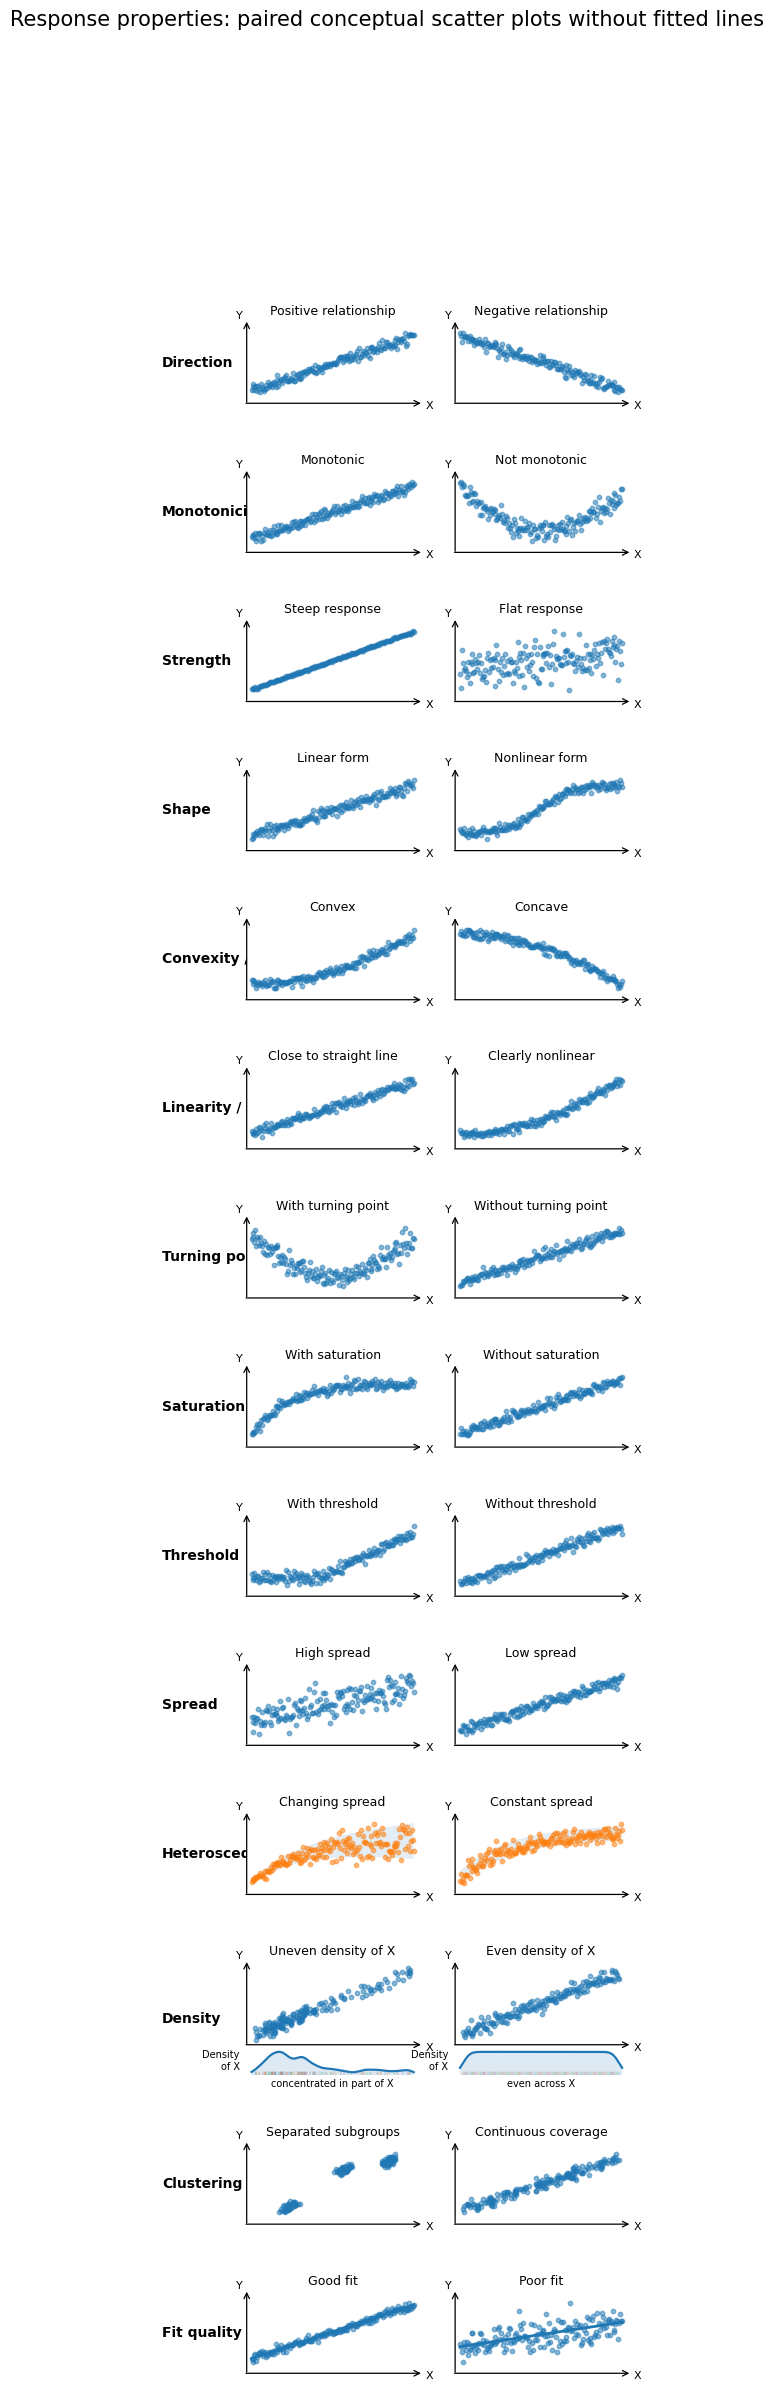

In [63]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

np.random.seed(88)
rng = np.random.default_rng(88)

x = np.linspace(0, 1, 170)

properties = [
    ("Direction", "Positive relationship", "Negative relationship"),
    ("Monotonicity", "Monotonic", "Not monotonic"),
    ("Strength", "Steep response", "Flat response"),
    ("Shape", "Linear form", "Nonlinear form"),
    ("Convexity / Concavity", "Convex", "Concave"),
    ("Linearity / Non-linearity", "Close to straight line", "Clearly nonlinear"),
    ("Turning point", "With turning point", "Without turning point"),
    ("Saturation", "With saturation", "Without saturation"),
    ("Threshold", "With threshold", "Without threshold"),
    ("Spread", "High spread", "Low spread"),
    ("Heteroscedasticity", "Changing spread", "Constant spread"),
    ("Density", "Uneven density of X", "Even density of X"),
    ("Clustering", "Separated subgroups", "Continuous coverage"),
    ("Fit quality", "Good fit", "Poor fit"),
]


def kde_manual(values, grid, bandwidth=0.035):
    values = np.asarray(values)
    grid = np.asarray(grid)
    dens = np.zeros_like(grid, dtype=float)

    for v in values:
        dens += np.exp(-0.5 * ((grid - v) / bandwidth) ** 2)

    dens /= max(len(values), 1)
    dens = dens / dens.max() if dens.max() > 0 else dens
    return dens


def curve_data(prop):
    xx = x.copy()

    if prop == "Direction":
        return (xx, 0.15 + 0.75 * xx), (xx, 0.90 - 0.70 * xx)

    if prop == "Monotonicity":
        return (xx, 0.15 + 0.75 * xx), (xx, 0.18 + 1.20 * (xx - 0.52) ** 2)

    if prop == "Strength":
        # Clear steep vs flat, without representing spread
        return (xx, 0.08 + 0.90 * xx), (xx, 0.50 + 0.015 * xx)

    if prop == "Shape":
        return (
            (xx, 0.15 + 0.75 * xx),
            (xx, 0.15 + 0.75 / (1 + np.exp(-10 * (xx - 0.5)))),
        )

    if prop == "Convexity / Concavity":
        return (xx, 0.15 + 0.80 * xx**2), (xx, 0.95 - 0.80 * xx**2)

    if prop == "Linearity / Non-linearity":
        return (xx, 0.15 + 0.75 * xx), (xx, 0.15 + 0.82 * xx**2)

    if prop == "Turning point":
        return (xx, 0.20 + 1.05 * (xx - 0.50) ** 2), (xx, 0.18 + 0.70 * xx)

    if prop == "Saturation":
        return (
            (xx, 0.12 + 0.78 * (1 - np.exp(-4.5 * xx))),
            (xx, 0.12 + 0.78 * xx),
        )

    if prop == "Threshold":
        y_thr = np.where(
            xx < 0.45,
            0.28 + 0.02 * xx,
            0.30 + 1.05 * (xx - 0.45),
        )
        return (xx, y_thr), (xx, 0.16 + 0.74 * xx)

    if prop == "Spread":
        return (xx, 0.18 + 0.68 * xx), (xx, 0.18 + 0.68 * xx)

    if prop == "Heteroscedasticity":
        y = 0.16 + 0.72 * (1 - np.exp(-3.2 * xx))
        return (xx, y), (xx, y)

    if prop == "Density":
        x_uneven = np.concatenate([
            rng.beta(2.2, 7.5, 125),
            rng.uniform(0.38, 1.00, 45),
        ])
        x_uneven = np.clip(x_uneven, 0.02, 0.98)

        x_even = np.linspace(0.02, 0.98, 170)

        return (
            (x_uneven, 0.20 + 0.70 * x_uneven),
            (x_even, 0.20 + 0.70 * x_even),
        )

    if prop == "Clustering":
        x_cl = np.concatenate([
            rng.normal(0.23, 0.025, 55),
            rng.normal(0.57, 0.025, 60),
            rng.normal(0.84, 0.024, 55),
        ])
        x_cl = np.clip(x_cl, 0, 1)

        y_cl = np.concatenate([
            0.16 + 0.80 * x_cl[:55] + rng.normal(-0.10, 0.025, 55),
            0.16 + 0.80 * x_cl[55:115] + rng.normal(0.10, 0.025, 60),
            0.16 + 0.80 * x_cl[115:] + rng.normal(-0.02, 0.025, 55),
        ])

        x_cont = rng.uniform(0.02, 0.98, 170)

        return (
            (x_cl, y_cl),
            (x_cont, 0.16 + 0.76 * x_cont),
        )

    if prop == "Fit quality":
        return (
            (xx, 0.18 + 0.68 * xx),
            (xx, 0.18 + 0.68 * xx),
        )


def draw_axes_arrows(ax):
    for spine in ["top", "right", "bottom", "left"]:
        ax.spines[spine].set_visible(False)

    ax.set_xticks([])
    ax.set_yticks([])

    ax.annotate(
        "",
        xy=(1.03, 0),
        xytext=(-0.02, 0),
        xycoords=("axes fraction", "axes fraction"),
        arrowprops=dict(arrowstyle="->", linewidth=0.9),
    )

    ax.annotate(
        "",
        xy=(0, 1.03),
        xytext=(0, -0.02),
        xycoords=("axes fraction", "axes fraction"),
        arrowprops=dict(arrowstyle="->", linewidth=0.9),
    )

    ax.text(1.04, -0.07, "X", transform=ax.transAxes, fontsize=8)
    ax.text(-0.06, 1.04, "Y", transform=ax.transAxes, fontsize=8)


def add_band(ax, xx, yy, width):
    order = np.argsort(xx)
    xx_o = np.asarray(xx)[order]
    yy_o = np.asarray(yy)[order]

    if np.isscalar(width):
        w_o = np.full_like(xx_o, width, dtype=float)
    else:
        w_o = np.asarray(width)[order]

    ax.fill_between(xx_o, yy_o - w_o, yy_o + w_o, alpha=0.13, linewidth=0)


def draw_normal_panel_no_fit(ax, xx, yy, title, prop, side):
    xx = np.asarray(xx)
    yy = np.asarray(yy)

    if prop == "Strength":
        # Minimal noise only, so the property is slope steepness, not spread
        y_points = yy + np.random.normal(0, 0.008, len(yy))

    elif prop == "Spread":
        noise_sd = 0.17 if side == 0 else 0.035
        y_points = yy + np.random.normal(0, noise_sd, len(yy))

    elif prop == "Heteroscedasticity":
        if side == 0:
            noise_sd = 0.025 + 0.18 * xx
            y_points = yy + np.random.normal(0, noise_sd, len(yy))
            add_band(ax, xx, yy, noise_sd * 1.45)
        else:
            noise_sd = 0.075
            y_points = yy + np.random.normal(0, noise_sd, len(yy))
            add_band(ax, xx, yy, noise_sd * 1.45)

    elif prop == "Fit quality":
        noise_sd = 0.025 if side == 0 else 0.22
        y_points = yy + np.random.normal(0, noise_sd, len(yy))

    elif prop == "Clustering" and side == 0:
        y_points = yy

    else:
        y_points = yy + np.random.normal(0, 0.040, len(yy))

    ax.scatter(xx, y_points, s=10, alpha=0.52)

    # Only Fit quality keeps fitted line
    if prop == "Fit quality":
        order = np.argsort(xx)
        ax.plot(xx[order], yy[order], linewidth=2.0)

    ax.set_title(title, fontsize=9, pad=5)
    ax.set_xlim(-0.03, 1.03)

    y_min = min(np.nanmin(y_points), np.nanmin(yy))
    y_max = max(np.nanmax(y_points), np.nanmax(yy))
    pad = (y_max - y_min) * 0.20 if y_max > y_min else 0.15
    ax.set_ylim(y_min - pad, y_max + pad)

    draw_axes_arrows(ax)


def draw_density_panel_no_fit(ax_main, ax_den, xx, yy, title, subtitle):
    xx = np.asarray(xx)
    yy = np.asarray(yy)

    y_points = yy + np.random.normal(0, 0.045, len(yy))
    ax_main.scatter(xx, y_points, s=10, alpha=0.52)

    ax_main.set_xlim(-0.03, 1.03)
    ax_main.set_ylim(0.10, 1.00)
    ax_main.set_title(title, fontsize=9, pad=5)

    draw_axes_arrows(ax_main)

    grid = np.linspace(0, 1, 300)
    dens = kde_manual(xx, grid, bandwidth=0.035)

    ax_den.plot(grid, dens, linewidth=1.6)
    ax_den.fill_between(grid, 0, dens, alpha=0.15)

    for xi in xx:
        ax_den.plot([xi, xi], [0, 0.12], linewidth=0.35, alpha=0.50)

    ax_den.set_xlim(-0.03, 1.03)
    ax_den.set_ylim(0, 1.12)
    ax_den.set_xticks([])
    ax_den.set_yticks([])

    for spine in ["top", "right", "bottom", "left"]:
        ax_den.spines[spine].set_visible(False)

    ax_den.text(
        -0.04,
        0.55,
        "Density\nof X",
        transform=ax_den.transAxes,
        ha="right",
        va="center",
        fontsize=7,
    )

    ax_den.text(
        0.5,
        -0.33,
        subtitle,
        transform=ax_den.transAxes,
        ha="center",
        va="center",
        fontsize=7,
    )


height_ratios = []
for prop, _, _ in properties:
    height_ratios.append(2.7 if prop == "Density" else 1.95)

fig = plt.figure(figsize=(6, sum(height_ratios) * 0.95))

outer = GridSpec(
    len(properties),
    3,
    figure=fig,
    width_ratios=[0.28, 1, 1],
    height_ratios=height_ratios,
    hspace=0.80,
    wspace=0.28,
)

for i, (prop, left_title, right_title) in enumerate(properties):
    label_ax = fig.add_subplot(outer[i, 0])
    label_ax.axis("off")
    label_ax.text(
        0.0,
        0.5,
        prop,
        ha="left",
        va="center",
        fontsize=10,
        fontweight="bold",
    )

    (xl, yl), (xr, yr) = curve_data(prop)

    if prop == "Density":
        sub_left = outer[i, 1].subgridspec(
            2, 1, height_ratios=[4.0, 1.25], hspace=0.08
        )
        sub_right = outer[i, 2].subgridspec(
            2, 1, height_ratios=[4.0, 1.25], hspace=0.08
        )

        ax_l = fig.add_subplot(sub_left[0])
        den_l = fig.add_subplot(sub_left[1])
        ax_r = fig.add_subplot(sub_right[0])
        den_r = fig.add_subplot(sub_right[1])

        draw_density_panel_no_fit(
            ax_l,
            den_l,
            xl,
            yl,
            left_title,
            "concentrated in part of X",
        )

        draw_density_panel_no_fit(
            ax_r,
            den_r,
            xr,
            yr,
            right_title,
            "even across X",
        )

    else:
        ax_l = fig.add_subplot(outer[i, 1])
        ax_r = fig.add_subplot(outer[i, 2])

        draw_normal_panel_no_fit(ax_l, xl, yl, left_title, prop, 0)
        draw_normal_panel_no_fit(ax_r, xr, yr, right_title, prop, 1)

fig.suptitle(
    "Response properties: paired conceptual scatter plots without fitted lines",
    fontsize=15,
    y=0.997,
)

plt.show()

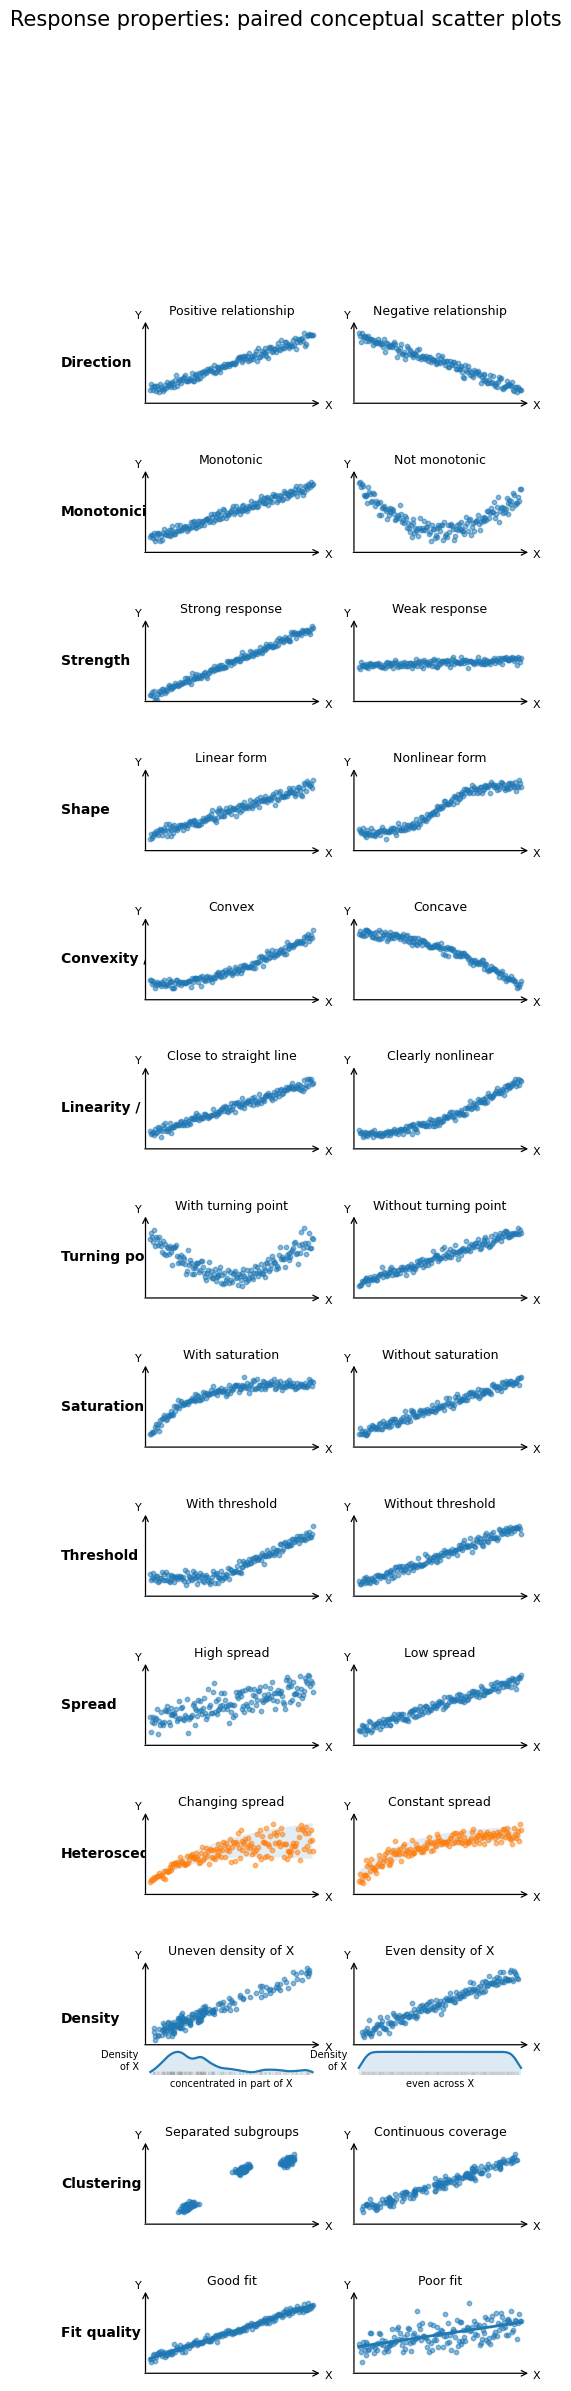

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# ==========================================================
# 0. Basic settings
# ==========================================================

np.random.seed(88)
rng = np.random.default_rng(88)

x = np.linspace(0, 1, 170)

properties = [
    ("Direction", "Positive relationship", "Negative relationship"),
    ("Monotonicity", "Monotonic", "Not monotonic"),
    ("Strength", "Strong response", "Weak response"),
    ("Shape", "Linear form", "Nonlinear form"),
    ("Convexity / Concavity", "Convex", "Concave"),
    ("Linearity / Non-linearity", "Close to straight line", "Clearly nonlinear"),
    ("Turning point", "With turning point", "Without turning point"),
    ("Saturation", "With saturation", "Without saturation"),
    ("Threshold", "With threshold", "Without threshold"),
    ("Spread", "High spread", "Low spread"),
    ("Heteroscedasticity", "Changing spread", "Constant spread"),
    ("Density", "Uneven density of X", "Even density of X"),
    ("Clustering", "Separated subgroups", "Continuous coverage"),
    ("Fit quality", "Good fit", "Poor fit"),
]


# ==========================================================
# 1. Data generation
# ==========================================================

def kde_manual(values, grid, bandwidth=0.035):
    values = np.asarray(values)
    grid = np.asarray(grid)
    dens = np.zeros_like(grid, dtype=float)

    for v in values:
        dens += np.exp(-0.5 * ((grid - v) / bandwidth) ** 2)

    dens /= max(len(values), 1)
    dens = dens / dens.max() if dens.max() > 0 else dens
    return dens


def curve_data(prop):
    xx = x.copy()

    if prop == "Direction":
        return (
            (xx, 0.15 + 0.75 * xx),
            (xx, 0.90 - 0.70 * xx),
        )

    if prop == "Monotonicity":
        return (
            (xx, 0.15 + 0.75 * xx),
            (xx, 0.18 + 1.20 * (xx - 0.52) ** 2),
        )

    if prop == "Strength":
        # Same X range and same y-axis range.
        # Difference is only the overall slope / response magnitude.
        return (
            (xx, 0.10 + 0.78 * xx),   # strong response: high overall slope
            (xx, 0.45 + 0.08 * xx),   # weak response: low overall slope
        )

    if prop == "Shape":
        return (
            (xx, 0.15 + 0.75 * xx),
            (xx, 0.15 + 0.75 / (1 + np.exp(-10 * (xx - 0.5)))),
        )

    if prop == "Convexity / Concavity":
        return (
            (xx, 0.15 + 0.80 * xx**2),
            (xx, 0.95 - 0.80 * xx**2),
        )

    if prop == "Linearity / Non-linearity":
        return (
            (xx, 0.15 + 0.75 * xx),
            (xx, 0.15 + 0.82 * xx**2),
        )

    if prop == "Turning point":
        return (
            (xx, 0.20 + 1.05 * (xx - 0.50) ** 2),
            (xx, 0.18 + 0.70 * xx),
        )

    if prop == "Saturation":
        return (
            (xx, 0.12 + 0.78 * (1 - np.exp(-4.5 * xx))),
            (xx, 0.12 + 0.78 * xx),
        )

    if prop == "Threshold":
        y_thr = np.where(
            xx < 0.45,
            0.28 + 0.02 * xx,
            0.30 + 1.05 * (xx - 0.45),
        )
        return (
            (xx, y_thr),
            (xx, 0.16 + 0.74 * xx),
        )

    if prop == "Spread":
        return (
            (xx, 0.18 + 0.68 * xx),
            (xx, 0.18 + 0.68 * xx),
        )

    if prop == "Heteroscedasticity":
        y = 0.16 + 0.72 * (1 - np.exp(-3.2 * xx))
        return (
            (xx, y),
            (xx, y),
        )

    if prop == "Density":
        # Uneven but continuous X coverage
        x_uneven = np.concatenate([
            rng.beta(2.2, 7.5, 125),
            rng.uniform(0.38, 1.00, 45),
        ])
        x_uneven = np.clip(x_uneven, 0.02, 0.98)

        # Even X coverage
        x_even = np.linspace(0.02, 0.98, 170)

        return (
            (x_uneven, 0.20 + 0.70 * x_uneven),
            (x_even, 0.20 + 0.70 * x_even),
        )

    if prop == "Clustering":
        x_cl = np.concatenate([
            rng.normal(0.23, 0.025, 55),
            rng.normal(0.57, 0.025, 60),
            rng.normal(0.84, 0.024, 55),
        ])
        x_cl = np.clip(x_cl, 0, 1)

        y_cl = np.concatenate([
            0.16 + 0.80 * x_cl[:55] + rng.normal(-0.10, 0.025, 55),
            0.16 + 0.80 * x_cl[55:115] + rng.normal(0.10, 0.025, 60),
            0.16 + 0.80 * x_cl[115:] + rng.normal(-0.02, 0.025, 55),
        ])

        x_cont = rng.uniform(0.02, 0.98, 170)

        return (
            (x_cl, y_cl),
            (x_cont, 0.16 + 0.76 * x_cont),
        )

    if prop == "Fit quality":
        return (
            (xx, 0.18 + 0.68 * xx),
            (xx, 0.18 + 0.68 * xx),
        )

    raise ValueError(f"Unknown property: {prop}")


# ==========================================================
# 2. Plotting helper functions
# ==========================================================

def draw_axes_arrows(ax):
    for spine in ["top", "right", "bottom", "left"]:
        ax.spines[spine].set_visible(False)

    ax.set_xticks([])
    ax.set_yticks([])

    ax.annotate(
        "",
        xy=(1.03, 0),
        xytext=(-0.02, 0),
        xycoords=("axes fraction", "axes fraction"),
        arrowprops=dict(arrowstyle="->", linewidth=0.9),
    )

    ax.annotate(
        "",
        xy=(0, 1.03),
        xytext=(0, -0.02),
        xycoords=("axes fraction", "axes fraction"),
        arrowprops=dict(arrowstyle="->", linewidth=0.9),
    )

    ax.text(1.04, -0.07, "X", transform=ax.transAxes, fontsize=8)
    ax.text(-0.06, 1.04, "Y", transform=ax.transAxes, fontsize=8)


def add_band(ax, xx, yy, width):
    order = np.argsort(xx)
    xx_o = np.asarray(xx)[order]
    yy_o = np.asarray(yy)[order]

    if np.isscalar(width):
        w_o = np.full_like(xx_o, width, dtype=float)
    else:
        w_o = np.asarray(width)[order]

    ax.fill_between(xx_o, yy_o - w_o, yy_o + w_o, alpha=0.13, linewidth=0)


def draw_normal_panel_no_fit(ax, xx, yy, title, prop, side):
    xx = np.asarray(xx)
    yy = np.asarray(yy)

    if prop == "Strength":
        # Critical point:
        # Strength uses the same y-axis range for both panels.
        # Therefore, the slope difference is visually preserved.
        noise_sd = 0.025
        y_points = yy + np.random.normal(0, noise_sd, len(yy))

        ax.scatter(xx, y_points, s=10, alpha=0.52)

        ax.set_title(title, fontsize=9, pad=5)
        ax.set_xlim(-0.03, 1.03)

        # Same y-axis range for strong and weak response
        ax.set_ylim(0.05, 0.98)

        draw_axes_arrows(ax)
        return

    elif prop == "Spread":
        noise_sd = 0.17 if side == 0 else 0.035
        y_points = yy + np.random.normal(0, noise_sd, len(yy))

    elif prop == "Heteroscedasticity":
        if side == 0:
            noise_sd = 0.025 + 0.18 * xx
            y_points = yy + np.random.normal(0, noise_sd, len(yy))
            add_band(ax, xx, yy, noise_sd * 1.45)
        else:
            noise_sd = 0.075
            y_points = yy + np.random.normal(0, noise_sd, len(yy))
            add_band(ax, xx, yy, noise_sd * 1.45)

    elif prop == "Fit quality":
        noise_sd = 0.025 if side == 0 else 0.22
        y_points = yy + np.random.normal(0, noise_sd, len(yy))

    elif prop == "Clustering" and side == 0:
        y_points = yy

    else:
        y_points = yy + np.random.normal(0, 0.040, len(yy))

    ax.scatter(xx, y_points, s=10, alpha=0.52)

    # No fitted lines except for Fit quality
    if prop == "Fit quality":
        order = np.argsort(xx)
        ax.plot(xx[order], yy[order], linewidth=2.0)

    ax.set_title(title, fontsize=9, pad=5)
    ax.set_xlim(-0.03, 1.03)

    y_min = min(np.nanmin(y_points), np.nanmin(yy))
    y_max = max(np.nanmax(y_points), np.nanmax(yy))
    pad = (y_max - y_min) * 0.20 if y_max > y_min else 0.15
    ax.set_ylim(y_min - pad, y_max + pad)

    draw_axes_arrows(ax)


def draw_density_panel_no_fit(ax_main, ax_den, xx, yy, title, subtitle):
    xx = np.asarray(xx)
    yy = np.asarray(yy)

    y_points = yy + np.random.normal(0, 0.045, len(yy))
    ax_main.scatter(xx, y_points, s=10, alpha=0.52)

    ax_main.set_xlim(-0.03, 1.03)
    ax_main.set_ylim(0.10, 1.00)
    ax_main.set_title(title, fontsize=9, pad=5)

    draw_axes_arrows(ax_main)

    grid = np.linspace(0, 1, 300)
    dens = kde_manual(xx, grid, bandwidth=0.035)

    ax_den.plot(grid, dens, linewidth=1.6)
    ax_den.fill_between(grid, 0, dens, alpha=0.15)

    for xi in xx:
        ax_den.plot([xi, xi], [0, 0.12], linewidth=0.35, alpha=0.50)

    ax_den.set_xlim(-0.03, 1.03)
    ax_den.set_ylim(0, 1.12)
    ax_den.set_xticks([])
    ax_den.set_yticks([])

    for spine in ["top", "right", "bottom", "left"]:
        ax_den.spines[spine].set_visible(False)

    ax_den.text(
        -0.04,
        0.55,
        "Density\nof X",
        transform=ax_den.transAxes,
        ha="right",
        va="center",
        fontsize=7,
    )

    ax_den.text(
        0.5,
        -0.33,
        subtitle,
        transform=ax_den.transAxes,
        ha="center",
        va="center",
        fontsize=7,
    )


# ==========================================================
# 3. Draw figure
# ==========================================================

height_ratios = []
for prop, _, _ in properties:
    height_ratios.append(2.7 if prop == "Density" else 1.95)

fig = plt.figure(figsize=(6, sum(height_ratios) * 0.95))

outer = GridSpec(
    len(properties),
    3,
    figure=fig,
    width_ratios=[0.28, 1, 1],
    height_ratios=height_ratios,
    hspace=0.80,
    wspace=0.28,
)

for i, (prop, left_title, right_title) in enumerate(properties):
    label_ax = fig.add_subplot(outer[i, 0])
    label_ax.axis("off")
    label_ax.text(
        0.0,
        0.5,
        prop,
        ha="left",
        va="center",
        fontsize=10,
        fontweight="bold",
    )

    (xl, yl), (xr, yr) = curve_data(prop)

    if prop == "Density":
        sub_left = outer[i, 1].subgridspec(
            2, 1,
            height_ratios=[4.0, 1.25],
            hspace=0.08,
        )
        sub_right = outer[i, 2].subgridspec(
            2, 1,
            height_ratios=[4.0, 1.25],
            hspace=0.08,
        )

        ax_l = fig.add_subplot(sub_left[0])
        den_l = fig.add_subplot(sub_left[1])
        ax_r = fig.add_subplot(sub_right[0])
        den_r = fig.add_subplot(sub_right[1])

        draw_density_panel_no_fit(
            ax_l,
            den_l,
            xl,
            yl,
            left_title,
            "concentrated in part of X",
        )

        draw_density_panel_no_fit(
            ax_r,
            den_r,
            xr,
            yr,
            right_title,
            "even across X",
        )

    else:
        ax_l = fig.add_subplot(outer[i, 1])
        ax_r = fig.add_subplot(outer[i, 2])

        draw_normal_panel_no_fit(ax_l, xl, yl, left_title, prop, 0)
        draw_normal_panel_no_fit(ax_r, xr, yr, right_title, prop, 1)

fig.suptitle(
    "Response properties: paired conceptual scatter plots",
    fontsize=15,
    y=0.997,
)

plt.show()

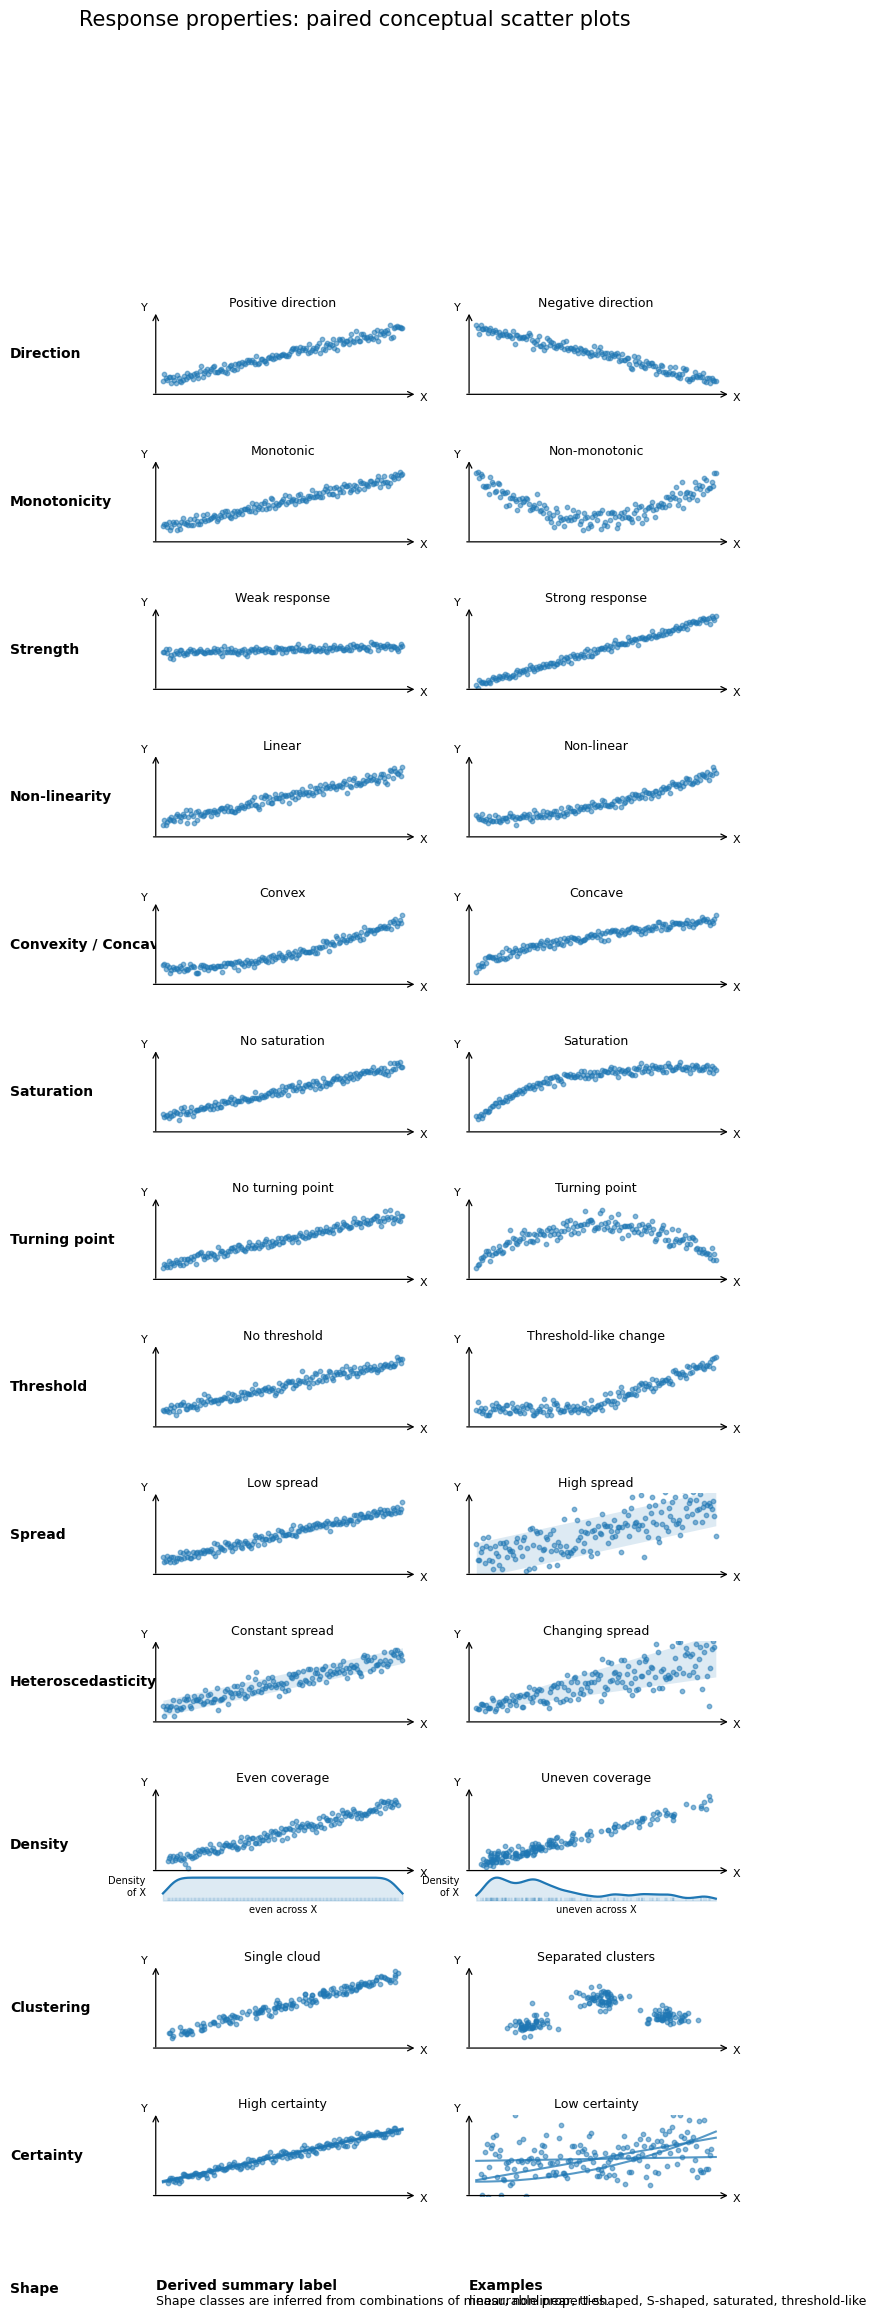

In [51]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# ==========================================================
# 0. Basic settings
# ==========================================================

np.random.seed(88)
rng = np.random.default_rng(88)

x = np.linspace(0, 1, 170)

POINT_COLOR = "C0"      # all scatter points use the same color
BUFFER_COLOR = "C0"     # buffer uses same color with low alpha

properties = [
    ("Direction", "Positive direction", "Negative direction"),
    ("Monotonicity", "Monotonic", "Non-monotonic"),
    ("Strength", "Weak response", "Strong response"),
    ("Non-linearity", "Linear", "Non-linear"),
    ("Convexity / Concavity", "Convex", "Concave"),
    ("Saturation", "No saturation", "Saturation"),
    ("Turning point", "No turning point", "Turning point"),
    ("Threshold", "No threshold", "Threshold-like change"),
    ("Spread", "Low spread", "High spread"),
    ("Heteroscedasticity", "Constant spread", "Changing spread"),
    ("Density", "Even coverage", "Uneven coverage"),
    ("Clustering", "Single cloud", "Separated clusters"),
    ("Certainty", "High certainty", "Low certainty"),
    ("Shape", "", ""),
]


# ==========================================================
# 1. Data generation
# ==========================================================

def kde_manual(values, grid, bandwidth=0.035):
    values = np.asarray(values)
    grid = np.asarray(grid)
    dens = np.zeros_like(grid, dtype=float)

    for v in values:
        dens += np.exp(-0.5 * ((grid - v) / bandwidth) ** 2)

    dens /= max(len(values), 1)
    dens = dens / dens.max() if dens.max() > 0 else dens
    return dens


def curve_data(prop):
    xx = x.copy()

    if prop == "Direction":
        # Same strength, same spread, same linearity. Only sign changes.
        return (
            (xx, 0.18 + 0.68 * xx),
            (xx, 0.86 - 0.68 * xx),
        )

    if prop == "Monotonicity":
        # One keeps direction, one reverses direction.
        return (
            (xx, 0.18 + 0.68 * xx),
            (xx, 0.18 + 1.15 * (xx - 0.50) ** 2),
        )

    if prop == "Strength":
        # Same X range, same y-axis range, same scatter level.
        # Only overall response magnitude / slope differs.
        return (
            (xx, 0.46 + 0.08 * xx),   # weak response: low slope
            (xx, 0.10 + 0.78 * xx),   # strong response: high slope
        )

    if prop == "Non-linearity":
        # Non-linear, but not threshold/saturation/turning point.
        return (
            (xx, 0.18 + 0.68 * xx),
            (xx, 0.18 + 0.72 * xx**2),
        )

    if prop == "Convexity / Concavity":
        # Both non-linear; only bending direction differs.
        return (
            (xx, 0.16 + 0.78 * xx**2),          # convex
            (xx, 0.16 + 0.78 * np.sqrt(xx)),    # concave
        )

    if prop == "Saturation":
        return (
            (xx, 0.14 + 0.76 * xx),                         # no saturation
            (xx, 0.14 + 0.76 * (1 - np.exp(-4.5 * xx))),     # saturation
        )

    if prop == "Turning point":
        return (
            (xx, 0.18 + 0.68 * xx),                         # no turning point
            (xx, 0.78 - 1.10 * (xx - 0.52) ** 2),            # turning point
        )

    if prop == "Threshold":
        # Direction remains positive, but response strength changes after a threshold.
        y_threshold = np.where(
            xx < 0.48,
            0.30 + 0.04 * xx,
            0.32 + 0.95 * (xx - 0.48),
        )
        return (
            (xx, 0.18 + 0.68 * xx),      # no threshold
            (xx, y_threshold),           # threshold-like slope change
        )

    if prop == "Spread":
        # Same mean response; only spread changes.
        return (
            (xx, 0.18 + 0.68 * xx),
            (xx, 0.18 + 0.68 * xx),
        )

    if prop == "Heteroscedasticity":
        # Same mean response; only spread pattern changes.
        return (
            (xx, 0.18 + 0.68 * xx),
            (xx, 0.18 + 0.68 * xx),
        )

    if prop == "Density":
        # Even vs uneven X coverage, but not separated clusters.
        x_even = np.linspace(0.02, 0.98, 170)

        x_uneven = np.concatenate([
            rng.uniform(0.02, 0.34, 110),
            rng.uniform(0.34, 0.98, 60),
        ])
        x_uneven = np.sort(x_uneven)

        return (
            (x_even, 0.18 + 0.68 * x_even),
            (x_uneven, 0.18 + 0.68 * x_uneven),
        )

    if prop == "Clustering":
        # Left: one continuous cloud.
        x_single = rng.uniform(0.02, 0.98, 170)
        y_single = 0.18 + 0.68 * x_single

        # Right: separated clusters in X-Y space.
        n1, n2, n3 = 55, 60, 55

        x_c1 = rng.normal(0.22, 0.045, n1)
        y_c1 = rng.normal(0.30, 0.045, n1)

        x_c2 = rng.normal(0.52, 0.050, n2)
        y_c2 = rng.normal(0.60, 0.050, n2)

        x_c3 = rng.normal(0.80, 0.045, n3)
        y_c3 = rng.normal(0.40, 0.045, n3)

        x_cluster = np.concatenate([x_c1, x_c2, x_c3])
        y_cluster = np.concatenate([y_c1, y_c2, y_c3])

        x_cluster = np.clip(x_cluster, 0.02, 0.98)
        y_cluster = np.clip(y_cluster, 0.05, 0.95)

        return (
            (x_single, y_single),
            (x_cluster, y_cluster),
        )

    if prop == "Certainty":
        # High certainty: clear relationship, complete coverage, low spread.
        x_good = np.linspace(0.02, 0.98, 170)
        y_good = 0.18 + 0.68 * x_good

        # Low certainty: continuous coverage, but dispersed points.
        # Avoid separated clusters so it is not confused with Clustering.
        x_bad = np.linspace(0.02, 0.98, 170)
        y_bad = 0.35 + 0.30 * x_bad

        return (
            (x_good, y_good),
            (x_bad, y_bad),
        )

    raise ValueError(f"Unknown property: {prop}")


# ==========================================================
# 2. Plotting helper functions
# ==========================================================

def draw_axes_arrows(ax):
    for spine in ["top", "right", "bottom", "left"]:
        ax.spines[spine].set_visible(False)

    ax.set_xticks([])
    ax.set_yticks([])

    ax.annotate(
        "",
        xy=(1.03, 0),
        xytext=(-0.02, 0),
        xycoords=("axes fraction", "axes fraction"),
        arrowprops=dict(arrowstyle="->", linewidth=0.9),
    )

    ax.annotate(
        "",
        xy=(0, 1.03),
        xytext=(0, -0.02),
        xycoords=("axes fraction", "axes fraction"),
        arrowprops=dict(arrowstyle="->", linewidth=0.9),
    )

    ax.text(1.04, -0.07, "X", transform=ax.transAxes, fontsize=8)
    ax.text(-0.06, 1.04, "Y", transform=ax.transAxes, fontsize=8)


def add_buffer(ax, xx, yy, buffer_width, alpha=0.14):
    xx = np.asarray(xx)
    yy = np.asarray(yy)

    order = np.argsort(xx)
    xx_o = xx[order]
    yy_o = yy[order]

    if np.isscalar(buffer_width):
        bw = np.full_like(xx_o, buffer_width, dtype=float)
    else:
        bw = np.asarray(buffer_width)[order]

    ax.fill_between(
        xx_o,
        yy_o - bw,
        yy_o + bw,
        color=BUFFER_COLOR,
        alpha=alpha,
        linewidth=0,
        zorder=1,
    )


def draw_density_subpanel(ax_den, xx, subtitle):
    grid = np.linspace(0, 1, 300)
    dens = kde_manual(xx, grid, bandwidth=0.035)

    ax_den.plot(grid, dens, linewidth=1.6, color=POINT_COLOR)
    ax_den.fill_between(grid, 0, dens, color=BUFFER_COLOR, alpha=0.15)

    for xi in xx:
        ax_den.plot(
            [xi, xi],
            [0, 0.12],
            linewidth=0.35,
            alpha=0.45,
            color=POINT_COLOR,
        )

    ax_den.set_xlim(-0.03, 1.03)
    ax_den.set_ylim(0, 1.12)
    ax_den.set_xticks([])
    ax_den.set_yticks([])

    for spine in ["top", "right", "bottom", "left"]:
        ax_den.spines[spine].set_visible(False)

    ax_den.text(
        -0.04,
        0.55,
        "Density\nof X",
        transform=ax_den.transAxes,
        ha="right",
        va="center",
        fontsize=7,
    )

    ax_den.text(
        0.5,
        -0.33,
        subtitle,
        transform=ax_den.transAxes,
        ha="center",
        va="center",
        fontsize=7,
    )


def draw_certainty_panel(ax, xx, yy, title, side):
    """
    Certainty is shown through whether several reasonable
    characterizations / fitted lines agree or disagree.
    """
    xx = np.asarray(xx)
    yy = np.asarray(yy)

    x_line = np.linspace(0, 1, 200)

    if side == 0:
        # High certainty: low spread, full coverage, fitted lines agree.
        noise_sd = 0.030
        y_points = yy + np.random.normal(0, noise_sd, len(yy))

        lines = [
            0.18 + 0.68 * x_line,
            0.19 + 0.66 * x_line,
            0.17 + 0.70 * x_line,
        ]

    else:
        # Low certainty: dispersed points, but not clustered.
        noise_sd = 0.20
        y_points = yy + np.random.normal(0, noise_sd, len(yy))

        # Several plausible characterizations disagree.
        lines = [
            0.20 + 0.55 * x_line,
            0.45 + 0.05 * x_line,
            0.18 + 0.65 * (x_line ** 2),
        ]

    ax.scatter(
        xx,
        y_points,
        s=10,
        alpha=0.52,
        color=POINT_COLOR,
        zorder=2,
    )

    for line in lines:
        ax.plot(
            x_line,
            line,
            linewidth=1.5,
            alpha=0.75,
            color=POINT_COLOR,
            zorder=3,
        )

    ax.set_title(title, fontsize=9, pad=5)
    ax.set_xlim(-0.03, 1.03)
    ax.set_ylim(0.00, 1.05)
    draw_axes_arrows(ax)


def draw_shape_row(ax_left, ax_right):
    """
    Shape is not drawn as a high/low paired property.
    It is a derived summary label.
    """
    for ax in [ax_left, ax_right]:
        ax.axis("off")

    ax_left.text(
        0.0,
        0.55,
        "Derived summary label",
        fontsize=10,
        fontweight="bold",
        ha="left",
        va="center",
    )

    ax_left.text(
        0.0,
        0.25,
        "Shape classes are inferred from combinations of measurable properties.",
        fontsize=9,
        ha="left",
        va="center",
    )

    ax_right.text(
        0.0,
        0.55,
        "Examples",
        fontsize=10,
        fontweight="bold",
        ha="left",
        va="center",
    )

    ax_right.text(
        0.0,
        0.25,
        "linear, nonlinear, U-shaped, S-shaped, saturated, threshold-like",
        fontsize=9,
        ha="left",
        va="center",
    )


def draw_panel(ax, xx, yy, title, prop, side):
    xx = np.asarray(xx)
    yy = np.asarray(yy)

    if prop == "Certainty":
        draw_certainty_panel(ax, xx, yy, title, side)
        return

    if prop == "Strength":
        noise_sd = 0.025
        y_points = yy + np.random.normal(0, noise_sd, len(yy))

    elif prop == "Spread":
        # Constant buffer; only its width changes.
        noise_sd = 0.035 if side == 0 else 0.17
        y_points = yy + np.random.normal(0, noise_sd, len(yy))
        add_buffer(ax, xx, yy, buffer_width=noise_sd * 1.35, alpha=0.15)

    elif prop == "Heteroscedasticity":
        # Same mean response; buffer width changes with X only in right panel.
        if side == 0:
            noise_sd = np.full_like(xx, 0.075)
        else:
            noise_sd = 0.025 + 0.18 * xx

        y_points = yy + np.random.normal(0, noise_sd, len(yy))
        add_buffer(ax, xx, yy, buffer_width=noise_sd * 1.35, alpha=0.15)

    elif prop == "Clustering":
        noise_sd = 0.035
        y_points = yy + np.random.normal(0, noise_sd, len(yy))

    else:
        noise_sd = 0.040
        y_points = yy + np.random.normal(0, noise_sd, len(yy))

    ax.scatter(
        xx,
        y_points,
        s=10,
        alpha=0.52,
        color=POINT_COLOR,
        zorder=2,
    )

    ax.set_title(title, fontsize=9, pad=5)
    ax.set_xlim(-0.03, 1.03)

    if prop == "Strength":
        ax.set_ylim(0.05, 0.98)

    elif prop == "Density":
        ax.set_ylim(0.10, 1.00)

    elif prop == "Clustering":
        ax.set_ylim(0.05, 0.95)

    elif prop in ["Spread", "Heteroscedasticity"]:
        ax.set_ylim(0.00, 1.05)

    else:
        y_min = min(np.nanmin(y_points), np.nanmin(yy))
        y_max = max(np.nanmax(y_points), np.nanmax(yy))
        pad = (y_max - y_min) * 0.20 if y_max > y_min else 0.15
        ax.set_ylim(y_min - pad, y_max + pad)

    draw_axes_arrows(ax)


# ==========================================================
# 3. Draw figure
# ==========================================================

height_ratios = []
for prop, _, _ in properties:
    if prop == "Density":
        height_ratios.append(2.7)
    elif prop == "Shape":
        height_ratios.append(1.25)
    else:
        height_ratios.append(1.95)

fig = plt.figure(figsize=(9.2, sum(height_ratios) * 0.95))

outer = GridSpec(
    len(properties),
    3,
    figure=fig,
    width_ratios=[0.34, 1, 1],
    height_ratios=height_ratios,
    hspace=0.82,
    wspace=0.30,
)

for i, (prop, left_title, right_title) in enumerate(properties):
    label_ax = fig.add_subplot(outer[i, 0])
    label_ax.axis("off")

    label_ax.text(
        0.0,
        0.5,
        prop,
        ha="left",
        va="center",
        fontsize=10,
        fontweight="bold",
    )

    if prop == "Shape":
        ax_l = fig.add_subplot(outer[i, 1])
        ax_r = fig.add_subplot(outer[i, 2])
        draw_shape_row(ax_l, ax_r)
        continue

    (xl, yl), (xr, yr) = curve_data(prop)

    if prop == "Density":
        sub_left = outer[i, 1].subgridspec(
            2, 1,
            height_ratios=[4.0, 1.25],
            hspace=0.08,
        )
        sub_right = outer[i, 2].subgridspec(
            2, 1,
            height_ratios=[4.0, 1.25],
            hspace=0.08,
        )

        ax_l = fig.add_subplot(sub_left[0])
        den_l = fig.add_subplot(sub_left[1])
        ax_r = fig.add_subplot(sub_right[0])
        den_r = fig.add_subplot(sub_right[1])

        draw_panel(ax_l, xl, yl, left_title, prop, 0)
        draw_panel(ax_r, xr, yr, right_title, prop, 1)

        draw_density_subpanel(den_l, xl, "even across X")
        draw_density_subpanel(den_r, xr, "uneven across X")

    else:
        ax_l = fig.add_subplot(outer[i, 1])
        ax_r = fig.add_subplot(outer[i, 2])

        draw_panel(ax_l, xl, yl, left_title, prop, 0)
        draw_panel(ax_r, xr, yr, right_title, prop, 1)

fig.suptitle(
    "Response properties: paired conceptual scatter plots",
    fontsize=15,
    y=0.997,
)

plt.show()

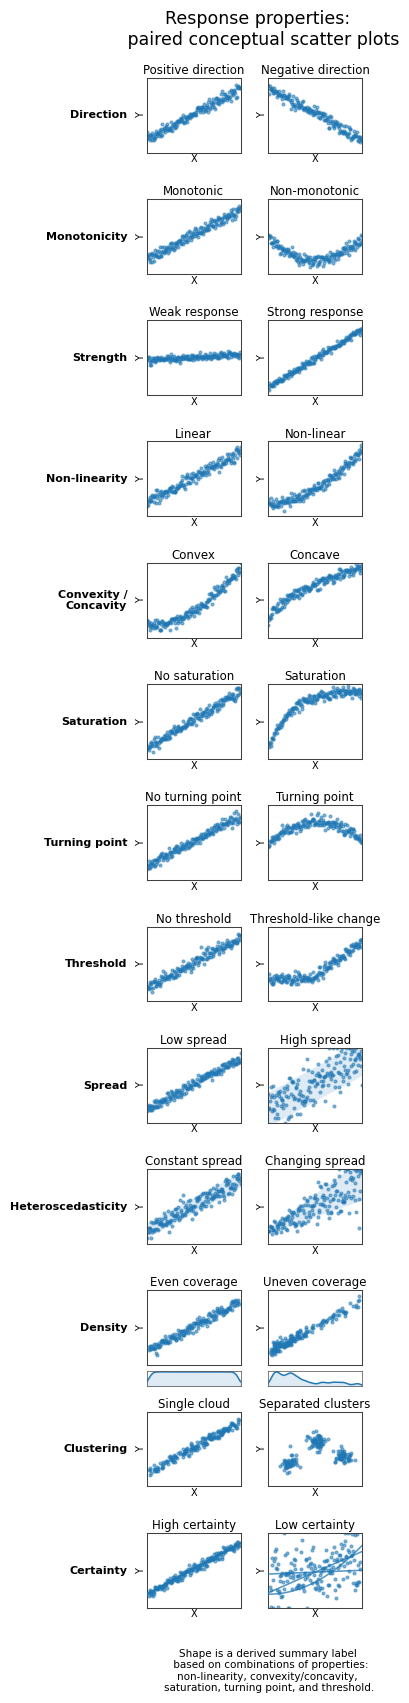

In [114]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# ==========================================================
# 0. Basic settings
# ==========================================================

np.random.seed(88)
rng = np.random.default_rng(88)

x = np.linspace(0, 1, 170)

POINT_COLOR = "C0"
BUFFER_COLOR = "C0"

properties = [
    ("Direction", "Positive direction", "Negative direction"),
    ("Monotonicity", "Monotonic", "Non-monotonic"),
    ("Strength", "Weak response", "Strong response"),
    ("Non-linearity", "Linear", "Non-linear"),
    ("Convexity / Concavity", "Convex", "Concave"),
    ("Saturation", "No saturation", "Saturation"),
    ("Turning point", "No turning point", "Turning point"),
    ("Threshold", "No threshold", "Threshold-like change"),
    ("Spread", "Low spread", "High spread"),
    ("Heteroscedasticity", "Constant spread", "Changing spread"),
    ("Density", "Even coverage", "Uneven coverage"),
    ("Clustering", "Single cloud", "Separated clusters"),
    ("Certainty", "High certainty", "Low certainty"),
]


# ==========================================================
# 1. Data generation
# ==========================================================

def kde_manual(values, grid, bandwidth=0.035):
    values = np.asarray(values)
    grid = np.asarray(grid)
    dens = np.zeros_like(grid, dtype=float)

    for v in values:
        dens += np.exp(-0.5 * ((grid - v) / bandwidth) ** 2)

    dens /= max(len(values), 1)
    dens = dens / dens.max() if dens.max() > 0 else dens
    return dens


def curve_data(prop):
    xx = x.copy()

    if prop == "Direction":
        return (
            (xx, 0.18 + 0.68 * xx),
            (xx, 0.86 - 0.68 * xx),
        )

    if prop == "Monotonicity":
        return (
            (xx, 0.18 + 0.68 * xx),
            (xx, 0.18 + 1.15 * (xx - 0.50) ** 2),
        )

    if prop == "Strength":
        return (
            (xx, 0.46 + 0.08 * xx),   # weak response
            (xx, 0.10 + 0.78 * xx),   # strong response
        )

    if prop == "Non-linearity":
        return (
            (xx, 0.18 + 0.68 * xx),
            (xx, 0.18 + 0.72 * xx**2),
        )

    if prop == "Convexity / Concavity":
        return (
            (xx, 0.16 + 0.78 * xx**2),
            (xx, 0.16 + 0.78 * np.sqrt(xx)),
        )

    if prop == "Saturation":
        return (
            (xx, 0.14 + 0.76 * xx),
            (xx, 0.14 + 0.76 * (1 - np.exp(-4.5 * xx))),
        )

    if prop == "Turning point":
        return (
            (xx, 0.18 + 0.68 * xx),
            (xx, 0.78 - 1.10 * (xx - 0.52) ** 2),
        )

    if prop == "Threshold":
        y_threshold = np.where(
            xx < 0.48,
            0.30 + 0.04 * xx,
            0.32 + 0.95 * (xx - 0.48),
        )
        return (
            (xx, 0.18 + 0.68 * xx),
            (xx, y_threshold),
        )

    if prop == "Spread":
        return (
            (xx, 0.18 + 0.68 * xx),
            (xx, 0.18 + 0.68 * xx),
        )

    if prop == "Heteroscedasticity":
        return (
            (xx, 0.18 + 0.68 * xx),
            (xx, 0.18 + 0.68 * xx),
        )

    if prop == "Density":
        x_even = np.linspace(0.02, 0.98, 170)

        x_uneven = np.concatenate([
            rng.uniform(0.02, 0.34, 110),
            rng.uniform(0.34, 0.98, 60),
        ])
        x_uneven = np.sort(x_uneven)

        return (
            (x_even, 0.18 + 0.68 * x_even),
            (x_uneven, 0.18 + 0.68 * x_uneven),
        )

    if prop == "Clustering":
        x_single = rng.uniform(0.02, 0.98, 170)
        y_single = 0.18 + 0.68 * x_single

        n1, n2, n3 = 55, 60, 55

        x_c1 = rng.normal(0.22, 0.045, n1)
        y_c1 = rng.normal(0.30, 0.045, n1)

        x_c2 = rng.normal(0.52, 0.050, n2)
        y_c2 = rng.normal(0.60, 0.050, n2)

        x_c3 = rng.normal(0.80, 0.045, n3)
        y_c3 = rng.normal(0.40, 0.045, n3)

        x_cluster = np.concatenate([x_c1, x_c2, x_c3])
        y_cluster = np.concatenate([y_c1, y_c2, y_c3])

        x_cluster = np.clip(x_cluster, 0.02, 0.98)
        y_cluster = np.clip(y_cluster, 0.05, 0.95)

        return (
            (x_single, y_single),
            (x_cluster, y_cluster),
        )

    if prop == "Certainty":
        x_good = np.linspace(0.02, 0.98, 170)
        y_good = 0.18 + 0.68 * x_good

        x_bad = np.linspace(0.02, 0.98, 170)
        y_bad = 0.35 + 0.30 * x_bad

        return (
            (x_good, y_good),
            (x_bad, y_bad),
        )

    raise ValueError(f"Unknown property: {prop}")


# ==========================================================
# 2. Plotting helper functions
# ==========================================================

def style_axis(ax):
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    # Rectangular plot: height / width
    ax.set_box_aspect(0.8)

    ax.set_xticks([])
    ax.set_yticks([])

    for spine in ["top", "right", "bottom", "left"]:
        ax.spines[spine].set_visible(True)
        ax.spines[spine].set_linewidth(0.75)
        ax.spines[spine].set_color("0.25")

    ax.set_xlabel("X", fontsize=7, labelpad=1)
    ax.set_ylabel("Y", fontsize=7, labelpad=1)


def add_buffer(ax, xx, yy, buffer_width, alpha=0.14):
    xx = np.asarray(xx)
    yy = np.asarray(yy)

    order = np.argsort(xx)
    xx_o = xx[order]
    yy_o = yy[order]

    if np.isscalar(buffer_width):
        bw = np.full_like(xx_o, buffer_width, dtype=float)
    else:
        bw = np.asarray(buffer_width)[order]

    ax.fill_between(
        xx_o,
        yy_o - bw,
        yy_o + bw,
        color=BUFFER_COLOR,
        alpha=alpha,
        linewidth=0,
        zorder=1,
    )

def draw_density_inset(ax, xx):
    grid = np.linspace(0, 1, 300)
    dens = kde_manual(xx, grid, bandwidth=0.035)

    ax_den = inset_axes(
        ax,
        width="100%",
        height="20%",
        loc="lower left",
        bbox_to_anchor=(0, -0.28, 1, 1),
        bbox_transform=ax.transAxes,
        borderpad=0,
    )

    ax_den.plot(grid, dens, linewidth=1.05, color=POINT_COLOR)
    ax_den.fill_between(grid, 0, dens, color=BUFFER_COLOR, alpha=0.14)

    ax_den.set_xlim(0, 1)
    ax_den.set_ylim(0, 1.05)
    ax_den.set_xticks([])
    ax_den.set_yticks([])

    for spine in ["top", "right", "bottom", "left"]:
        ax_den.spines[spine].set_visible(True)
        ax_den.spines[spine].set_linewidth(0.55)
        ax_den.spines[spine].set_color("0.35")


def draw_certainty_panel(ax, xx, yy, title, side):
    xx = np.asarray(xx)
    yy = np.asarray(yy)

    x_line = np.linspace(0, 1, 200)

    if side == 0:
        noise_sd = 0.030
        y_points = yy + np.random.normal(0, noise_sd, len(yy))

        lines = [
            0.18 + 0.68 * x_line,
            0.19 + 0.66 * x_line,
            0.17 + 0.70 * x_line,
        ]

    else:
        noise_sd = 0.20
        y_points = yy + np.random.normal(0, noise_sd, len(yy))

        lines = [
            0.20 + 0.55 * x_line,
            0.45 + 0.05 * x_line,
            0.18 + 0.65 * (x_line ** 2),
        ]

    y_points = np.clip(y_points, 0, 1)

    ax.scatter(
        xx,
        y_points,
        s=4,
        alpha=0.52,
        color=POINT_COLOR,
        zorder=2,
    )

    for line in lines:
        ax.plot(
            x_line,
            np.clip(line, 0, 1),
            linewidth=1.15,
            alpha=0.75,
            color=POINT_COLOR,
            zorder=3,
        )

    ax.set_title(title, fontsize=8.5, pad=3)
    style_axis(ax)


def draw_panel(ax, xx, yy, title, prop, side):
    xx = np.asarray(xx)
    yy = np.asarray(yy)

    if prop == "Certainty":
        draw_certainty_panel(ax, xx, yy, title, side)
        return

    if prop == "Strength":
        noise_sd = 0.025
        y_points = yy + np.random.normal(0, noise_sd, len(yy))

    elif prop == "Spread":
        noise_sd = 0.035 if side == 0 else 0.17
        y_points = yy + np.random.normal(0, noise_sd, len(yy))
        add_buffer(ax, xx, yy, noise_sd * 1.35, alpha=0.14)

    elif prop == "Heteroscedasticity":
        if side == 0:
            noise_sd = np.full_like(xx, 0.075)
        else:
            noise_sd = 0.025 + 0.18 * xx

        y_points = yy + np.random.normal(0, noise_sd, len(yy))
        add_buffer(ax, xx, yy, noise_sd * 1.35, alpha=0.14)

    elif prop == "Clustering":
        noise_sd = 0.035
        y_points = yy + np.random.normal(0, noise_sd, len(yy))

    else:
        noise_sd = 0.040
        y_points = yy + np.random.normal(0, noise_sd, len(yy))

    y_points = np.clip(y_points, 0, 1)

    ax.scatter(
        xx,
        y_points,
        s=4,
        alpha=0.52,
        color=POINT_COLOR,
        zorder=2,
    )

    ax.set_title(title, fontsize=8.5, pad=3)
    style_axis(ax)

# ==========================================================
# 3. Draw figure: one property per row, two plots per row
# ==========================================================

n_rows = len(properties)

# Use the same height for all rows.
# This keeps the Density main plot the same width as other plots.
height_ratios = [1.0 for _ in properties]

fig = plt.figure(figsize=(2.2, 17.0))

outer = GridSpec(
    n_rows,
    3,
    figure=fig,
    width_ratios=[0.24, 1, 1],
    height_ratios=height_ratios,
    hspace=0.62,      # larger row spacing to avoid density inset overlap
    wspace=0.14,
)

for i, (prop, left_title, right_title) in enumerate(properties):
    label_ax = fig.add_subplot(outer[i, 0])
    label_ax.axis("off")

    display_prop = prop.replace("Convexity / Concavity", "Convexity /\nConcavity")

    label_ax.text(
        1.0,
        0.5,
        display_prop,
        ha="right",
        va="center",
        fontsize=8.0,
        fontweight="bold",
    )

    (xl, yl), (xr, yr) = curve_data(prop)

    ax_l = fig.add_subplot(outer[i, 1])
    ax_r = fig.add_subplot(outer[i, 2])

    draw_panel(ax_l, xl, yl, left_title, prop, 0)
    draw_panel(ax_r, xr, yr, right_title, prop, 1)

    if prop == "Density":
        # Remove the main X labels to avoid overlap with the density panels.
        ax_l.set_xlabel("")
        ax_r.set_xlabel("")

        draw_density_inset(ax_l, xl)
        draw_density_inset(ax_r, xr)


fig.suptitle(
    "Response properties: \n paired conceptual scatter plots",
    fontsize=12.5,
    y=0.995,
)

shape_note = (
    "Shape is a derived summary label \n based on combinations of properties:\n"
    "non-linearity, convexity/concavity, \nsaturation, turning point, and threshold."
)

fig.text(
    0.54,
    0.018,
    shape_note,
    ha="center",
    va="center",
    fontsize=7.5,
)

plt.subplots_adjust(
    left=-0.225,
    right=0.999,
    top=0.955,
    bottom=0.055,
)

plt.show()

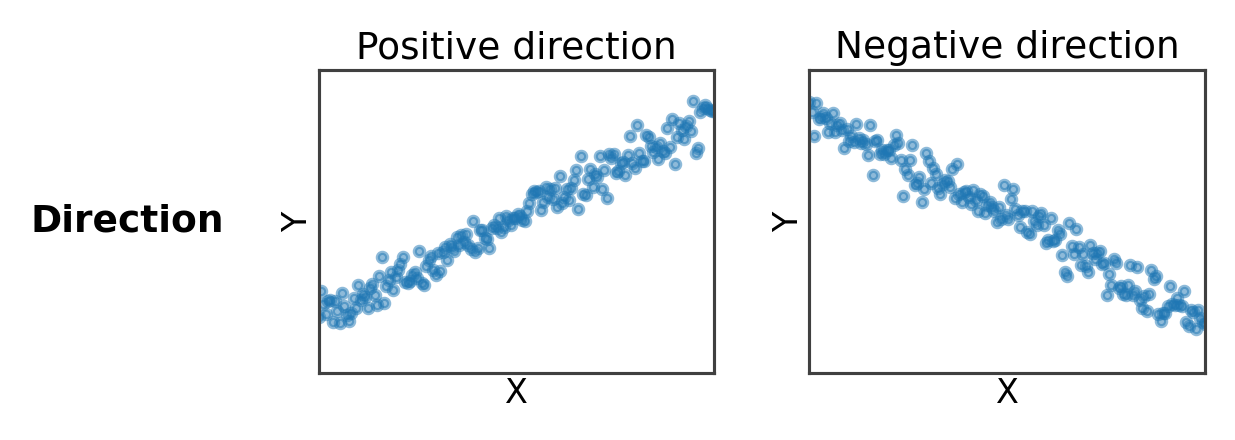

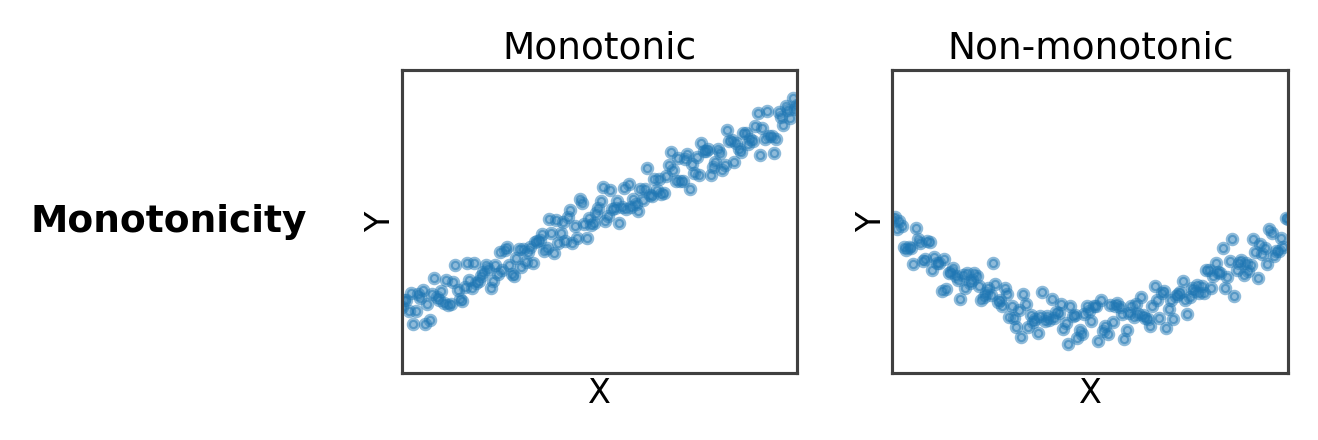

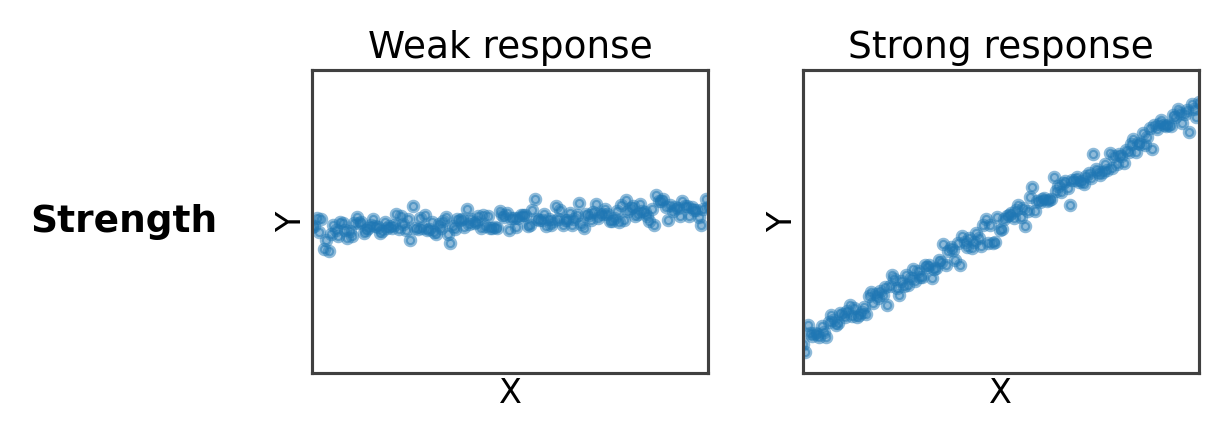

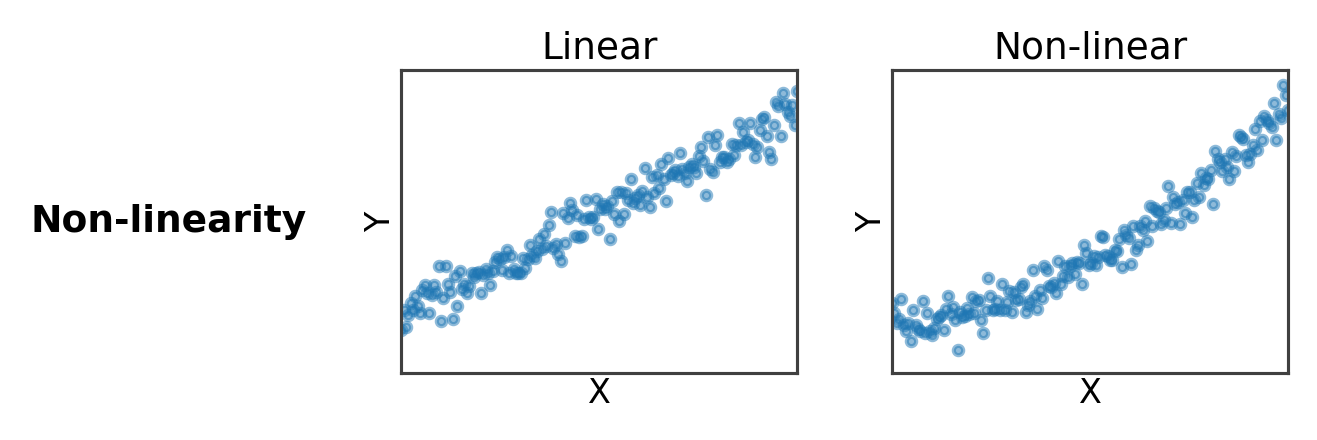

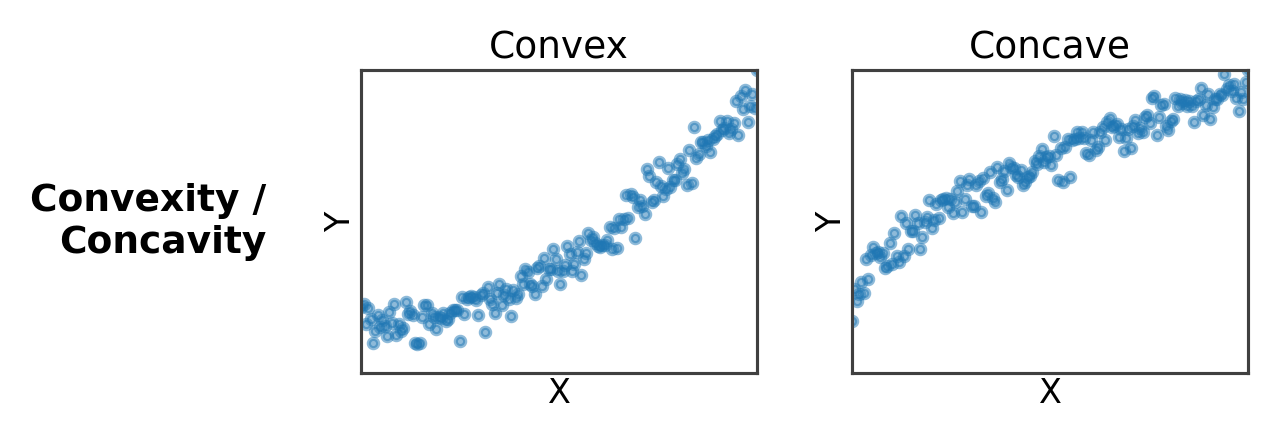

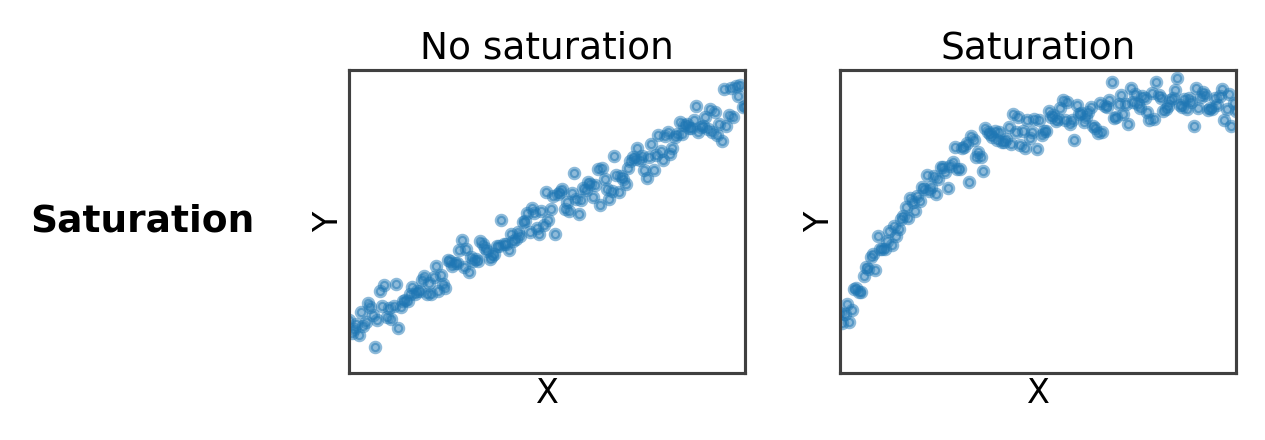

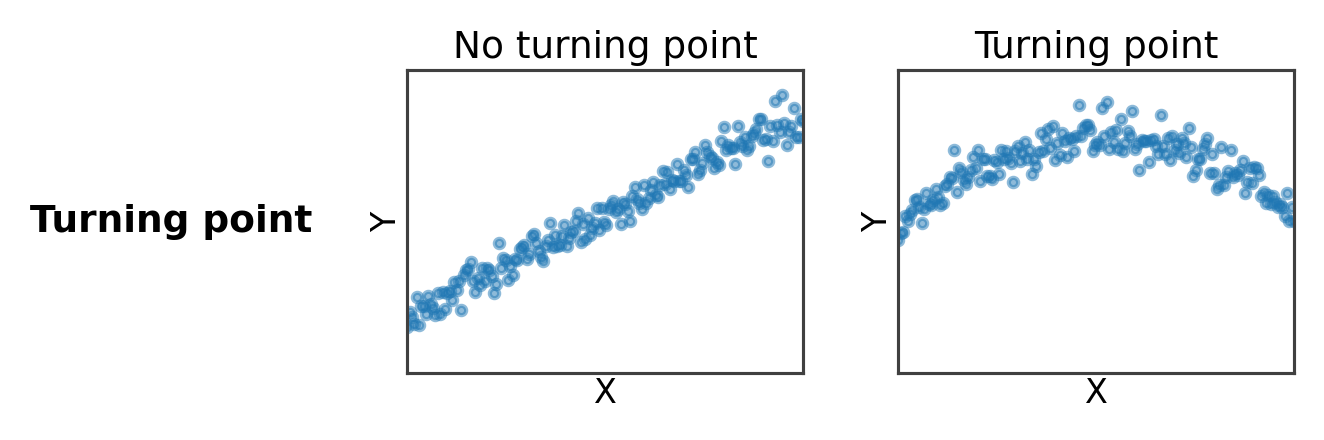

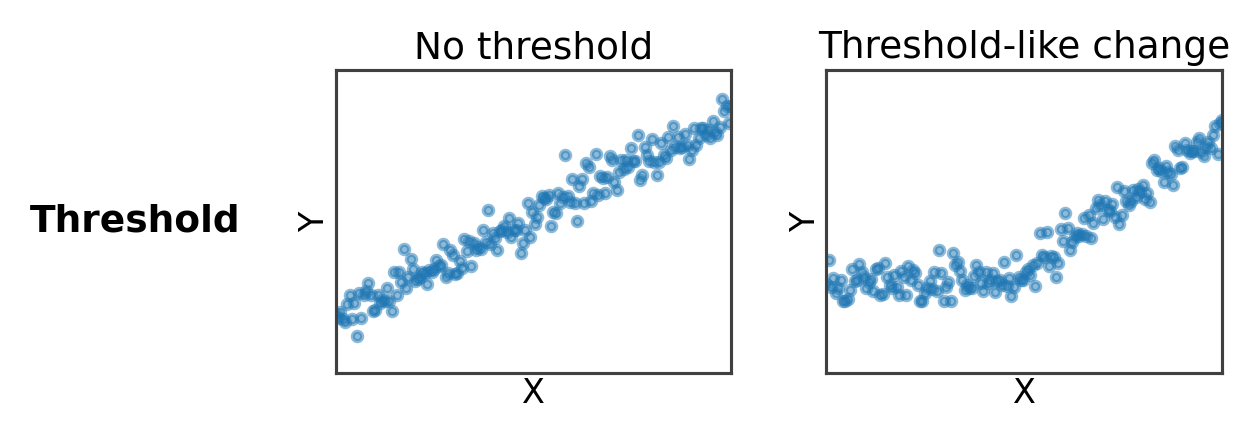

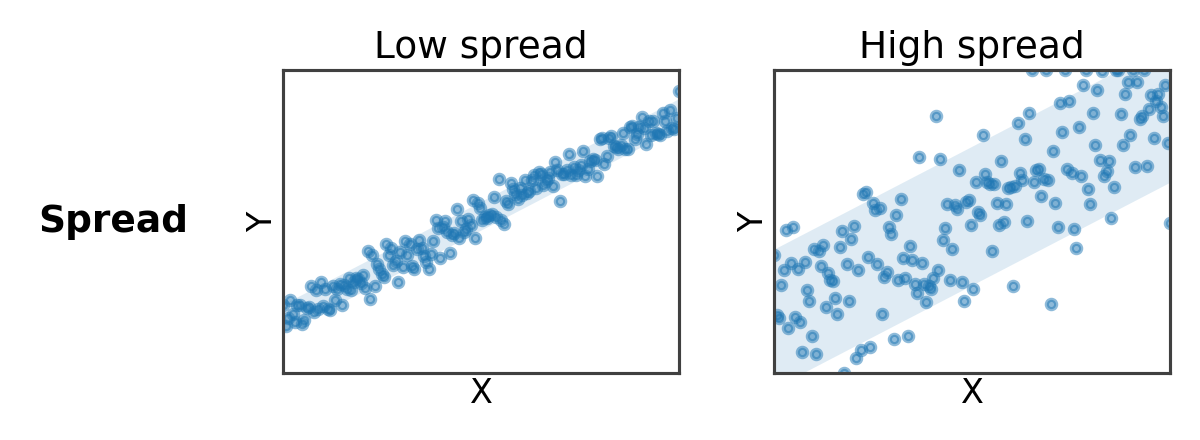

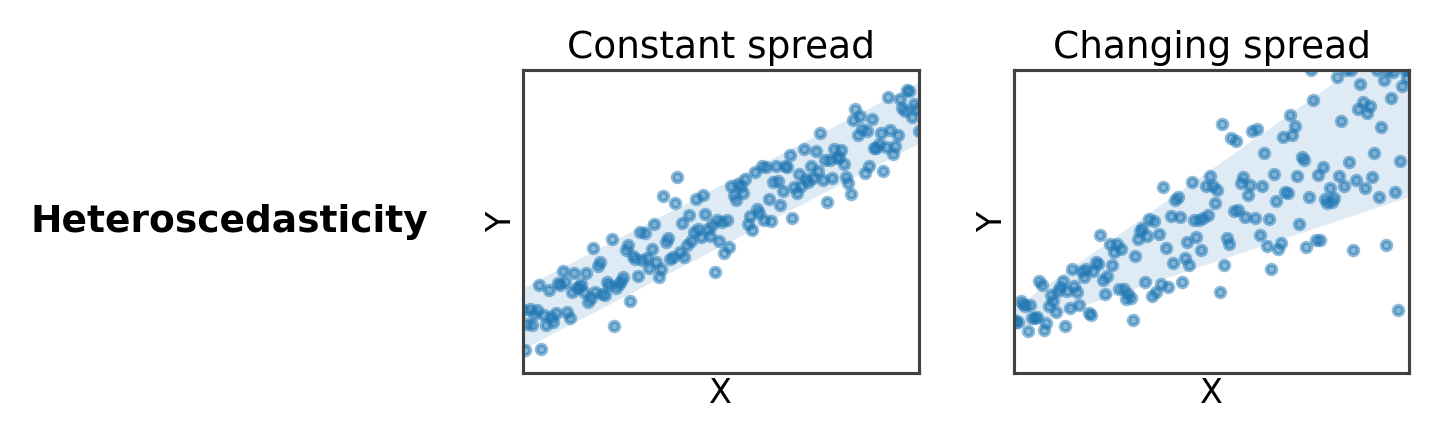

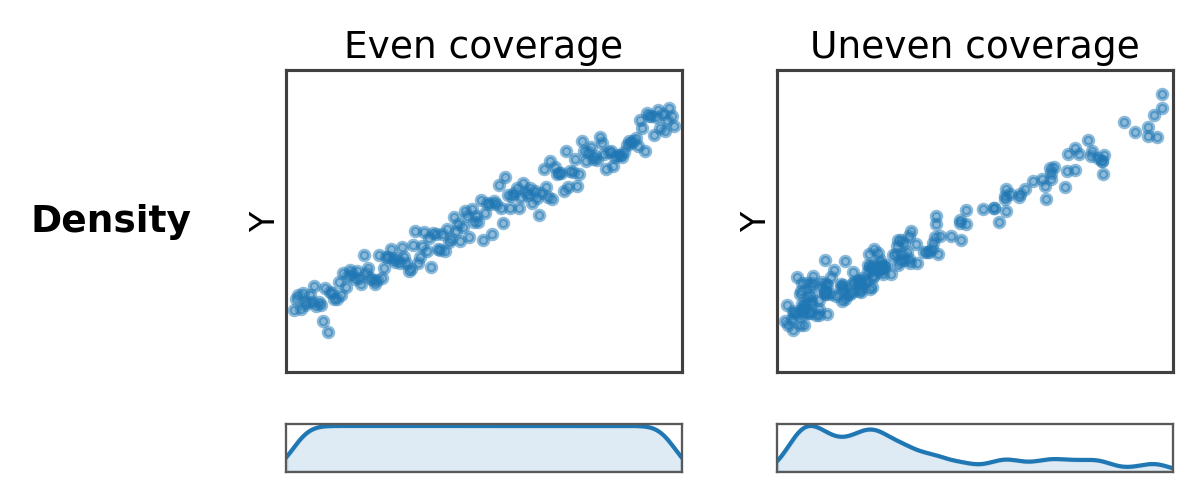

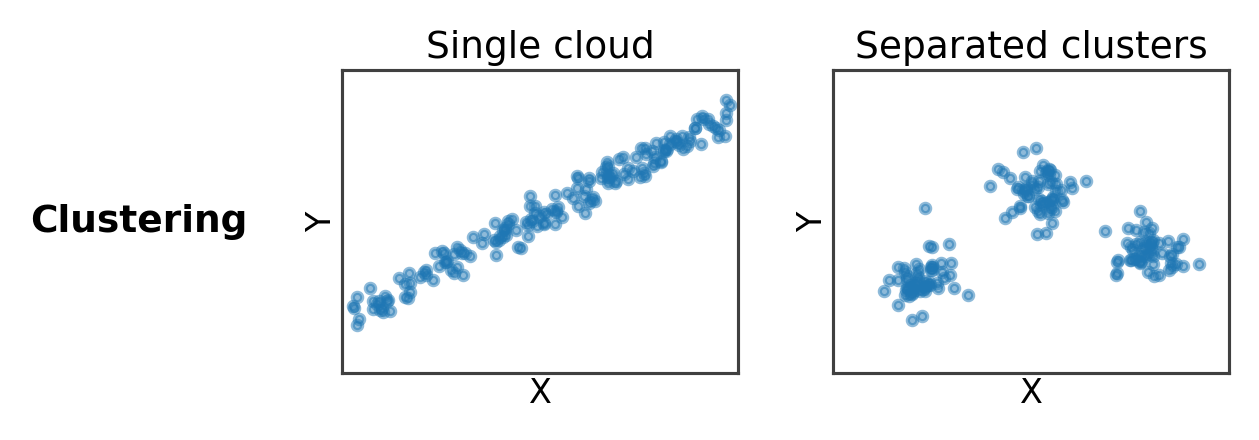

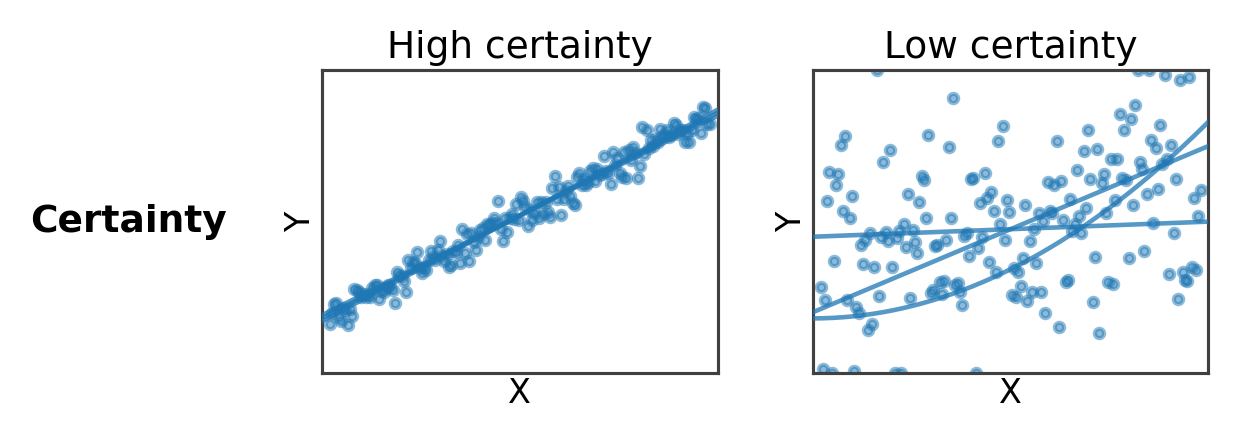

In [129]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# ==========================================================
# 0. Basic settings
# ==========================================================

np.random.seed(88)
rng = np.random.default_rng(88)

x = np.linspace(0, 1, 170)

POINT_COLOR = "C0"
BUFFER_COLOR = "C0"

properties = [
    ("Direction", "Positive direction", "Negative direction"),
    ("Monotonicity", "Monotonic", "Non-monotonic"),
    ("Strength", "Weak response", "Strong response"),
    ("Non-linearity", "Linear", "Non-linear"),
    ("Convexity / Concavity", "Convex", "Concave"),
    ("Saturation", "No saturation", "Saturation"),
    ("Turning point", "No turning point", "Turning point"),
    ("Threshold", "No threshold", "Threshold-like change"),
    ("Spread", "Low spread", "High spread"),
    ("Heteroscedasticity", "Constant spread", "Changing spread"),
    ("Density", "Even coverage", "Uneven coverage"),
    ("Clustering", "Single cloud", "Separated clusters"),
    ("Certainty", "High certainty", "Low certainty"),
]


# ==========================================================
# 1. Data generation
# ==========================================================

def kde_manual(values, grid, bandwidth=0.035):
    values = np.asarray(values)
    grid = np.asarray(grid)

    dens = np.zeros_like(grid, dtype=float)

    for v in values:
        dens += np.exp(-0.5 * ((grid - v) / bandwidth) ** 2)

    dens /= max(len(values), 1)

    if dens.max() > 0:
        dens = dens / dens.max()

    return dens


def curve_data(prop):
    xx = x.copy()

    if prop == "Direction":
        return (
            (xx, 0.18 + 0.68 * xx),
            (xx, 0.86 - 0.68 * xx),
        )

    if prop == "Monotonicity":
        return (
            (xx, 0.18 + 0.68 * xx),
            (xx, 0.18 + 1.15 * (xx - 0.50) ** 2),
        )

    if prop == "Strength":
        return (
            (xx, 0.46 + 0.08 * xx),
            (xx, 0.10 + 0.78 * xx),
        )

    if prop == "Non-linearity":
        return (
            (xx, 0.18 + 0.68 * xx),
            (xx, 0.18 + 0.72 * xx ** 2),
        )

    if prop == "Convexity / Concavity":
        return (
            (xx, 0.16 + 0.78 * xx ** 2),
            (xx, 0.16 + 0.78 * np.sqrt(xx)),
        )

    if prop == "Saturation":
        return (
            (xx, 0.14 + 0.76 * xx),
            (xx, 0.14 + 0.76 * (1 - np.exp(-4.5 * xx))),
        )

    if prop == "Turning point":
        return (
            (xx, 0.18 + 0.68 * xx),
            (xx, 0.78 - 1.10 * (xx - 0.52) ** 2),
        )

    if prop == "Threshold":
        y_threshold = np.where(
            xx < 0.48,
            0.30 + 0.04 * xx,
            0.32 + 0.95 * (xx - 0.48),
        )

        return (
            (xx, 0.18 + 0.68 * xx),
            (xx, y_threshold),
        )

    if prop == "Spread":
        return (
            (xx, 0.18 + 0.68 * xx),
            (xx, 0.18 + 0.68 * xx),
        )

    if prop == "Heteroscedasticity":
        return (
            (xx, 0.18 + 0.68 * xx),
            (xx, 0.18 + 0.68 * xx),
        )

    if prop == "Density":
        x_even = np.linspace(0.02, 0.98, 170)

        x_uneven = np.concatenate([
            rng.uniform(0.02, 0.34, 110),
            rng.uniform(0.34, 0.98, 60),
        ])
        x_uneven = np.sort(x_uneven)

        return (
            (x_even, 0.18 + 0.68 * x_even),
            (x_uneven, 0.18 + 0.68 * x_uneven),
        )

    if prop == "Clustering":
        x_single = rng.uniform(0.02, 0.98, 170)
        y_single = 0.18 + 0.68 * x_single

        n1, n2, n3 = 55, 60, 55

        x_c1 = rng.normal(0.22, 0.045, n1)
        y_c1 = rng.normal(0.30, 0.045, n1)

        x_c2 = rng.normal(0.52, 0.050, n2)
        y_c2 = rng.normal(0.60, 0.050, n2)

        x_c3 = rng.normal(0.80, 0.045, n3)
        y_c3 = rng.normal(0.40, 0.045, n3)

        x_cluster = np.concatenate([x_c1, x_c2, x_c3])
        y_cluster = np.concatenate([y_c1, y_c2, y_c3])

        x_cluster = np.clip(x_cluster, 0.02, 0.98)
        y_cluster = np.clip(y_cluster, 0.05, 0.95)

        return (
            (x_single, y_single),
            (x_cluster, y_cluster),
        )

    if prop == "Certainty":
        x_good = np.linspace(0.02, 0.98, 170)
        y_good = 0.18 + 0.68 * x_good

        x_bad = np.linspace(0.02, 0.98, 170)
        y_bad = 0.35 + 0.30 * x_bad

        return (
            (x_good, y_good),
            (x_bad, y_bad),
        )

    raise ValueError(f"Unknown property: {prop}")


# ==========================================================
# 2. Plotting helper functions
# ==========================================================

def style_axis(ax):
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    ax.set_xticks([])
    ax.set_yticks([])

    for spine in ["top", "right", "bottom", "left"]:
        ax.spines[spine].set_visible(True)
        ax.spines[spine].set_linewidth(0.75)
        ax.spines[spine].set_color("0.25")

    ax.set_xlabel("X", fontsize=8, labelpad=1)
    ax.set_ylabel("Y", fontsize=8, labelpad=1)


def add_buffer(ax, xx, yy, buffer_width, alpha=0.14):
    xx = np.asarray(xx)
    yy = np.asarray(yy)

    order = np.argsort(xx)
    xx_o = xx[order]
    yy_o = yy[order]

    if np.isscalar(buffer_width):
        bw = np.full_like(xx_o, buffer_width, dtype=float)
    else:
        bw = np.asarray(buffer_width)[order]

    ax.fill_between(
        xx_o,
        yy_o - bw,
        yy_o + bw,
        color=BUFFER_COLOR,
        alpha=alpha,
        linewidth=0,
        zorder=1,
    )


def draw_density_inset(ax, xx):
    grid = np.linspace(0, 1, 300)
    dens = kde_manual(xx, grid, bandwidth=0.035)

    ax_den = inset_axes(
        ax,
        width="100%",
        height="16%",
        loc="lower left",
        bbox_to_anchor=(0, -0.33, 1, 1),
        bbox_transform=ax.transAxes,
        borderpad=0,
    )

    ax_den.plot(grid, dens, linewidth=1.0, color=POINT_COLOR)
    ax_den.fill_between(grid, 0, dens, color=BUFFER_COLOR, alpha=0.14)

    ax_den.set_xlim(0, 1)
    ax_den.set_ylim(0, 1.05)
    ax_den.set_xticks([])
    ax_den.set_yticks([])

    for spine in ["top", "right", "bottom", "left"]:
        ax_den.spines[spine].set_visible(True)
        ax_den.spines[spine].set_linewidth(0.55)
        ax_den.spines[spine].set_color("0.35")


def draw_certainty_panel(ax, xx, yy, title, side):
    xx = np.asarray(xx)
    yy = np.asarray(yy)

    x_line = np.linspace(0, 1, 200)

    if side == 0:
        noise_sd = 0.030
        y_points = yy + np.random.normal(0, noise_sd, len(yy))

        lines = [
            0.18 + 0.68 * x_line,
            0.19 + 0.66 * x_line,
            0.17 + 0.70 * x_line,
        ]

    else:
        noise_sd = 0.20
        y_points = yy + np.random.normal(0, noise_sd, len(yy))

        lines = [
            0.20 + 0.55 * x_line,
            0.45 + 0.05 * x_line,
            0.18 + 0.65 * (x_line ** 2),
        ]

    y_points = np.clip(y_points, 0, 1)

    ax.scatter(
        xx,
        y_points,
        s=5,
        alpha=0.50,
        color=POINT_COLOR,
        zorder=2,
    )

    for line in lines:
        ax.plot(
            x_line,
            np.clip(line, 0, 1),
            linewidth=1.10,
            alpha=0.75,
            color=POINT_COLOR,
            zorder=3,
        )

    ax.set_title(title, fontsize=9, pad=3)
    style_axis(ax)


def draw_panel(ax, xx, yy, title, prop, side):
    xx = np.asarray(xx)
    yy = np.asarray(yy)

    if prop == "Certainty":
        draw_certainty_panel(ax, xx, yy, title, side)
        return

    if prop == "Strength":
        noise_sd = 0.025
        y_points = yy + np.random.normal(0, noise_sd, len(yy))

    elif prop == "Spread":
        noise_sd = 0.035 if side == 0 else 0.17
        y_points = yy + np.random.normal(0, noise_sd, len(yy))
        add_buffer(ax, xx, yy, noise_sd * 1.35, alpha=0.14)

    elif prop == "Heteroscedasticity":
        if side == 0:
            noise_sd = np.full_like(xx, 0.075)
        else:
            noise_sd = 0.025 + 0.18 * xx

        y_points = yy + np.random.normal(0, noise_sd, len(yy))
        add_buffer(ax, xx, yy, noise_sd * 1.35, alpha=0.14)

    elif prop == "Clustering":
        noise_sd = 0.035
        y_points = yy + np.random.normal(0, noise_sd, len(yy))

    else:
        noise_sd = 0.040
        y_points = yy + np.random.normal(0, noise_sd, len(yy))

    y_points = np.clip(y_points, 0, 1)

    ax.scatter(
        xx,
        y_points,
        s=5,
        alpha=0.50,
        color=POINT_COLOR,
        zorder=2,
    )

    ax.set_title(title, fontsize=9, pad=3)
    style_axis(ax)


# ==========================================================
# 3. Draw one separate figure for each property
#    All figures have the same size
# ==========================================================

for prop, left_title, right_title in properties:
    fig = plt.figure(figsize=(4, 1.8), dpi=300)

    outer = GridSpec(
        1,
        3,
        figure=fig,
        width_ratios=[0.4, 1, 1],
        wspace=0.30,
        hspace=0.2
    )

    label_ax = fig.add_subplot(outer[0, 0])
    label_ax.axis("off")

    display_prop = prop.replace(
        "Convexity / Concavity",
        "Convexity /\nConcavity"
    )

    label_ax.text(
        1.0,
        0.5,
        display_prop,
        ha="right",
        va="center",
        fontsize=9,
        fontweight="bold",
    )

    (xl, yl), (xr, yr) = curve_data(prop)

    ax_l = fig.add_subplot(outer[0, 1])
    ax_r = fig.add_subplot(outer[0, 2])

    draw_panel(ax_l, xl, yl, left_title, prop, 0)
    draw_panel(ax_r, xr, yr, right_title, prop, 1)

    if prop == "Density":
        ax_l.set_xlabel("")
        ax_r.set_xlabel("")
        draw_density_inset(ax_l, xl)
        draw_density_inset(ax_r, xr)

    plt.subplots_adjust(
        left=0.03,
        right=0.98,
        top=0.80,
        bottom=0.24,
    )

    plt.show()

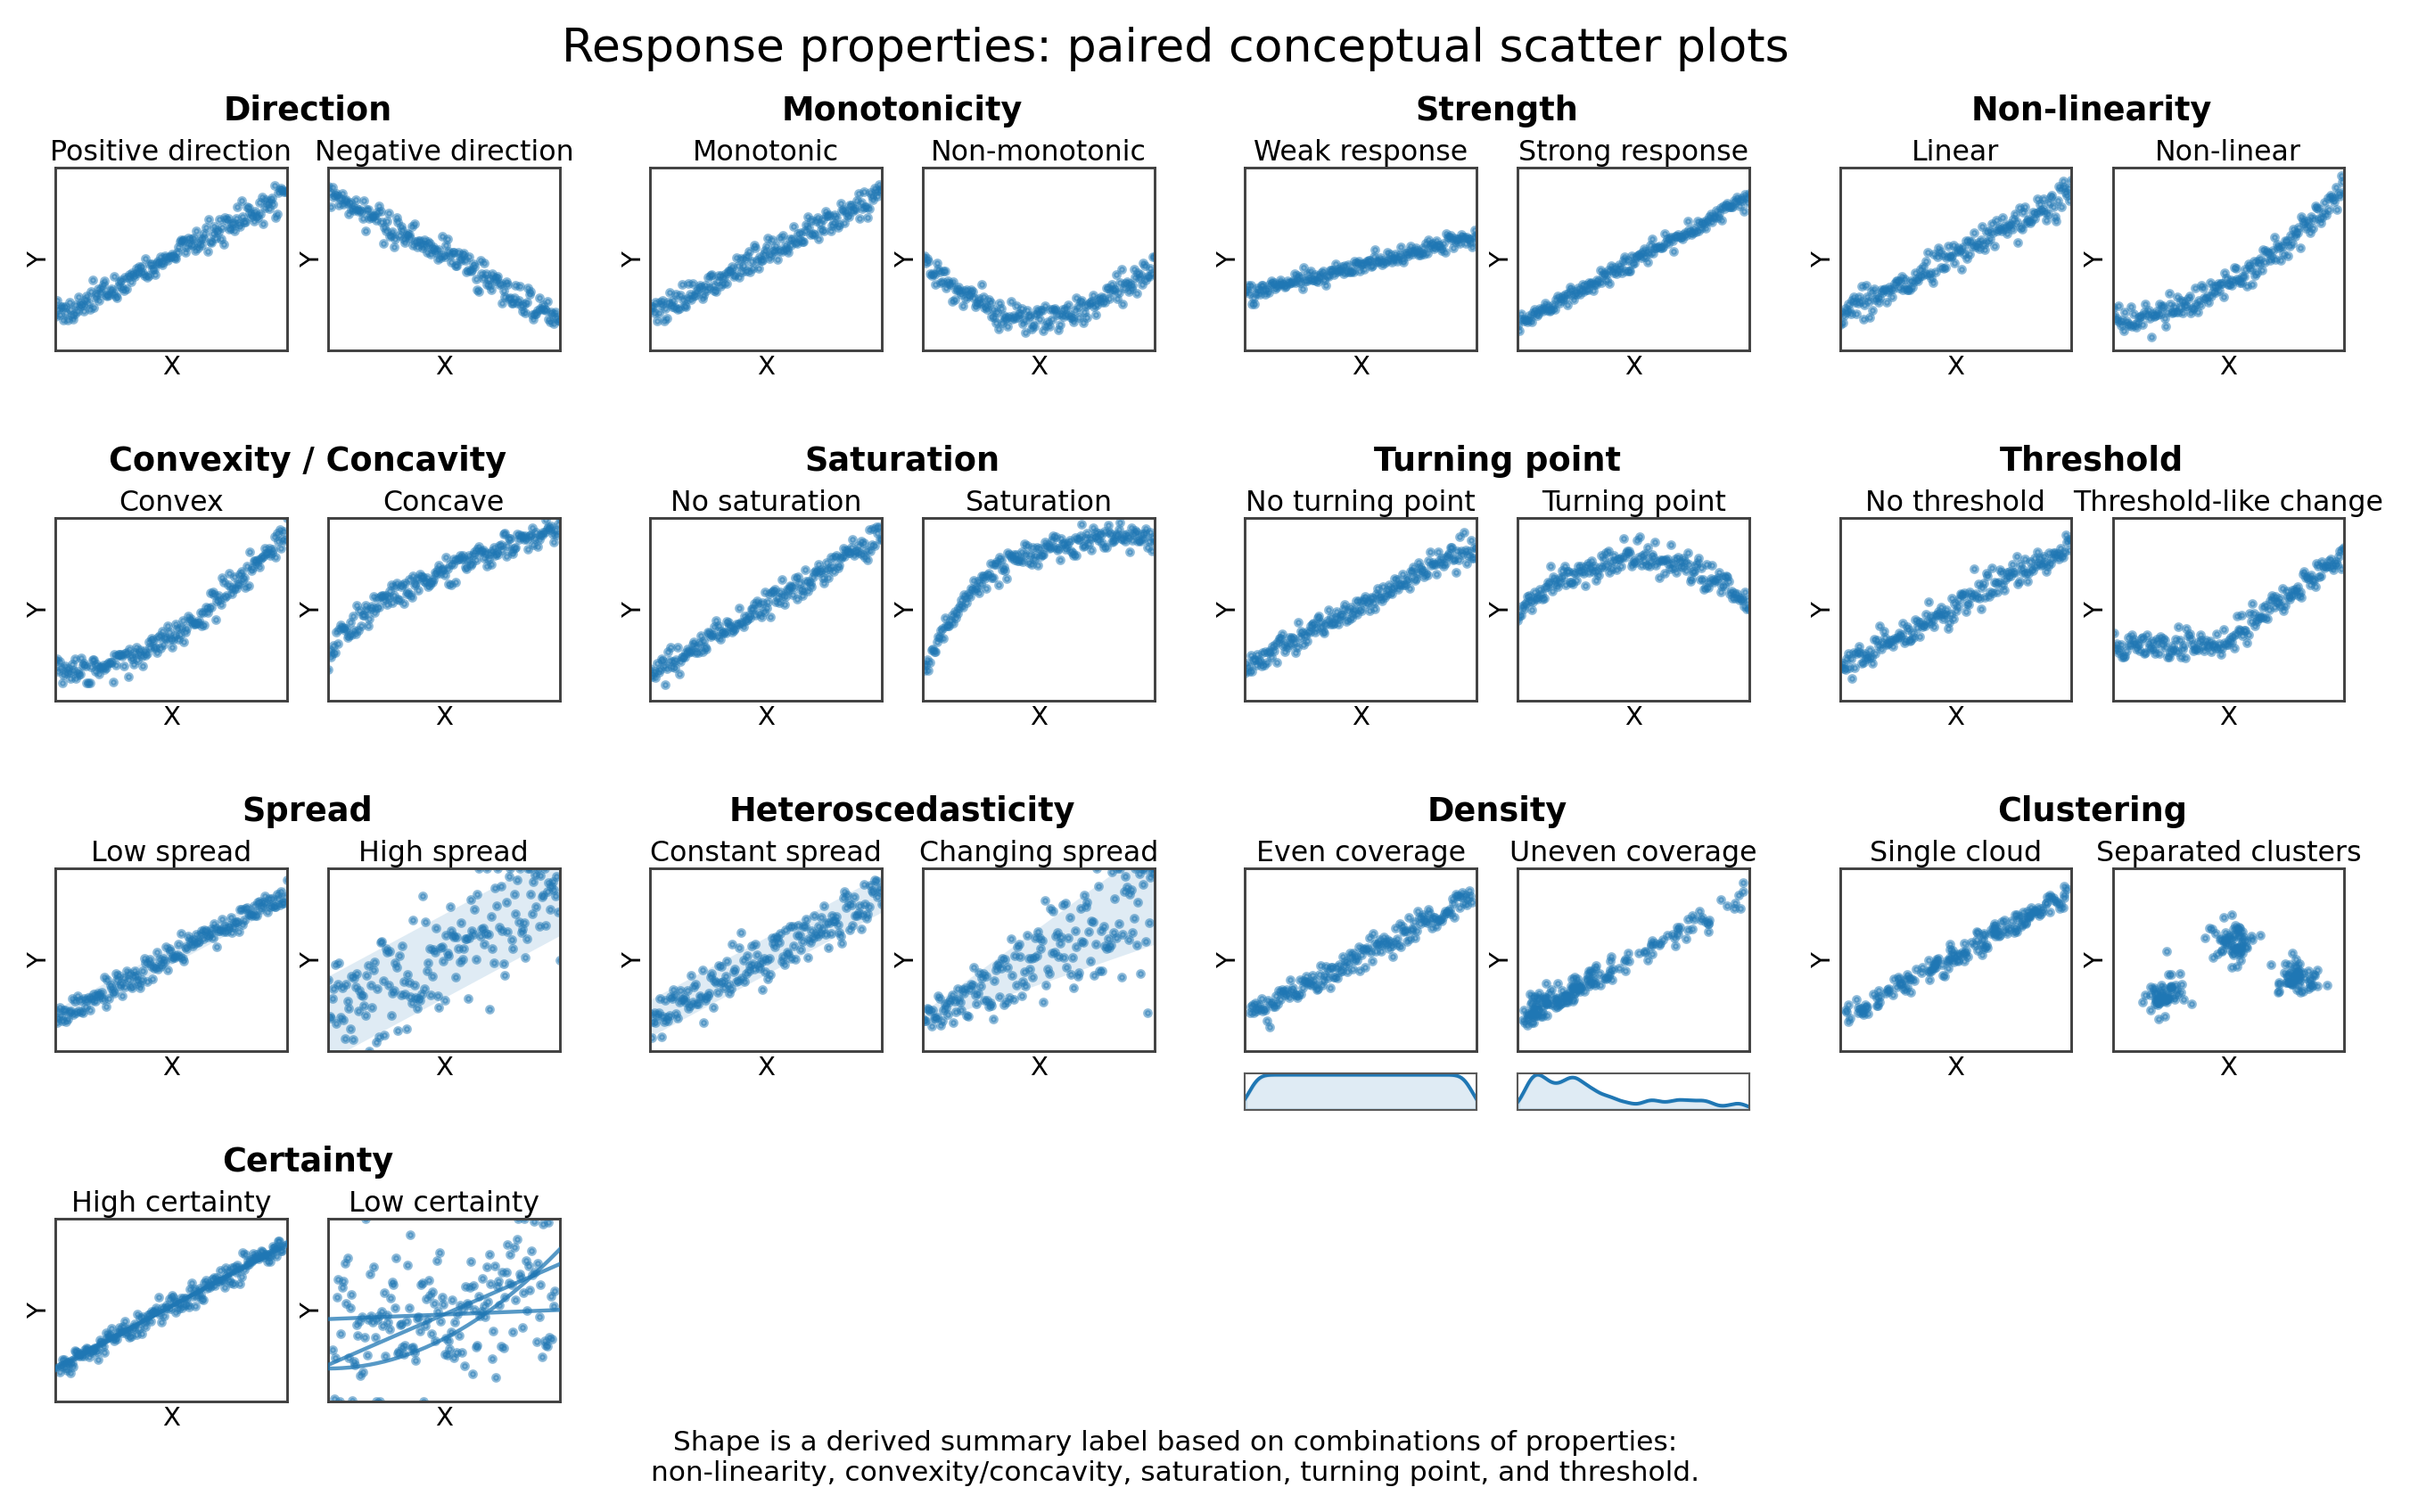

In [159]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# ==========================================================
# 0. Basic settings
# ==========================================================

np.random.seed(88)
rng = np.random.default_rng(88)

x = np.linspace(0, 1, 170)

POINT_COLOR = "C0"
BUFFER_COLOR = "C0"

properties = [
    ("Direction", "Positive direction", "Negative direction"),
    ("Monotonicity", "Monotonic", "Non-monotonic"),
    ("Strength", "Weak response", "Strong response"),
    ("Non-linearity", "Linear", "Non-linear"),
    ("Convexity / Concavity", "Convex", "Concave"),
    ("Saturation", "No saturation", "Saturation"),
    ("Turning point", "No turning point", "Turning point"),
    ("Threshold", "No threshold", "Threshold-like change"),
    ("Spread", "Low spread", "High spread"),
    ("Heteroscedasticity", "Constant spread", "Changing spread"),
    ("Density", "Even coverage", "Uneven coverage"),
    ("Clustering", "Single cloud", "Separated clusters"),
    ("Certainty", "High certainty", "Low certainty"),
]


# ==========================================================
# 1. Data generation
# ==========================================================

def kde_manual(values, grid, bandwidth=0.035):
    values = np.asarray(values)
    grid = np.asarray(grid)

    dens = np.zeros_like(grid, dtype=float)

    for v in values:
        dens += np.exp(-0.5 * ((grid - v) / bandwidth) ** 2)

    dens /= max(len(values), 1)

    if dens.max() > 0:
        dens = dens / dens.max()

    return dens


def curve_data(prop):
    xx = x.copy()

    if prop == "Direction":
        return (
            (xx, 0.18 + 0.68 * xx),
            (xx, 0.86 - 0.68 * xx),
        )

    if prop == "Monotonicity":
        return (
            (xx, 0.18 + 0.68 * xx),
            (xx, 0.18 + 1.15 * (xx - 0.50) ** 2),
        )

    # if prop == "Strength":
    #     return (
    #         (xx, 0.46 + 0.08 * xx),
    #         (xx, 0.10 + 0.78 * xx),
    #     )
    if prop == "Strength":
        return (
            (xx, 0.30 + 0.32 * xx),   # moderate / weaker response
            (xx, 0.14 + 0.70 * xx),   # stronger response
        )

    if prop == "Non-linearity":
        return (
            (xx, 0.18 + 0.68 * xx),
            (xx, 0.18 + 0.72 * xx ** 2),
        )

    if prop == "Convexity / Concavity":
        return (
            (xx, 0.16 + 0.78 * xx ** 2),
            (xx, 0.16 + 0.78 * np.sqrt(xx)),
        )

    if prop == "Saturation":
        return (
            (xx, 0.14 + 0.76 * xx),
            (xx, 0.14 + 0.76 * (1 - np.exp(-4.5 * xx))),
        )

    if prop == "Turning point":
        return (
            (xx, 0.18 + 0.68 * xx),
            (xx, 0.78 - 1.10 * (xx - 0.52) ** 2),
        )

    if prop == "Threshold":
        y_threshold = np.where(
            xx < 0.48,
            0.30 + 0.04 * xx,
            0.32 + 0.95 * (xx - 0.48),
        )

        return (
            (xx, 0.18 + 0.68 * xx),
            (xx, y_threshold),
        )

    if prop == "Spread":
        return (
            (xx, 0.18 + 0.68 * xx),
            (xx, 0.18 + 0.68 * xx),
        )

    if prop == "Heteroscedasticity":
        return (
            (xx, 0.18 + 0.68 * xx),
            (xx, 0.18 + 0.68 * xx),
        )

    if prop == "Density":
        x_even = np.linspace(0.02, 0.98, 170)

        x_uneven = np.concatenate([
            rng.uniform(0.02, 0.34, 110),
            rng.uniform(0.34, 0.98, 60),
        ])
        x_uneven = np.sort(x_uneven)

        return (
            (x_even, 0.18 + 0.68 * x_even),
            (x_uneven, 0.18 + 0.68 * x_uneven),
        )

    if prop == "Clustering":
        x_single = rng.uniform(0.02, 0.98, 170)
        y_single = 0.18 + 0.68 * x_single

        n1, n2, n3 = 55, 60, 55

        x_c1 = rng.normal(0.22, 0.045, n1)
        y_c1 = rng.normal(0.30, 0.045, n1)

        x_c2 = rng.normal(0.52, 0.050, n2)
        y_c2 = rng.normal(0.60, 0.050, n2)

        x_c3 = rng.normal(0.80, 0.045, n3)
        y_c3 = rng.normal(0.40, 0.045, n3)

        x_cluster = np.concatenate([x_c1, x_c2, x_c3])
        y_cluster = np.concatenate([y_c1, y_c2, y_c3])

        x_cluster = np.clip(x_cluster, 0.02, 0.98)
        y_cluster = np.clip(y_cluster, 0.05, 0.95)

        return (
            (x_single, y_single),
            (x_cluster, y_cluster),
        )

    if prop == "Certainty":
        x_good = np.linspace(0.02, 0.98, 170)
        y_good = 0.18 + 0.68 * x_good

        x_bad = np.linspace(0.02, 0.98, 170)
        y_bad = 0.35 + 0.30 * x_bad

        return (
            (x_good, y_good),
            (x_bad, y_bad),
        )

    raise ValueError(f"Unknown property: {prop}")


# ==========================================================
# 2. Plotting helpers
# ==========================================================

def style_axis(ax):
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    ax.set_xticks([])
    ax.set_yticks([])

    for spine in ["top", "right", "bottom", "left"]:
        ax.spines[spine].set_visible(True)
        ax.spines[spine].set_linewidth(0.70)
        ax.spines[spine].set_color("0.25")

    ax.set_xlabel("X", fontsize=7, labelpad=1)
    ax.set_ylabel("Y", fontsize=7, labelpad=1)


def add_buffer(ax, xx, yy, buffer_width, alpha=0.14):
    xx = np.asarray(xx)
    yy = np.asarray(yy)

    order = np.argsort(xx)
    xx_o = xx[order]
    yy_o = yy[order]

    if np.isscalar(buffer_width):
        bw = np.full_like(xx_o, buffer_width, dtype=float)
    else:
        bw = np.asarray(buffer_width)[order]

    ax.fill_between(
        xx_o,
        yy_o - bw,
        yy_o + bw,
        color=BUFFER_COLOR,
        alpha=alpha,
        linewidth=0,
        zorder=1,
    )


def draw_density_inset(ax, xx):
    grid = np.linspace(0, 1, 300)
    dens = kde_manual(xx, grid, bandwidth=0.035)

    ax_den = inset_axes(
        ax,
        width="100%",
        height="20%",
        loc="lower left",
        bbox_to_anchor=(0, -0.32, 1, 1),
        bbox_transform=ax.transAxes,
        borderpad=0,
    )

    ax_den.plot(grid, dens, linewidth=0.95, color=POINT_COLOR)
    ax_den.fill_between(grid, 0, dens, color=BUFFER_COLOR, alpha=0.14)

    ax_den.set_xlim(0, 1)
    ax_den.set_ylim(0, 1.05)
    ax_den.set_xticks([])
    ax_den.set_yticks([])

    for spine in ["top", "right", "bottom", "left"]:
        ax_den.spines[spine].set_visible(True)
        ax_den.spines[spine].set_linewidth(0.50)
        ax_den.spines[spine].set_color("0.35")


def draw_certainty_panel(ax, xx, yy, title, side):
    xx = np.asarray(xx)
    yy = np.asarray(yy)

    x_line = np.linspace(0, 1, 200)

    if side == 0:
        noise_sd = 0.030
        y_points = yy + np.random.normal(0, noise_sd, len(yy))

        lines = [
            0.18 + 0.68 * x_line,
            0.19 + 0.66 * x_line,
            0.17 + 0.70 * x_line,
        ]

    else:
        noise_sd = 0.20
        y_points = yy + np.random.normal(0, noise_sd, len(yy))

        lines = [
            0.20 + 0.55 * x_line,
            0.45 + 0.05 * x_line,
            0.18 + 0.65 * (x_line ** 2),
        ]

    y_points = np.clip(y_points, 0, 1)

    ax.scatter(
        xx,
        y_points,
        s=2.5,
        alpha=0.5,
        color=POINT_COLOR,
        zorder=2,
    )

    for line in lines:
        ax.plot(
            x_line,
            np.clip(line, 0, 1),
            linewidth=1.05,
            alpha=0.75,
            color=POINT_COLOR,
            zorder=3,
        )

    ax.set_title(title, fontsize=7.6, pad=2)
    style_axis(ax)


def draw_panel(ax, xx, yy, title, prop, side):
    xx = np.asarray(xx)
    yy = np.asarray(yy)

    if prop == "Certainty":
        draw_certainty_panel(ax, xx, yy, title, side)
        return

    if prop == "Strength":
        noise_sd = 0.025
        y_points = yy + np.random.normal(0, noise_sd, len(yy))

    elif prop == "Spread":
        noise_sd = 0.035 if side == 0 else 0.17
        y_points = yy + np.random.normal(0, noise_sd, len(yy))
        add_buffer(ax, xx, yy, noise_sd * 1.35, alpha=0.14)

    elif prop == "Heteroscedasticity":
        if side == 0:
            noise_sd = np.full_like(xx, 0.075)
        else:
            noise_sd = 0.025 + 0.18 * xx

        y_points = yy + np.random.normal(0, noise_sd, len(yy))
        add_buffer(ax, xx, yy, noise_sd * 1.35, alpha=0.14)

    elif prop == "Clustering":
        noise_sd = 0.035
        y_points = yy + np.random.normal(0, noise_sd, len(yy))

    else:
        noise_sd = 0.040
        y_points = yy + np.random.normal(0, noise_sd, len(yy))

    y_points = np.clip(y_points, 0, 1)

    ax.scatter(
        xx,
        y_points,
        s=2.5,
        alpha=0.5,
        color=POINT_COLOR,
        zorder=2,
    )

    ax.set_title(title, fontsize=7.6, pad=2)
    style_axis(ax)


# ==========================================================
# 3. Combine 13 groups into one figure, arranged in 2 columns
# ==========================================================

n_cols = 4
n_rows = int(np.ceil(len(properties) / n_cols))

fig = plt.figure(figsize=(9.2, 5.5), dpi=300)

outer = GridSpec(
    n_rows,
    n_cols,
    figure=fig,
    hspace=0.32,
    wspace=0.18,
)

for idx, (prop, left_title, right_title) in enumerate(properties):
    row = idx // n_cols
    col = idx % n_cols

    # One property block:
    # row 0: property title
    # row 1: two function-value panels
    cell = GridSpecFromSubplotSpec(
        2,
        2,
        subplot_spec=outer[row, col],
        height_ratios=[0.20, 0.80],
        hspace=0.32,
        wspace=0.18,
    )

    title_ax = fig.add_subplot(cell[0, :])
    title_ax.axis("off")

    display_prop = prop.replace("Convexity / Concavity", "Convexity / Concavity")

    title_ax.text(
        0.5,
        0.45,
        display_prop,
        ha="center",
        va="center",
        fontsize=8.8,
        fontweight="bold",
    )

    (xl, yl), (xr, yr) = curve_data(prop)

    ax_l = fig.add_subplot(cell[1, 0])
    ax_r = fig.add_subplot(cell[1, 1])

    draw_panel(ax_l, xl, yl, left_title, prop, 0)
    draw_panel(ax_r, xr, yr, right_title, prop, 1)

    if prop == "Density":
        ax_l.set_xlabel("")
        ax_r.set_xlabel("")
        draw_density_inset(ax_l, xl)
        draw_density_inset(ax_r, xr)

# Empty cell for the 14th position
if len(properties) % n_cols != 0:
    empty_ax = fig.add_subplot(outer[-1, -1])
    empty_ax.axis("off")

fig.suptitle(
    "Response properties: paired conceptual scatter plots",
    fontsize=12.5,
    y=0.995,
)

shape_note = (
    "Shape is a derived summary label based on combinations of properties:\n"
    "non-linearity, convexity/concavity, saturation, turning point, and threshold."
)

fig.text(
    0.5,
    0.022,
    shape_note,
    ha="center",
    va="center",
    fontsize=7.5,
)

plt.subplots_adjust(
    left=0.045,
    right=0.975,
    top=0.955,
    bottom=0.06,
)

plt.show()

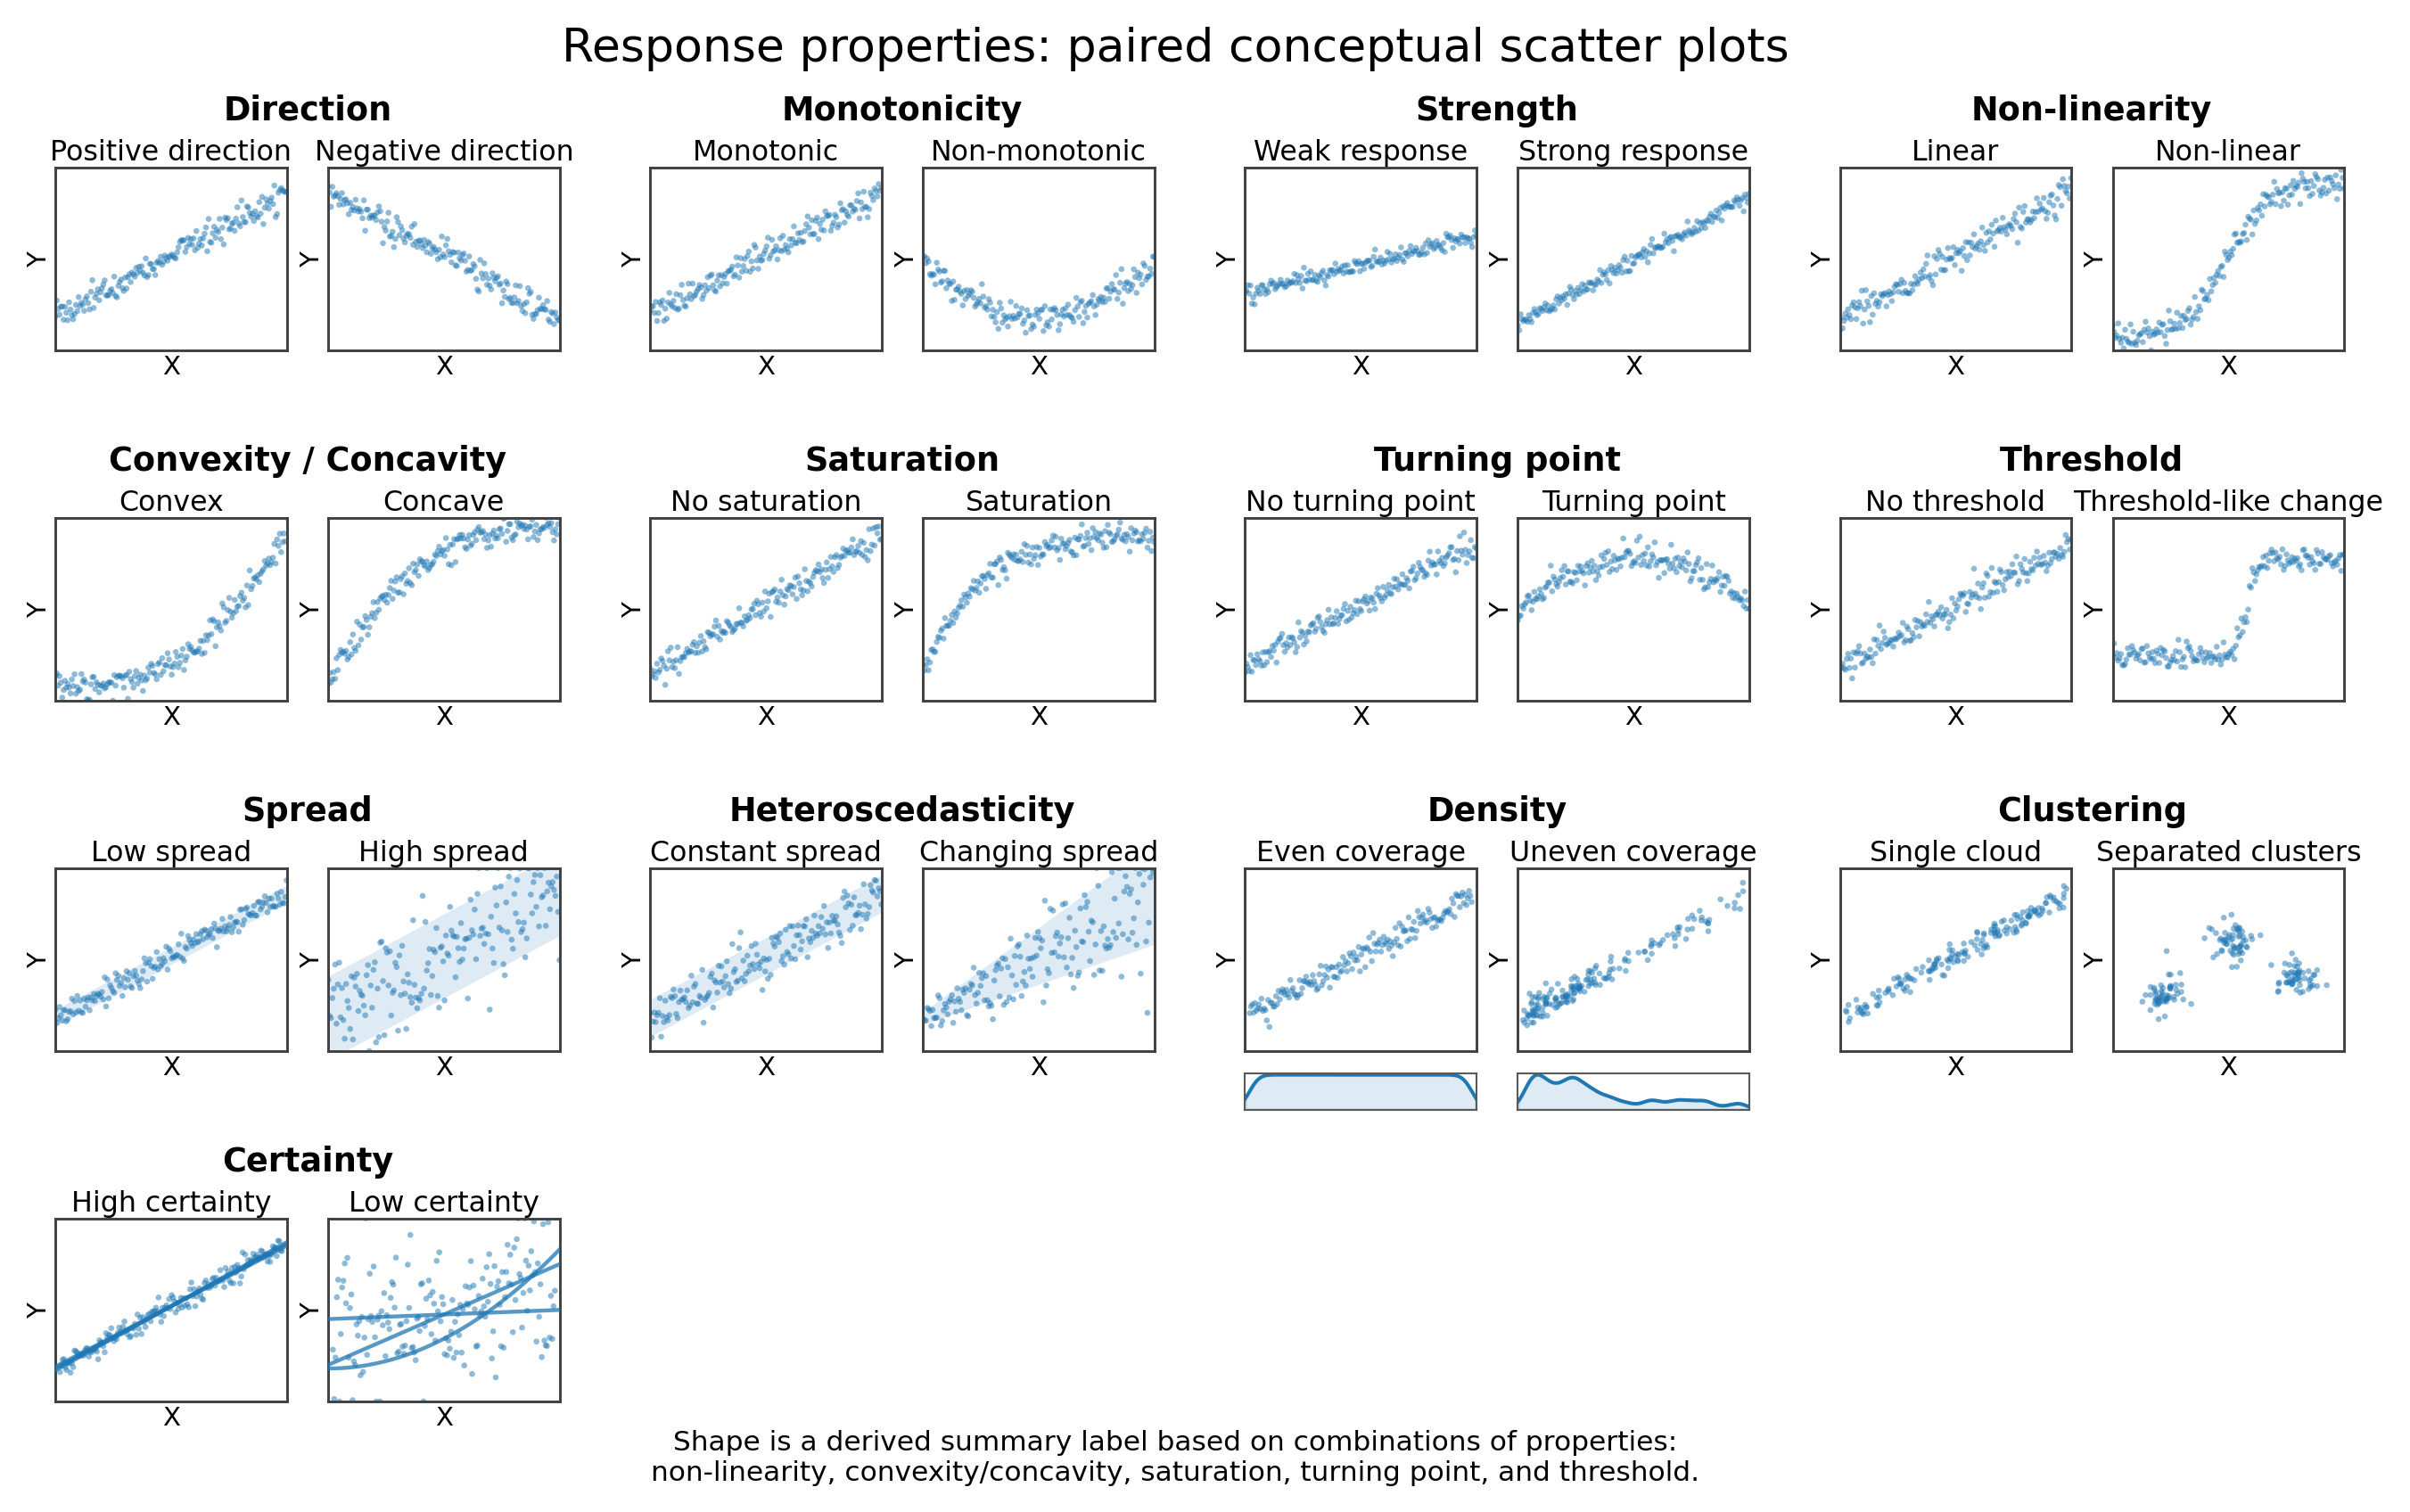

In [177]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# ==========================================================
# 0. Basic settings
# ==========================================================

np.random.seed(88)
rng = np.random.default_rng(88)

x = np.linspace(0, 1, 170)

POINT_COLOR = "C0"
BUFFER_COLOR = "C0"

properties = [
    ("Direction", "Positive direction", "Negative direction"),
    ("Monotonicity", "Monotonic", "Non-monotonic"),
    ("Strength", "Weak response", "Strong response"),
    ("Non-linearity", "Linear", "Non-linear"),
    ("Convexity / Concavity", "Convex", "Concave"),
    ("Saturation", "No saturation", "Saturation"),
    ("Turning point", "No turning point", "Turning point"),
    ("Threshold", "No threshold", "Threshold-like change"),
    ("Spread", "Low spread", "High spread"),
    ("Heteroscedasticity", "Constant spread", "Changing spread"),
    ("Density", "Even coverage", "Uneven coverage"),
    ("Clustering", "Single cloud", "Separated clusters"),
    ("Certainty", "High certainty", "Low certainty"),
]


# ==========================================================
# 1. Data generation
# ==========================================================

def kde_manual(values, grid, bandwidth=0.035):
    values = np.asarray(values)
    grid = np.asarray(grid)

    dens = np.zeros_like(grid, dtype=float)

    for v in values:
        dens += np.exp(-0.5 * ((grid - v) / bandwidth) ** 2)

    dens /= max(len(values), 1)

    if dens.max() > 0:
        dens = dens / dens.max()

    return dens


def curve_data(prop):
    xx = x.copy()

    if prop == "Direction":
        return (
            (xx, 0.18 + 0.68 * xx),
            (xx, 0.86 - 0.68 * xx),
        )

    if prop == "Monotonicity":
        return (
            (xx, 0.18 + 0.68 * xx),
            (xx, 0.18 + 1.15 * (xx - 0.50) ** 2),
        )

    if prop == "Strength":
        return (
            (xx, 0.30 + 0.32 * xx),
            (xx, 0.14 + 0.70 * xx),
        )

    if prop == "Non-linearity":
        y_linear = 0.15 + 0.72 * xx

        # Strong S-shaped nonlinearity:
        # slow-fast-slow pattern, clearly different from a straight line.
        y_nonlinear = 0.08 + 0.84 / (1 + np.exp(-11.0 * (xx - 0.50)))

        return (
            (xx, y_linear),
            (xx, y_nonlinear),
        )

    if prop == "Convexity / Concavity":
        # Strong convex: slow increase first, rapid increase later.
        y_convex = 0.08 + 0.86 * (xx ** 2.8)

        # Strong concave: rapid increase first, then flattening.
        y_concave = 0.08 + 0.86 * (1 - (1 - xx) ** 2.8)

        return (
            (xx, y_convex),
            (xx, y_concave),
        )

    if prop == "Saturation":
        return (
            (xx, 0.14 + 0.76 * xx),
            (xx, 0.14 + 0.76 * (1 - np.exp(-4.5 * xx))),
        )

    if prop == "Turning point":
        return (
            (xx, 0.18 + 0.68 * xx),
            (xx, 0.78 - 1.10 * (xx - 0.52) ** 2),
        )

    if prop == "Threshold":
        y_no_threshold = 0.18 + 0.68 * xx

        # Regime-shift threshold:
        # stable low state -> rapid transition -> stable high state
        threshold = 0.58
        y_threshold = 0.25 + 0.53 / (1 + np.exp(-45 * (xx - threshold)))

        return (
            (xx, y_no_threshold),
            (xx, y_threshold),
        )

    if prop == "Spread":
        return (
            (xx, 0.18 + 0.68 * xx),
            (xx, 0.18 + 0.68 * xx),
        )

    if prop == "Heteroscedasticity":
        return (
            (xx, 0.18 + 0.68 * xx),
            (xx, 0.18 + 0.68 * xx),
        )

    if prop == "Density":
        x_even = np.linspace(0.02, 0.98, 170)

        x_uneven = np.concatenate([
            rng.uniform(0.02, 0.34, 110),
            rng.uniform(0.34, 0.98, 60),
        ])
        x_uneven = np.sort(x_uneven)

        return (
            (x_even, 0.18 + 0.68 * x_even),
            (x_uneven, 0.18 + 0.68 * x_uneven),
        )

    if prop == "Clustering":
        x_single = rng.uniform(0.02, 0.98, 170)
        y_single = 0.18 + 0.68 * x_single

        n1, n2, n3 = 55, 60, 55

        x_c1 = rng.normal(0.22, 0.045, n1)
        y_c1 = rng.normal(0.30, 0.045, n1)

        x_c2 = rng.normal(0.52, 0.050, n2)
        y_c2 = rng.normal(0.60, 0.050, n2)

        x_c3 = rng.normal(0.80, 0.045, n3)
        y_c3 = rng.normal(0.40, 0.045, n3)

        x_cluster = np.concatenate([x_c1, x_c2, x_c3])
        y_cluster = np.concatenate([y_c1, y_c2, y_c3])

        x_cluster = np.clip(x_cluster, 0.02, 0.98)
        y_cluster = np.clip(y_cluster, 0.05, 0.95)

        return (
            (x_single, y_single),
            (x_cluster, y_cluster),
        )

    if prop == "Certainty":
        x_good = np.linspace(0.02, 0.98, 170)
        y_good = 0.18 + 0.68 * x_good

        x_bad = np.linspace(0.02, 0.98, 170)
        y_bad = 0.35 + 0.30 * x_bad

        return (
            (x_good, y_good),
            (x_bad, y_bad),
        )

    raise ValueError(f"Unknown property: {prop}")


# ==========================================================
# 2. Plotting helpers
# ==========================================================

def style_axis(ax):
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    ax.set_xticks([])
    ax.set_yticks([])

    for spine in ["top", "right", "bottom", "left"]:
        ax.spines[spine].set_visible(True)
        ax.spines[spine].set_linewidth(0.70)
        ax.spines[spine].set_color("0.25")

    ax.set_xlabel("X", fontsize=7, labelpad=1)
    ax.set_ylabel("Y", fontsize=7, labelpad=1)


def add_buffer(ax, xx, yy, buffer_width, alpha=0.14):
    xx = np.asarray(xx)
    yy = np.asarray(yy)

    order = np.argsort(xx)
    xx_o = xx[order]
    yy_o = yy[order]

    if np.isscalar(buffer_width):
        bw = np.full_like(xx_o, buffer_width, dtype=float)
    else:
        bw = np.asarray(buffer_width)[order]

    ax.fill_between(
        xx_o,
        yy_o - bw,
        yy_o + bw,
        color=BUFFER_COLOR,
        alpha=alpha,
        linewidth=0,
        zorder=1,
    )


def draw_density_inset(ax, xx):
    grid = np.linspace(0, 1, 300)
    dens = kde_manual(xx, grid, bandwidth=0.035)

    ax_den = inset_axes(
        ax,
        width="100%",
        height="20%",
        loc="lower left",
        bbox_to_anchor=(0, -0.32, 1, 1),
        bbox_transform=ax.transAxes,
        borderpad=0,
    )

    ax_den.plot(grid, dens, linewidth=0.95, color=POINT_COLOR)
    ax_den.fill_between(grid, 0, dens, color=BUFFER_COLOR, alpha=0.14)

    ax_den.set_xlim(0, 1)
    ax_den.set_ylim(0, 1.05)
    ax_den.set_xticks([])
    ax_den.set_yticks([])

    for spine in ["top", "right", "bottom", "left"]:
        ax_den.spines[spine].set_visible(True)
        ax_den.spines[spine].set_linewidth(0.50)
        ax_den.spines[spine].set_color("0.35")


def draw_certainty_panel(ax, xx, yy, title, side):
    xx = np.asarray(xx)
    yy = np.asarray(yy)

    x_line = np.linspace(0, 1, 200)

    if side == 0:
        noise_sd = 0.030
        y_points = yy + np.random.normal(0, noise_sd, len(yy))

        lines = [
            0.18 + 0.68 * x_line,
            0.19 + 0.66 * x_line,
            0.17 + 0.70 * x_line,
        ]

    else:
        noise_sd = 0.20
        y_points = yy + np.random.normal(0, noise_sd, len(yy))

        lines = [
            0.20 + 0.55 * x_line,
            0.45 + 0.05 * x_line,
            0.18 + 0.65 * (x_line ** 2),
        ]

    y_points = np.clip(y_points, 0, 1)

    ax.scatter(
        xx,
        y_points,
        s=2.5,
        alpha=0.5,
        color=POINT_COLOR,
        edgecolors="none",
        linewidths=0,
        zorder=2,
    )

    for line in lines:
        ax.plot(
            x_line,
            np.clip(line, 0, 1),
            linewidth=1.05,
            alpha=0.75,
            color=POINT_COLOR,
            zorder=3,
        )

    ax.set_title(title, fontsize=7.6, pad=2)
    style_axis(ax)


def draw_panel(ax, xx, yy, title, prop, side):
    xx = np.asarray(xx)
    yy = np.asarray(yy)

    if prop == "Certainty":
        draw_certainty_panel(ax, xx, yy, title, side)
        return

    if prop == "Strength":
        noise_sd = 0.025
        y_points = yy + np.random.normal(0, noise_sd, len(yy))

    elif prop == "Threshold":
        if side == 0:
            noise_sd = 0.040
            y_points = yy + np.random.normal(0, noise_sd, len(yy))
        else:
            # Stable state -> rapid transition -> new stable state.
            # Constant noise keeps both regimes visually stable.
            noise_sd = 0.035
            y_points = yy + np.random.normal(0, noise_sd, len(yy))

    elif prop == "Spread":
        noise_sd = 0.035 if side == 0 else 0.17
        y_points = yy + np.random.normal(0, noise_sd, len(yy))
        add_buffer(ax, xx, yy, noise_sd * 1.35, alpha=0.14)

    elif prop == "Heteroscedasticity":
        if side == 0:
            noise_sd = np.full_like(xx, 0.075)
        else:
            noise_sd = 0.025 + 0.18 * xx

        y_points = yy + np.random.normal(0, noise_sd, len(yy))
        add_buffer(ax, xx, yy, noise_sd * 1.35, alpha=0.14)

    elif prop == "Clustering":
        noise_sd = 0.035
        y_points = yy + np.random.normal(0, noise_sd, len(yy))

    else:
        noise_sd = 0.040
        y_points = yy + np.random.normal(0, noise_sd, len(yy))

    y_points = np.clip(y_points, 0, 1)

    ax.scatter(
        xx,
        y_points,
        s=2.5,
        alpha=0.5,
        color=POINT_COLOR,
        edgecolors="none",
        linewidths=0,
        zorder=2,
    )

    ax.set_title(title, fontsize=7.6, pad=2)
    style_axis(ax)


# ==========================================================
# 3. Combine 13 groups into one figure
# ==========================================================

n_cols = 4
n_rows = int(np.ceil(len(properties) / n_cols))

fig = plt.figure(figsize=(9.2, 5.5), dpi=300)

outer = GridSpec(
    n_rows,
    n_cols,
    figure=fig,
    hspace=0.32,
    wspace=0.18,
)

for idx, (prop, left_title, right_title) in enumerate(properties):
    row = idx // n_cols
    col = idx % n_cols

    cell = GridSpecFromSubplotSpec(
        2,
        2,
        subplot_spec=outer[row, col],
        height_ratios=[0.20, 0.80],
        hspace=0.32,
        wspace=0.18,
    )

    title_ax = fig.add_subplot(cell[0, :])
    title_ax.axis("off")

    title_ax.text(
        0.5,
        0.45,
        prop,
        ha="center",
        va="center",
        fontsize=8.8,
        fontweight="bold",
    )

    (xl, yl), (xr, yr) = curve_data(prop)

    ax_l = fig.add_subplot(cell[1, 0])
    ax_r = fig.add_subplot(cell[1, 1])

    draw_panel(ax_l, xl, yl, left_title, prop, 0)
    draw_panel(ax_r, xr, yr, right_title, prop, 1)

    if prop == "Density":
        ax_l.set_xlabel("")
        ax_r.set_xlabel("")
        draw_density_inset(ax_l, xl)
        draw_density_inset(ax_r, xr)

# Empty cell for the 14th position
if len(properties) % n_cols != 0:
    empty_ax = fig.add_subplot(outer[-1, -1])
    empty_ax.axis("off")

fig.suptitle(
    "Response properties: paired conceptual scatter plots",
    fontsize=12.5,
    y=0.995,
)

shape_note = (
    "Shape is a derived summary label based on combinations of properties:\n"
    "non-linearity, convexity/concavity, saturation, turning point, and threshold."
)

fig.text(
    0.5,
    0.022,
    shape_note,
    ha="center",
    va="center",
    fontsize=7.5,
)

plt.subplots_adjust(
    left=0.045,
    right=0.975,
    top=0.955,
    bottom=0.06,
)

plt.show()

In [174]:
# import numpy as np
# import pandas as pd

# from scipy.stats import pearsonr, spearmanr, ks_2samp, wasserstein_distance
# from scipy.spatial.distance import pdist, squareform
# from statsmodels.nonparametric.smoothers_lowess import lowess


# # ==========================================================
# # 0. Simulated conceptual datasets
# # ==========================================================

# np.random.seed(88)
# rng = np.random.default_rng(88)

# x_base = np.linspace(0, 1, 170)

# properties = [
#     ("Direction", "Positive direction", "Negative direction"),
#     ("Monotonicity", "Monotonic", "Non-monotonic"),
#     ("Strength", "Weak response", "Strong response"),
#     ("Non-linearity", "Linear", "Non-linear"),
#     ("Convexity / Concavity", "Convex", "Concave"),
#     ("Saturation", "No saturation", "Saturation"),
#     ("Turning point", "No turning point", "Turning point"),
#     ("Threshold", "No threshold", "Threshold-like change"),
#     ("Spread", "Low spread", "High spread"),
#     ("Heteroscedasticity", "Constant spread", "Changing spread"),
#     ("Density", "Even coverage", "Uneven coverage"),
#     ("Clustering", "Single cloud", "Separated clusters"),
#     ("Certainty", "High certainty", "Low certainty"),
# ]


# def curve_data(prop):
#     xx = x_base.copy()

#     if prop == "Direction":
#         return (
#             (xx, 0.18 + 0.68 * xx),
#             (xx, 0.86 - 0.68 * xx),
#         )

#     if prop == "Monotonicity":
#         return (
#             (xx, 0.18 + 0.68 * xx),
#             (xx, 0.18 + 1.15 * (xx - 0.50) ** 2),
#         )

#     if prop == "Strength":
#         return (
#             (xx, 0.30 + 0.32 * xx),
#             (xx, 0.14 + 0.70 * xx),
#         )

#     if prop == "Non-linearity":
#         y_linear = 0.15 + 0.72 * xx
#         y_nonlinear = 0.08 + 0.84 / (1 + np.exp(-11.0 * (xx - 0.50)))

#         return (
#             (xx, y_linear),
#             (xx, y_nonlinear),
#         )

#     if prop == "Convexity / Concavity":
#         y_convex = 0.08 + 0.86 * (xx ** 2.8)
#         y_concave = 0.08 + 0.86 * (1 - (1 - xx) ** 2.8)

#         return (
#             (xx, y_convex),
#             (xx, y_concave),
#         )

#     if prop == "Saturation":
#         return (
#             (xx, 0.14 + 0.76 * xx),
#             (xx, 0.14 + 0.76 * (1 - np.exp(-4.5 * xx))),
#         )

#     if prop == "Turning point":
#         return (
#             (xx, 0.18 + 0.68 * xx),
#             (xx, 0.78 - 1.10 * (xx - 0.52) ** 2),
#         )

#     if prop == "Threshold":
#         y_no_threshold = 0.18 + 0.68 * xx

#         threshold = 0.32
#         y_threshold = 0.08 + 0.72 / (1 + np.exp(18 * (xx - threshold)))

#         return (
#             (xx, y_no_threshold),
#             (xx, y_threshold),
#         )

#     if prop == "Spread":
#         y_mean = 0.18 + 0.68 * xx

#         y_low_spread = y_mean + rng.normal(0, 0.035, len(xx))
#         y_high_spread = y_mean + rng.normal(0, 0.17, len(xx))

#         return (
#             (xx, np.clip(y_low_spread, 0, 1)),
#             (xx, np.clip(y_high_spread, 0, 1)),
#         )

#     if prop == "Heteroscedasticity":
#         y_mean = 0.18 + 0.68 * xx

#         y_constant = y_mean + rng.normal(0, 0.075, len(xx))
#         y_changing = y_mean + rng.normal(0, 0.025 + 0.18 * xx, len(xx))

#         return (
#             (xx, np.clip(y_constant, 0, 1)),
#             (xx, np.clip(y_changing, 0, 1)),
#         )

#     if prop == "Density":
#         x_even = np.linspace(0.02, 0.98, 170)

#         x_uneven = np.concatenate([
#             rng.uniform(0.02, 0.34, 110),
#             rng.uniform(0.34, 0.98, 60),
#         ])
#         x_uneven = np.sort(x_uneven)

#         return (
#             (x_even, 0.18 + 0.68 * x_even),
#             (x_uneven, 0.18 + 0.68 * x_uneven),
#         )

#     if prop == "Clustering":
#         x_single = rng.uniform(0.02, 0.98, 170)
#         y_single = 0.18 + 0.68 * x_single + rng.normal(0, 0.035, 170)

#         n1, n2, n3 = 55, 60, 55

#         x_c1 = rng.normal(0.22, 0.045, n1)
#         y_c1 = rng.normal(0.30, 0.045, n1)

#         x_c2 = rng.normal(0.52, 0.050, n2)
#         y_c2 = rng.normal(0.60, 0.050, n2)

#         x_c3 = rng.normal(0.80, 0.045, n3)
#         y_c3 = rng.normal(0.40, 0.045, n3)

#         x_cluster = np.clip(np.concatenate([x_c1, x_c2, x_c3]), 0.02, 0.98)
#         y_cluster = np.clip(np.concatenate([y_c1, y_c2, y_c3]), 0.05, 0.95)

#         return (
#             (x_single, np.clip(y_single, 0, 1)),
#             (x_cluster, y_cluster),
#         )

#     if prop == "Certainty":
#         x_good = np.linspace(0.02, 0.98, 170)
#         y_good = 0.18 + 0.68 * x_good + rng.normal(0, 0.030, len(x_good))

#         x_bad = np.linspace(0.02, 0.98, 170)
#         y_bad = 0.35 + 0.30 * x_bad + rng.normal(0, 0.20, len(x_bad))

#         return (
#             (x_good, np.clip(y_good, 0, 1)),
#             (x_bad, np.clip(y_bad, 0, 1)),
#         )

#     raise ValueError(f"Unknown property: {prop}")


# # ==========================================================
# # 1. Basic helper functions
# # ==========================================================

# def _to_valid_arrays(x, y):
#     x = np.asarray(x, dtype=float).ravel()
#     y = np.asarray(y, dtype=float).ravel()

#     valid = np.isfinite(x) & np.isfinite(y)
#     return x[valid], y[valid]


# def _safe_divide(a, b):
#     if b == 0 or not np.isfinite(b):
#         return np.nan
#     return a / b


# def _minmax_norm(v):
#     v = np.asarray(v, dtype=float)

#     v_min = np.nanmin(v)
#     v_max = np.nanmax(v)

#     if not np.isfinite(v_min) or not np.isfinite(v_max) or v_max == v_min:
#         return np.full_like(v, np.nan, dtype=float)

#     return (v - v_min) / (v_max - v_min)


# def _endpoint_slope(x, y):
#     if len(x) < 2:
#         return np.nan

#     return _safe_divide(y[-1] - y[0], x[-1] - x[0])


# def _segment_masks_by_order(n):
#     i1 = n // 3
#     i2 = 2 * n // 3

#     early = np.zeros(n, dtype=bool)
#     middle = np.zeros(n, dtype=bool)
#     late = np.zeros(n, dtype=bool)

#     early[:i1] = True
#     middle[i1:i2] = True
#     late[i2:] = True

#     return early, middle, late


# def _residual_sd(y, y_hat):
#     residuals = y - y_hat

#     if len(residuals) < 2:
#         return np.nan

#     return np.nanstd(residuals, ddof=1)


# def _r2_score(y, y_hat):
#     ss_res = np.nansum((y - y_hat) ** 2)
#     ss_tot = np.nansum((y - np.nanmean(y)) ** 2)

#     if ss_tot == 0:
#         return np.nan

#     return 1 - ss_res / ss_tot


# def _count_derivative_sign_changes(x_curve, y_curve, slope_tol=1e-6):
#     x_curve = np.asarray(x_curve, dtype=float)
#     y_curve = np.asarray(y_curve, dtype=float)

#     valid = np.isfinite(x_curve) & np.isfinite(y_curve)
#     x_curve = x_curve[valid]
#     y_curve = y_curve[valid]

#     if len(x_curve) < 4:
#         return np.nan

#     order = np.argsort(x_curve)
#     x_curve = x_curve[order]
#     y_curve = y_curve[order]

#     dx = np.diff(x_curve)
#     dy = np.diff(y_curve)

#     valid_diff = dx != 0

#     if valid_diff.sum() < 3:
#         return np.nan

#     slopes = dy[valid_diff] / dx[valid_diff]

#     signs = np.zeros_like(slopes, dtype=int)
#     signs[slopes > slope_tol] = 1
#     signs[slopes < -slope_tol] = -1

#     nonzero_signs = signs[signs != 0]

#     if len(nonzero_signs) < 2:
#         return 0

#     return int(np.sum(nonzero_signs[1:] != nonzero_signs[:-1]))


# def _x_bin_count_cv_equal_width(x, n_bins=10):
#     x = np.asarray(x, dtype=float)
#     x = x[np.isfinite(x)]

#     if len(x) < n_bins:
#         return np.nan

#     counts, _ = np.histogram(x, bins=n_bins)

#     mean_count = np.mean(counts)
#     sd_count = np.std(counts, ddof=1)

#     if mean_count == 0:
#         return np.nan

#     return sd_count / mean_count


# def _x_uniform_ks_distance(x):
#     x = np.asarray(x, dtype=float)
#     x = x[np.isfinite(x)]

#     if len(x) < 3:
#         return np.nan

#     x_min = np.nanmin(x)
#     x_max = np.nanmax(x)

#     if x_max == x_min:
#         return np.nan

#     x_norm = (x - x_min) / (x_max - x_min)
#     x_sorted = np.sort(x_norm)

#     n = len(x_sorted)

#     d_plus = np.max(np.arange(1, n + 1) / n - x_sorted)
#     d_minus = np.max(x_sorted - np.arange(0, n) / n)

#     return max(d_plus, d_minus)


# # ==========================================================
# # 2. Correlation-based metrics
# # ==========================================================

# def compute_correlation_metrics(x, y):
#     x, y = _to_valid_arrays(x, y)

#     result = {
#         "pearson_r": np.nan,
#         "spearman_rho": np.nan,
#         "covariance": np.nan,
#     }

#     if len(x) < 3:
#         return result

#     if np.nanstd(x) == 0 or np.nanstd(y) == 0:
#         return result

#     result["pearson_r"] = pearsonr(x, y)[0]
#     result["spearman_rho"] = spearmanr(x, y)[0]
#     result["covariance"] = np.cov(x, y, ddof=1)[0, 1]

#     return result


# # ==========================================================
# # 3. Distance-based metrics
# # ==========================================================

# def _double_center_distance_matrix(a):
#     a = np.asarray(a, dtype=float).reshape(-1, 1)

#     dist = squareform(pdist(a, metric="euclidean"))

#     row_mean = dist.mean(axis=1, keepdims=True)
#     col_mean = dist.mean(axis=0, keepdims=True)
#     grand_mean = dist.mean()

#     return dist - row_mean - col_mean + grand_mean


# def compute_distance_metrics(x, y):
#     x, y = _to_valid_arrays(x, y)

#     result = {
#         "distance_covariance": np.nan,
#         "distance_correlation": np.nan,
#     }

#     if len(x) < 3:
#         return result

#     if np.nanstd(x) == 0 or np.nanstd(y) == 0:
#         return result

#     A = _double_center_distance_matrix(x)
#     B = _double_center_distance_matrix(y)

#     dcov2_xy = np.mean(A * B)
#     dcov2_xx = np.mean(A * A)
#     dcov2_yy = np.mean(B * B)

#     dcov_xy = np.sqrt(max(dcov2_xy, 0))
#     dcov_xx = np.sqrt(max(dcov2_xx, 0))
#     dcov_yy = np.sqrt(max(dcov2_yy, 0))

#     result["distance_covariance"] = dcov_xy
#     result["distance_correlation"] = _safe_divide(
#         dcov_xy,
#         np.sqrt(dcov_xx * dcov_yy)
#     )

#     return result


# # ==========================================================
# # 4. Distribution-based metrics
# # ==========================================================

# def _make_bins(x, n_bins=10, bin_type="equal_width"):
#     x = np.asarray(x, dtype=float)

#     if bin_type == "equal_width":
#         bins = pd.cut(
#             x,
#             bins=n_bins,
#             labels=False,
#             include_lowest=True,
#             duplicates="drop",
#         )

#     elif bin_type == "equal_count":
#         bins = pd.qcut(
#             x,
#             q=n_bins,
#             labels=False,
#             duplicates="drop",
#         )

#     else:
#         raise ValueError("bin_type must be 'equal_width' or 'equal_count'.")

#     return np.asarray(bins, dtype=float)


# def compute_distribution_metrics(x, y, n_bins=10, bin_type="equal_width"):
#     """
#     Distribution-based metrics.

#     1. Y distribution shift:
#        compare Y under low-X bins and high-X bins.

#     2. X coverage:
#        compare observed X distribution with a uniform distribution.
#     """
#     x, y = _to_valid_arrays(x, y)

#     prefix = f"{bin_type}_distribution"

#     result = {
#         f"{prefix}_ks_distance": np.nan,
#         f"{prefix}_wasserstein_distance": np.nan,
#         "x_uniform_ks_distance": _x_uniform_ks_distance(x),
#     }

#     if len(x) < n_bins:
#         return result

#     bins = _make_bins(x, n_bins=n_bins, bin_type=bin_type)

#     df = pd.DataFrame({
#         "x": x,
#         "y": y,
#         "bin": bins,
#     }).dropna()

#     if df.empty:
#         return result

#     valid_bins = np.sort(df["bin"].unique())

#     if len(valid_bins) < 3:
#         return result

#     n_valid_bins = len(valid_bins)
#     i1 = n_valid_bins // 3
#     i2 = 2 * n_valid_bins // 3

#     low_bins = valid_bins[:i1]
#     high_bins = valid_bins[i2:]

#     y_low = df[df["bin"].isin(low_bins)]["y"].values
#     y_high = df[df["bin"].isin(high_bins)]["y"].values

#     if len(y_low) < 2 or len(y_high) < 2:
#         return result

#     result[f"{prefix}_ks_distance"] = ks_2samp(y_low, y_high).statistic
#     result[f"{prefix}_wasserstein_distance"] = wasserstein_distance(y_low, y_high)

#     return result


# # ==========================================================
# # 5. Slope-based metrics
# # ==========================================================

# def compute_slope_metrics(x, y, prefix="raw"):
#     x, y = _to_valid_arrays(x, y)

#     result = {
#         f"{prefix}_overall_slope": np.nan,
#         f"{prefix}_early_slope": np.nan,
#         f"{prefix}_middle_slope": np.nan,
#         f"{prefix}_late_slope": np.nan,
#         f"{prefix}_segment_strength": np.nan,
#     }

#     if len(x) < 6:
#         return result

#     order = np.argsort(x)
#     x_sorted = x[order]
#     y_sorted = y[order]

#     result[f"{prefix}_overall_slope"] = _endpoint_slope(x_sorted, y_sorted)

#     early_mask, middle_mask, late_mask = _segment_masks_by_order(len(x_sorted))

#     segment_slopes = {}

#     for name, mask in zip(
#         ["early", "middle", "late"],
#         [early_mask, middle_mask, late_mask]
#     ):
#         xs = x_sorted[mask]
#         ys = y_sorted[mask]

#         segment_slopes[name] = _endpoint_slope(xs, ys)
#         result[f"{prefix}_{name}_slope"] = segment_slopes[name]

#     result[f"{prefix}_segment_strength"] = np.nanmean([
#         abs(segment_slopes["early"]),
#         abs(segment_slopes["middle"]),
#         abs(segment_slopes["late"]),
#     ])

#     return result


# def compute_standardized_slope_metrics(x, y):
#     x, y = _to_valid_arrays(x, y)

#     x_norm = _minmax_norm(x)
#     y_norm = _minmax_norm(y)

#     return compute_slope_metrics(
#         x_norm,
#         y_norm,
#         prefix="standardized"
#     )


# # ==========================================================
# # 6. Information-based metrics
# # ==========================================================

# def compute_information_metrics(x, y):
#     """
#     MIC / MAS / MEV / MCN require minepy.
#     If minepy is unavailable, these metrics return NaN.
#     """
#     x, y = _to_valid_arrays(x, y)

#     result = {
#         "MIC": np.nan,
#         "MAS": np.nan,
#         "MEV": np.nan,
#         "MCN": np.nan,
#         "MIC_minus_r2": np.nan,
#     }

#     if len(x) < 5:
#         return result

#     try:
#         from minepy import MINE

#         mine = MINE(alpha=0.6, c=15)
#         mine.compute_score(x, y)

#         mic = mine.mic()
#         mas = mine.mas()
#         mev = mine.mev()
#         mcn = mine.mcn()

#         r = pearsonr(x, y)[0] if np.nanstd(x) > 0 and np.nanstd(y) > 0 else np.nan

#         result["MIC"] = mic
#         result["MAS"] = mas
#         result["MEV"] = mev
#         result["MCN"] = mcn
#         result["MIC_minus_r2"] = mic - r ** 2 if np.isfinite(r) else np.nan

#     except Exception:
#         pass

#     return result


# # ==========================================================
# # 7. Bin-based metrics
# # ==========================================================

# def compute_bin_metrics(
#     x,
#     y,
#     n_bins=10,
#     bin_type="equal_width",
#     buffer_method="q95_q05",
#     min_count_per_bin=5,
# ):
#     x, y = _to_valid_arrays(x, y)

#     prefix = f"{bin_type}_bin"

#     result = {
#         f"{prefix}_amplitude": np.nan,
#         f"{prefix}_eta_squared": np.nan,
#         f"{prefix}_buffer_width_mean": np.nan,
#         f"{prefix}_early_buffer_width": np.nan,
#         f"{prefix}_middle_buffer_width": np.nan,
#         f"{prefix}_late_buffer_width": np.nan,
#         f"{prefix}_n_valid_bins": 0,
#         f"{prefix}_x_bin_count_cv": np.nan,
#     }

#     if len(x) < n_bins:
#         return result

#     if bin_type == "equal_width":
#         result[f"{prefix}_x_bin_count_cv"] = _x_bin_count_cv_equal_width(
#             x,
#             n_bins=n_bins
#         )

#     bins = _make_bins(x, n_bins=n_bins, bin_type=bin_type)

#     df = pd.DataFrame({
#         "x": x,
#         "y": y,
#         "bin": bins,
#     }).dropna()

#     if df.empty:
#         return result

#     bin_stats = []

#     for bin_id, g in df.groupby("bin", observed=True):
#         if len(g) < min_count_per_bin:
#             continue

#         y_values = g["y"].values

#         if buffer_method == "q95_q05":
#             bw = np.nanpercentile(y_values, 95) - np.nanpercentile(y_values, 5)
#         elif buffer_method == "q75_q25":
#             bw = np.nanpercentile(y_values, 75) - np.nanpercentile(y_values, 25)
#         elif buffer_method == "sd":
#             bw = np.nanstd(y_values, ddof=1)
#         else:
#             raise ValueError("Unknown buffer_method.")

#         bin_stats.append({
#             "bin": bin_id,
#             "x_mean": np.nanmean(g["x"]),
#             "y_mean": np.nanmean(g["y"]),
#             "buffer_width": bw,
#             "count": len(g),
#         })

#     if len(bin_stats) < 2:
#         return result

#     bin_df = pd.DataFrame(bin_stats).sort_values("x_mean").reset_index(drop=True)

#     result[f"{prefix}_amplitude"] = (
#         np.nanmax(bin_df["y_mean"]) - np.nanmin(bin_df["y_mean"])
#     )

#     y_all = df["y"].values
#     y_global_mean = np.nanmean(y_all)

#     ss_total = np.nansum((y_all - y_global_mean) ** 2)

#     ss_between = 0.0
#     for _, row in bin_df.iterrows():
#         g = df[df["bin"] == row["bin"]]
#         ss_between += len(g) * (row["y_mean"] - y_global_mean) ** 2

#     result[f"{prefix}_eta_squared"] = _safe_divide(ss_between, ss_total)

#     result[f"{prefix}_buffer_width_mean"] = np.nanmean(bin_df["buffer_width"])
#     result[f"{prefix}_n_valid_bins"] = len(bin_df)

#     n_valid_bins = len(bin_df)
#     i1 = n_valid_bins // 3
#     i2 = 2 * n_valid_bins // 3

#     result[f"{prefix}_early_buffer_width"] = np.nanmean(
#         bin_df.iloc[:i1]["buffer_width"]
#     )
#     result[f"{prefix}_middle_buffer_width"] = np.nanmean(
#         bin_df.iloc[i1:i2]["buffer_width"]
#     )
#     result[f"{prefix}_late_buffer_width"] = np.nanmean(
#         bin_df.iloc[i2:]["buffer_width"]
#     )

#     return result


# # ==========================================================
# # 8. Curve-based metrics: LOWESS
# # ==========================================================

# def fit_lowess_curve(x, y, frac=0.25):
#     x, y = _to_valid_arrays(x, y)

#     if len(x) < 5:
#         return None, None

#     order = np.argsort(x)
#     x_sorted = x[order]
#     y_sorted = y[order]

#     fitted = lowess(
#         endog=y_sorted,
#         exog=x_sorted,
#         frac=frac,
#         return_sorted=True,
#     )

#     return fitted[:, 0], fitted[:, 1]


# def compute_curve_metrics_from_fit(
#     x,
#     y,
#     x_curve,
#     y_curve,
#     prefix,
#     derivative_slope_tol=1e-6,
# ):
#     x, y = _to_valid_arrays(x, y)

#     result = {
#         f"{prefix}_residual_sd": np.nan,
#         f"{prefix}_curve_amplitude": np.nan,
#         f"{prefix}_r2": np.nan,
#         f"{prefix}_first_derivative_sign_changes": np.nan,
#     }

#     if x_curve is None or y_curve is None:
#         return result

#     x_curve = np.asarray(x_curve, dtype=float)
#     y_curve = np.asarray(y_curve, dtype=float)

#     valid_curve = np.isfinite(x_curve) & np.isfinite(y_curve)
#     x_curve = x_curve[valid_curve]
#     y_curve = y_curve[valid_curve]

#     if len(x_curve) < 2:
#         return result

#     order = np.argsort(x_curve)
#     x_curve = x_curve[order]
#     y_curve = y_curve[order]

#     y_hat = np.interp(x, x_curve, y_curve)

#     result[f"{prefix}_residual_sd"] = _residual_sd(y, y_hat)
#     result[f"{prefix}_curve_amplitude"] = np.nanmax(y_curve) - np.nanmin(y_curve)
#     result[f"{prefix}_r2"] = _r2_score(y, y_hat)
#     result[f"{prefix}_first_derivative_sign_changes"] = (
#         _count_derivative_sign_changes(
#             x_curve,
#             y_curve,
#             slope_tol=derivative_slope_tol,
#         )
#     )

#     return result


# def compute_lowess_metrics(x, y, frac=0.25):
#     x_curve, y_curve = fit_lowess_curve(x, y, frac=frac)

#     return compute_curve_metrics_from_fit(
#         x,
#         y,
#         x_curve,
#         y_curve,
#         prefix="lowess"
#     )


# # ==========================================================
# # 9. Curve-based metrics: GAM
# # ==========================================================

# def fit_gam_curve(x, y, n_splines=10, lam=0.6, grid_size=200):
#     x, y = _to_valid_arrays(x, y)

#     if len(x) < 10:
#         return None, None

#     try:
#         from pygam import LinearGAM, s

#         X = x.reshape(-1, 1)

#         gam = LinearGAM(
#             s(0, n_splines=n_splines),
#             lam=lam,
#         ).fit(X, y)

#         x_curve = np.linspace(np.nanmin(x), np.nanmax(x), grid_size)
#         y_curve = gam.predict(x_curve.reshape(-1, 1))

#         return x_curve, y_curve

#     except Exception:
#         return None, None


# def compute_gam_metrics(
#     x,
#     y,
#     n_splines=10,
#     lam=0.6,
#     grid_size=200,
# ):
#     x_curve, y_curve = fit_gam_curve(
#         x,
#         y,
#         n_splines=n_splines,
#         lam=lam,
#         grid_size=grid_size,
#     )

#     return compute_curve_metrics_from_fit(
#         x,
#         y,
#         x_curve,
#         y_curve,
#         prefix="gam"
#     )


# # ==========================================================
# # 10. Main wrapper
# # ==========================================================

# def compute_all_response_metrics(
#     x,
#     y,
#     n_bins=10,
#     min_count_per_bin=5,
#     lowess_frac=0.25,
#     gam_n_splines=10,
#     gam_lam=0.6,
# ):
#     x, y = _to_valid_arrays(x, y)

#     results = {}

#     results.update(compute_correlation_metrics(x, y))
#     results.update(compute_distance_metrics(x, y))

#     results.update(
#         compute_distribution_metrics(
#             x,
#             y,
#             n_bins=n_bins,
#             bin_type="equal_width",
#         )
#     )

#     results.update(
#         compute_distribution_metrics(
#             x,
#             y,
#             n_bins=n_bins,
#             bin_type="equal_count",
#         )
#     )

#     results.update(compute_slope_metrics(x, y, prefix="raw"))
#     results.update(compute_standardized_slope_metrics(x, y))

#     results.update(compute_information_metrics(x, y))

#     results.update(
#         compute_bin_metrics(
#             x,
#             y,
#             n_bins=n_bins,
#             bin_type="equal_width",
#             min_count_per_bin=min_count_per_bin,
#         )
#     )

#     results.update(
#         compute_bin_metrics(
#             x,
#             y,
#             n_bins=n_bins,
#             bin_type="equal_count",
#             min_count_per_bin=min_count_per_bin,
#         )
#     )

#     results.update(
#         compute_lowess_metrics(
#             x,
#             y,
#             frac=lowess_frac,
#         )
#     )

#     results.update(
#         compute_gam_metrics(
#             x,
#             y,
#             n_splines=gam_n_splines,
#             lam=gam_lam,
#         )
#     )

#     results["n_valid"] = len(x)

#     return results


# # ==========================================================
# # 11. Compute metrics for all simulated property cases
# # ==========================================================

# all_property_metrics = []

# for prop, left_title, right_title in properties:
#     (xl, yl), (xr, yr) = curve_data(prop)

#     left_metrics = compute_all_response_metrics(
#         xl,
#         yl,
#         n_bins=10,
#         min_count_per_bin=5,
#         lowess_frac=0.25,
#         gam_n_splines=10,
#         gam_lam=0.6,
#     )

#     left_metrics["property"] = prop
#     left_metrics["case"] = left_title
#     left_metrics["side"] = "left"

#     right_metrics = compute_all_response_metrics(
#         xr,
#         yr,
#         n_bins=10,
#         min_count_per_bin=5,
#         lowess_frac=0.25,
#         gam_n_splines=10,
#         gam_lam=0.6,
#     )

#     right_metrics["property"] = prop
#     right_metrics["case"] = right_title
#     right_metrics["side"] = "right"

#     all_property_metrics.append(left_metrics)
#     all_property_metrics.append(right_metrics)


# property_metrics_df = pd.DataFrame(all_property_metrics)

# id_cols = ["property", "case", "side"]
# metric_cols = [c for c in property_metrics_df.columns if c not in id_cols]

# property_metrics_df = property_metrics_df[id_cols + metric_cols]


# # ==========================================================
# # 12. Round results and export to Excel
# # ==========================================================

# property_metrics_df_rounded = property_metrics_df.copy()

# numeric_cols = property_metrics_df_rounded.select_dtypes(include=[np.number]).columns
# property_metrics_df_rounded[numeric_cols] = property_metrics_df_rounded[numeric_cols].round(4)

# selected_cols = [
#     "property",
#     "case",
#     "side",

#     "pearson_r",
#     "spearman_rho",
#     "covariance",

#     "distance_covariance",
#     "distance_correlation",

#     "equal_width_distribution_ks_distance",
#     "equal_width_distribution_wasserstein_distance",
#     "equal_count_distribution_ks_distance",
#     "equal_count_distribution_wasserstein_distance",
#     "x_uniform_ks_distance",

#     "raw_overall_slope",
#     "raw_early_slope",
#     "raw_middle_slope",
#     "raw_late_slope",
#     "raw_segment_strength",

#     "standardized_overall_slope",
#     "standardized_early_slope",
#     "standardized_middle_slope",
#     "standardized_late_slope",
#     "standardized_segment_strength",

#     "MIC",
#     "MAS",
#     "MEV",
#     "MCN",
#     "MIC_minus_r2",

#     "equal_width_bin_amplitude",
#     "equal_width_bin_eta_squared",
#     "equal_width_bin_buffer_width_mean",
#     "equal_width_bin_early_buffer_width",
#     "equal_width_bin_middle_buffer_width",
#     "equal_width_bin_late_buffer_width",
#     "equal_width_bin_n_valid_bins",
#     "equal_width_bin_x_bin_count_cv",

#     "equal_count_bin_amplitude",
#     "equal_count_bin_eta_squared",
#     "equal_count_bin_buffer_width_mean",
#     "equal_count_bin_early_buffer_width",
#     "equal_count_bin_middle_buffer_width",
#     "equal_count_bin_late_buffer_width",
#     "equal_count_bin_n_valid_bins",

#     "lowess_residual_sd",
#     "lowess_curve_amplitude",
#     "lowess_r2",
#     "lowess_first_derivative_sign_changes",

#     "gam_residual_sd",
#     "gam_curve_amplitude",
#     "gam_r2",
#     "gam_first_derivative_sign_changes",

#     "n_valid",
# ]

# selected_cols_existing = [
#     c for c in selected_cols
#     if c in property_metrics_df_rounded.columns
# ]

# output_excel = "./output/conceptual_response_property_metrics2.xlsx"

# with pd.ExcelWriter(output_excel, engine="openpyxl") as writer:
#     property_metrics_df_rounded.to_excel(
#         writer,
#         sheet_name="all_metrics",
#         index=False,
#     )

#     property_metrics_df_rounded[selected_cols_existing].to_excel(
#         writer,
#         sheet_name="selected_metrics",
#         index=False,
#     )

# print(f"Excel file saved to: {output_excel}")

# property_metrics_df_rounded

Excel file saved to: ./output/conceptual_response_property_metrics2.xlsx


,property,case,side,pearson_r,spearman_rho,covariance,distance_covariance,distance_correlation,equal_width_distribution_ks_distance,equal_width_distribution_wasserstein_distance,...,equal_count_bin_x_bin_count_cv,lowess_residual_sd,lowess_curve_amplitude,lowess_r2,lowess_first_derivative_sign_changes,gam_residual_sd,gam_curve_amplitude,gam_r2,gam_first_derivative_sign_changes,n_valid
0,Direction,Positive direction,left,1.0000,1.0000,0.0577,0.1749,1.0000,1.0000,0.4446,...,NaN,0.0000,0.6800,1.0000,0,0.0000,0.6800,1.0000,0,170
1,Direction,Negative direction,right,-1.0000,-1.0000,-0.0577,0.1749,1.0000,1.0000,0.4446,...,NaN,0.0000,0.6800,1.0000,0,0.0000,0.6800,1.0000,0,170
2,Monotonicity,Monotonic,left,1.0000,1.0000,0.0577,0.1749,1.0000,1.0000,0.4446,...,NaN,0.0000,0.6800,1.0000,0,0.0000,0.6800,1.0000,0,170
3,Monotonicity,Non-monotonic,right,-0.0000,-0.0029,-0.0000,0.0570,0.4915,0.2647,0.0310,...,NaN,0.0016,0.2792,0.9991,1,0.0016,0.2807,0.9997,1,170
4,Strength,Weak response,left,1.0000,1.0000,0.0271,0.1200,1.0000,1.0000,0.2092,...,NaN,0.0000,0.3200,1.0000,0,0.0000,0.3200,1.0000,0,170
5,Strength,Strong response,right,1.0000,1.0000,0.0594,0.1774,1.0000,1.0000,0.4577,...,NaN,0.0000,0.7000,1.0000,0,0.0000,0.7000,1.0000,0,170
6,Non-linearity,Linear,left,1.0000,1.0000,0.0611,0.1800,1.0000,1.0000,0.4708,...,NaN,0.0000,0.7200,1.0000,0,0.0000,0.7200,1.0000,0,170
7,Non-linearity,Non-linear,right,0.9688,1.0000,0.0952,0.2418,0.9802,1.0000,0.7613,...,NaN,0.0063,0.8378,0.9997,0,0.0067,0.8336,0.9996,0,170
8,Convexity / Concavity,Convex,left,0.9265,1.0000,0.0673,0.1854,0.9571,1.0000,0.4802,...,NaN,0.0024,0.8493,0.9998,0,0.0020,0.8491,0.9999,0,170
9,Convexity / Concavity,Concave,right,0.9265,1.0000,0.0673,0.1854,0.9571,1.0000,0.5466,...,NaN,0.0024,0.8493,0.9998,0,0.0020,0.8491,0.9999,0,170


In [178]:
import numpy as np
import pandas as pd

from scipy.stats import pearsonr, spearmanr, ks_2samp, wasserstein_distance
from scipy.spatial.distance import pdist, squareform
from statsmodels.nonparametric.smoothers_lowess import lowess


# ==========================================================
# 0. Simulated conceptual datasets
# ==========================================================

np.random.seed(88)
rng = np.random.default_rng(88)

x_base = np.linspace(0, 1, 170)

properties = [
    ("Direction", "Positive direction", "Negative direction"),
    ("Monotonicity", "Monotonic", "Non-monotonic"),
    ("Strength", "Weak response", "Strong response"),
    ("Non-linearity", "Linear", "Non-linear"),
    ("Convexity / Concavity", "Convex", "Concave"),
    ("Saturation", "No saturation", "Saturation"),
    ("Turning point", "No turning point", "Turning point"),
    ("Threshold", "No threshold", "Threshold-like change"),
    ("Spread", "Low spread", "High spread"),
    ("Heteroscedasticity", "Constant spread", "Changing spread"),
    ("Density", "Even coverage", "Uneven coverage"),
    ("Clustering", "Single cloud", "Separated clusters"),
    ("Certainty", "High certainty", "Low certainty"),
]


def curve_data(prop):
    xx = x_base.copy()

    if prop == "Direction":
        return (
            (xx, 0.18 + 0.68 * xx),
            (xx, 0.86 - 0.68 * xx),
        )

    if prop == "Monotonicity":
        return (
            (xx, 0.18 + 0.68 * xx),
            (xx, 0.18 + 1.15 * (xx - 0.50) ** 2),
        )

    if prop == "Strength":
        return (
            (xx, 0.30 + 0.32 * xx),
            (xx, 0.14 + 0.70 * xx),
        )

    if prop == "Non-linearity":
        y_linear = 0.15 + 0.72 * xx
        y_nonlinear = 0.08 + 0.84 / (1 + np.exp(-11.0 * (xx - 0.50)))

        return (
            (xx, y_linear),
            (xx, y_nonlinear),
        )

    if prop == "Convexity / Concavity":
        y_convex = 0.08 + 0.86 * (xx ** 2.8)
        y_concave = 0.08 + 0.86 * (1 - (1 - xx) ** 2.8)

        return (
            (xx, y_convex),
            (xx, y_concave),
        )

    if prop == "Saturation":
        return (
            (xx, 0.14 + 0.76 * xx),
            (xx, 0.14 + 0.76 * (1 - np.exp(-4.5 * xx))),
        )

    if prop == "Turning point":
        return (
            (xx, 0.18 + 0.68 * xx),
            (xx, 0.78 - 1.10 * (xx - 0.52) ** 2),
        )

    if prop == "Threshold":
        y_no_threshold = 0.18 + 0.68 * xx

        # Regime-shift threshold:
        # stable low state -> rapid transition -> stable high state
        threshold = 0.58
        y_threshold = 0.25 + 0.53 / (1 + np.exp(-45 * (xx - threshold)))

        return (
            (xx, y_no_threshold),
            (xx, y_threshold),
        )

    if prop == "Spread":
        y_mean = 0.18 + 0.68 * xx

        y_low_spread = y_mean + rng.normal(0, 0.035, len(xx))
        y_high_spread = y_mean + rng.normal(0, 0.17, len(xx))

        return (
            (xx, np.clip(y_low_spread, 0, 1)),
            (xx, np.clip(y_high_spread, 0, 1)),
        )

    if prop == "Heteroscedasticity":
        y_mean = 0.18 + 0.68 * xx

        y_constant = y_mean + rng.normal(0, 0.075, len(xx))
        y_changing = y_mean + rng.normal(0, 0.025 + 0.18 * xx, len(xx))

        return (
            (xx, np.clip(y_constant, 0, 1)),
            (xx, np.clip(y_changing, 0, 1)),
        )

    if prop == "Density":
        x_even = np.linspace(0.02, 0.98, 170)

        x_uneven = np.concatenate([
            rng.uniform(0.02, 0.34, 110),
            rng.uniform(0.34, 0.98, 60),
        ])
        x_uneven = np.sort(x_uneven)

        return (
            (x_even, 0.18 + 0.68 * x_even),
            (x_uneven, 0.18 + 0.68 * x_uneven),
        )

    if prop == "Clustering":
        x_single = rng.uniform(0.02, 0.98, 170)
        y_single = 0.18 + 0.68 * x_single + rng.normal(0, 0.035, 170)

        n1, n2, n3 = 55, 60, 55

        x_c1 = rng.normal(0.22, 0.045, n1)
        y_c1 = rng.normal(0.30, 0.045, n1)

        x_c2 = rng.normal(0.52, 0.050, n2)
        y_c2 = rng.normal(0.60, 0.050, n2)

        x_c3 = rng.normal(0.80, 0.045, n3)
        y_c3 = rng.normal(0.40, 0.045, n3)

        x_cluster = np.clip(
            np.concatenate([x_c1, x_c2, x_c3]),
            0.02,
            0.98,
        )
        y_cluster = np.clip(
            np.concatenate([y_c1, y_c2, y_c3]),
            0.05,
            0.95,
        )

        return (
            (x_single, np.clip(y_single, 0, 1)),
            (x_cluster, y_cluster),
        )

    if prop == "Certainty":
        x_good = np.linspace(0.02, 0.98, 170)
        y_good = 0.18 + 0.68 * x_good + rng.normal(0, 0.030, len(x_good))

        x_bad = np.linspace(0.02, 0.98, 170)
        y_bad = 0.35 + 0.30 * x_bad + rng.normal(0, 0.20, len(x_bad))

        return (
            (x_good, np.clip(y_good, 0, 1)),
            (x_bad, np.clip(y_bad, 0, 1)),
        )

    raise ValueError(f"Unknown property: {prop}")


# ==========================================================
# 1. Basic helper functions
# ==========================================================

def _to_valid_arrays(x, y):
    x = np.asarray(x, dtype=float).ravel()
    y = np.asarray(y, dtype=float).ravel()

    valid = np.isfinite(x) & np.isfinite(y)
    return x[valid], y[valid]


def _safe_divide(a, b):
    if b == 0 or not np.isfinite(b):
        return np.nan
    return a / b


def _minmax_norm(v):
    v = np.asarray(v, dtype=float)

    v_min = np.nanmin(v)
    v_max = np.nanmax(v)

    if not np.isfinite(v_min) or not np.isfinite(v_max) or v_max == v_min:
        return np.full_like(v, np.nan, dtype=float)

    return (v - v_min) / (v_max - v_min)


def _endpoint_slope(x, y):
    if len(x) < 2:
        return np.nan

    return _safe_divide(y[-1] - y[0], x[-1] - x[0])


def _segment_masks_by_order(n):
    i1 = n // 3
    i2 = 2 * n // 3

    early = np.zeros(n, dtype=bool)
    middle = np.zeros(n, dtype=bool)
    late = np.zeros(n, dtype=bool)

    early[:i1] = True
    middle[i1:i2] = True
    late[i2:] = True

    return early, middle, late


def _residual_sd(y, y_hat):
    residuals = y - y_hat

    if len(residuals) < 2:
        return np.nan

    return np.nanstd(residuals, ddof=1)


def _r2_score(y, y_hat):
    ss_res = np.nansum((y - y_hat) ** 2)
    ss_tot = np.nansum((y - np.nanmean(y)) ** 2)

    if ss_tot == 0:
        return np.nan

    return 1 - ss_res / ss_tot


def _count_derivative_sign_changes(x_curve, y_curve, slope_tol=1e-6):
    x_curve = np.asarray(x_curve, dtype=float)
    y_curve = np.asarray(y_curve, dtype=float)

    valid = np.isfinite(x_curve) & np.isfinite(y_curve)
    x_curve = x_curve[valid]
    y_curve = y_curve[valid]

    if len(x_curve) < 4:
        return np.nan

    order = np.argsort(x_curve)
    x_curve = x_curve[order]
    y_curve = y_curve[order]

    dx = np.diff(x_curve)
    dy = np.diff(y_curve)

    valid_diff = dx != 0

    if valid_diff.sum() < 3:
        return np.nan

    slopes = dy[valid_diff] / dx[valid_diff]

    signs = np.zeros_like(slopes, dtype=int)
    signs[slopes > slope_tol] = 1
    signs[slopes < -slope_tol] = -1

    nonzero_signs = signs[signs != 0]

    if len(nonzero_signs) < 2:
        return 0

    return int(np.sum(nonzero_signs[1:] != nonzero_signs[:-1]))


# ==========================================================
# 2. X coverage / density metrics
# ==========================================================

def compute_x_coverage_metrics(x, n_bins=10):
    """
    x_uniform_ks_distance:
        KS distance between observed X and a uniform distribution
        over the observed X range.

    equal_width_bin_x_bin_count_cv:
        Coefficient of variation of X counts across equal-width bins.
    """
    x = np.asarray(x, dtype=float).ravel()
    x = x[np.isfinite(x)]

    result = {
        "x_uniform_ks_distance": np.nan,
        "equal_width_bin_x_bin_count_cv": np.nan,
    }

    if len(x) < 3:
        return result

    # X uniform KS distance
    x_min = np.nanmin(x)
    x_max = np.nanmax(x)

    if x_max > x_min:
        x_norm = (x - x_min) / (x_max - x_min)
        x_sorted = np.sort(x_norm)
        n = len(x_sorted)

        d_plus = np.max(np.arange(1, n + 1) / n - x_sorted)
        d_minus = np.max(x_sorted - np.arange(0, n) / n)

        result["x_uniform_ks_distance"] = max(d_plus, d_minus)

    # Equal-width bin count CV
    if len(x) >= n_bins:
        counts, _ = np.histogram(x, bins=n_bins)

        mean_count = np.mean(counts)
        sd_count = np.std(counts, ddof=1)

        if mean_count > 0:
            result["equal_width_bin_x_bin_count_cv"] = sd_count / mean_count

    return result


# ==========================================================
# 3. Correlation-based metrics
# ==========================================================

def compute_correlation_metrics(x, y):
    x, y = _to_valid_arrays(x, y)

    result = {
        "pearson_r": np.nan,
        "spearman_rho": np.nan,
        "covariance": np.nan,
    }

    if len(x) < 3:
        return result

    if np.nanstd(x) == 0 or np.nanstd(y) == 0:
        return result

    result["pearson_r"] = pearsonr(x, y)[0]
    result["spearman_rho"] = spearmanr(x, y)[0]
    result["covariance"] = np.cov(x, y, ddof=1)[0, 1]

    return result


# ==========================================================
# 4. Distance-based metrics
# ==========================================================

def _double_center_distance_matrix(a):
    a = np.asarray(a, dtype=float).reshape(-1, 1)

    dist = squareform(pdist(a, metric="euclidean"))

    row_mean = dist.mean(axis=1, keepdims=True)
    col_mean = dist.mean(axis=0, keepdims=True)
    grand_mean = dist.mean()

    return dist - row_mean - col_mean + grand_mean


def compute_distance_metrics(x, y):
    x, y = _to_valid_arrays(x, y)

    result = {
        "distance_covariance": np.nan,
        "distance_correlation": np.nan,
    }

    if len(x) < 3:
        return result

    if np.nanstd(x) == 0 or np.nanstd(y) == 0:
        return result

    A = _double_center_distance_matrix(x)
    B = _double_center_distance_matrix(y)

    dcov2_xy = np.mean(A * B)
    dcov2_xx = np.mean(A * A)
    dcov2_yy = np.mean(B * B)

    dcov_xy = np.sqrt(max(dcov2_xy, 0))
    dcov_xx = np.sqrt(max(dcov2_xx, 0))
    dcov_yy = np.sqrt(max(dcov2_yy, 0))

    result["distance_covariance"] = dcov_xy
    result["distance_correlation"] = _safe_divide(
        dcov_xy,
        np.sqrt(dcov_xx * dcov_yy),
    )

    return result


# ==========================================================
# 5. Distribution-based metrics
# ==========================================================

def _make_bins(x, n_bins=10, bin_type="equal_width"):
    x = np.asarray(x, dtype=float)

    if bin_type == "equal_width":
        bins = pd.cut(
            x,
            bins=n_bins,
            labels=False,
            include_lowest=True,
            duplicates="drop",
        )

    elif bin_type == "equal_count":
        bins = pd.qcut(
            x,
            q=n_bins,
            labels=False,
            duplicates="drop",
        )

    else:
        raise ValueError("bin_type must be 'equal_width' or 'equal_count'.")

    return np.asarray(bins, dtype=float)


def compute_distribution_metrics(x, y, n_bins=10, bin_type="equal_width"):
    """
    Compare Y distributions under low-X and high-X conditions.

    equal_width_distribution_ks_distance:
        KS distance between Y | low-X and Y | high-X using equal-width bins.

    equal_count_distribution_ks_distance:
        KS distance between Y | low-X and Y | high-X using equal-count bins.
    """
    x, y = _to_valid_arrays(x, y)

    prefix = f"{bin_type}_distribution"

    result = {
        f"{prefix}_ks_distance": np.nan,
        f"{prefix}_wasserstein_distance": np.nan,
    }

    if len(x) < n_bins:
        return result

    bins = _make_bins(x, n_bins=n_bins, bin_type=bin_type)

    df = pd.DataFrame({
        "x": x,
        "y": y,
        "bin": bins,
    }).dropna()

    if df.empty:
        return result

    valid_bins = np.sort(df["bin"].unique())

    if len(valid_bins) < 3:
        return result

    n_valid_bins = len(valid_bins)
    i1 = n_valid_bins // 3
    i2 = 2 * n_valid_bins // 3

    low_bins = valid_bins[:i1]
    high_bins = valid_bins[i2:]

    y_low = df[df["bin"].isin(low_bins)]["y"].values
    y_high = df[df["bin"].isin(high_bins)]["y"].values

    if len(y_low) < 2 or len(y_high) < 2:
        return result

    result[f"{prefix}_ks_distance"] = ks_2samp(y_low, y_high).statistic
    result[f"{prefix}_wasserstein_distance"] = wasserstein_distance(y_low, y_high)

    return result


# ==========================================================
# 6. Slope-based metrics
# ==========================================================

def compute_slope_metrics(x, y, prefix="raw"):
    x, y = _to_valid_arrays(x, y)

    result = {
        f"{prefix}_overall_slope": np.nan,
        f"{prefix}_early_slope": np.nan,
        f"{prefix}_middle_slope": np.nan,
        f"{prefix}_late_slope": np.nan,
        f"{prefix}_segment_strength": np.nan,
    }

    if len(x) < 6:
        return result

    order = np.argsort(x)
    x_sorted = x[order]
    y_sorted = y[order]

    result[f"{prefix}_overall_slope"] = _endpoint_slope(x_sorted, y_sorted)

    early_mask, middle_mask, late_mask = _segment_masks_by_order(len(x_sorted))

    segment_slopes = {}

    for name, mask in zip(
        ["early", "middle", "late"],
        [early_mask, middle_mask, late_mask],
    ):
        xs = x_sorted[mask]
        ys = y_sorted[mask]

        segment_slopes[name] = _endpoint_slope(xs, ys)
        result[f"{prefix}_{name}_slope"] = segment_slopes[name]

    result[f"{prefix}_segment_strength"] = np.nanmean([
        abs(segment_slopes["early"]),
        abs(segment_slopes["middle"]),
        abs(segment_slopes["late"]),
    ])

    return result


def compute_standardized_slope_metrics(x, y):
    x, y = _to_valid_arrays(x, y)

    x_norm = _minmax_norm(x)
    y_norm = _minmax_norm(y)

    return compute_slope_metrics(
        x_norm,
        y_norm,
        prefix="standardized",
    )


# ==========================================================
# 7. Information-based metrics
# ==========================================================

def compute_information_metrics(x, y):
    """
    MIC / MAS / MEV / MCN require minepy.
    If minepy is unavailable, these metrics return NaN.
    """
    x, y = _to_valid_arrays(x, y)

    result = {
        "MIC": np.nan,
        "MAS": np.nan,
        "MEV": np.nan,
        "MCN": np.nan,
        "MIC_minus_r2": np.nan,
    }

    if len(x) < 5:
        return result

    try:
        from minepy import MINE

        mine = MINE(alpha=0.6, c=15)
        mine.compute_score(x, y)

        mic = mine.mic()
        mas = mine.mas()
        mev = mine.mev()
        mcn = mine.mcn()

        r = pearsonr(x, y)[0] if np.nanstd(x) > 0 and np.nanstd(y) > 0 else np.nan

        result["MIC"] = mic
        result["MAS"] = mas
        result["MEV"] = mev
        result["MCN"] = mcn
        result["MIC_minus_r2"] = mic - r ** 2 if np.isfinite(r) else np.nan

    except Exception:
        pass

    return result


# ==========================================================
# 8. Bin-based metrics
# ==========================================================

def compute_bin_metrics(
    x,
    y,
    n_bins=10,
    bin_type="equal_width",
    buffer_method="q95_q05",
    min_count_per_bin=5,
):
    x, y = _to_valid_arrays(x, y)

    prefix = f"{bin_type}_bin"

    result = {
        f"{prefix}_amplitude": np.nan,
        f"{prefix}_eta_squared": np.nan,
        f"{prefix}_buffer_width_mean": np.nan,
        f"{prefix}_early_buffer_width": np.nan,
        f"{prefix}_middle_buffer_width": np.nan,
        f"{prefix}_late_buffer_width": np.nan,
        f"{prefix}_n_valid_bins": 0,
    }

    if len(x) < n_bins:
        return result

    bins = _make_bins(x, n_bins=n_bins, bin_type=bin_type)

    df = pd.DataFrame({
        "x": x,
        "y": y,
        "bin": bins,
    }).dropna()

    if df.empty:
        return result

    bin_stats = []

    for bin_id, g in df.groupby("bin", observed=True):
        if len(g) < min_count_per_bin:
            continue

        y_values = g["y"].values

        if buffer_method == "q95_q05":
            bw = np.nanpercentile(y_values, 95) - np.nanpercentile(y_values, 5)
        elif buffer_method == "q75_q25":
            bw = np.nanpercentile(y_values, 75) - np.nanpercentile(y_values, 25)
        elif buffer_method == "sd":
            bw = np.nanstd(y_values, ddof=1)
        else:
            raise ValueError("Unknown buffer_method.")

        bin_stats.append({
            "bin": bin_id,
            "x_mean": np.nanmean(g["x"]),
            "y_mean": np.nanmean(g["y"]),
            "buffer_width": bw,
            "count": len(g),
        })

    if len(bin_stats) < 2:
        return result

    bin_df = pd.DataFrame(bin_stats).sort_values("x_mean").reset_index(drop=True)

    result[f"{prefix}_amplitude"] = (
        np.nanmax(bin_df["y_mean"]) - np.nanmin(bin_df["y_mean"])
    )

    y_all = df["y"].values
    y_global_mean = np.nanmean(y_all)

    ss_total = np.nansum((y_all - y_global_mean) ** 2)

    ss_between = 0.0
    for _, row in bin_df.iterrows():
        g = df[df["bin"] == row["bin"]]
        ss_between += len(g) * (row["y_mean"] - y_global_mean) ** 2

    result[f"{prefix}_eta_squared"] = _safe_divide(ss_between, ss_total)

    result[f"{prefix}_buffer_width_mean"] = np.nanmean(bin_df["buffer_width"])
    result[f"{prefix}_n_valid_bins"] = len(bin_df)

    n_valid_bins = len(bin_df)
    i1 = n_valid_bins // 3
    i2 = 2 * n_valid_bins // 3

    result[f"{prefix}_early_buffer_width"] = np.nanmean(
        bin_df.iloc[:i1]["buffer_width"]
    )
    result[f"{prefix}_middle_buffer_width"] = np.nanmean(
        bin_df.iloc[i1:i2]["buffer_width"]
    )
    result[f"{prefix}_late_buffer_width"] = np.nanmean(
        bin_df.iloc[i2:]["buffer_width"]
    )

    return result


# ==========================================================
# 9. Curve-based metrics: LOWESS
# ==========================================================

def fit_lowess_curve(x, y, frac=0.25):
    x, y = _to_valid_arrays(x, y)

    if len(x) < 5:
        return None, None

    order = np.argsort(x)
    x_sorted = x[order]
    y_sorted = y[order]

    fitted = lowess(
        endog=y_sorted,
        exog=x_sorted,
        frac=frac,
        return_sorted=True,
    )

    return fitted[:, 0], fitted[:, 1]


def compute_curve_metrics_from_fit(
    x,
    y,
    x_curve,
    y_curve,
    prefix,
    derivative_slope_tol=1e-6,
):
    x, y = _to_valid_arrays(x, y)

    result = {
        f"{prefix}_residual_sd": np.nan,
        f"{prefix}_curve_amplitude": np.nan,
        f"{prefix}_r2": np.nan,
        f"{prefix}_first_derivative_sign_changes": np.nan,
    }

    if x_curve is None or y_curve is None:
        return result

    x_curve = np.asarray(x_curve, dtype=float)
    y_curve = np.asarray(y_curve, dtype=float)

    valid_curve = np.isfinite(x_curve) & np.isfinite(y_curve)
    x_curve = x_curve[valid_curve]
    y_curve = y_curve[valid_curve]

    if len(x_curve) < 2:
        return result

    order = np.argsort(x_curve)
    x_curve = x_curve[order]
    y_curve = y_curve[order]

    y_hat = np.interp(x, x_curve, y_curve)

    result[f"{prefix}_residual_sd"] = _residual_sd(y, y_hat)
    result[f"{prefix}_curve_amplitude"] = np.nanmax(y_curve) - np.nanmin(y_curve)
    result[f"{prefix}_r2"] = _r2_score(y, y_hat)

    result[f"{prefix}_first_derivative_sign_changes"] = (
        _count_derivative_sign_changes(
            x_curve,
            y_curve,
            slope_tol=derivative_slope_tol,
        )
    )

    return result


def compute_lowess_metrics(x, y, frac=0.25):
    x_curve, y_curve = fit_lowess_curve(x, y, frac=frac)

    return compute_curve_metrics_from_fit(
        x,
        y,
        x_curve,
        y_curve,
        prefix="lowess",
    )


# ==========================================================
# 10. Curve-based metrics: GAM
# ==========================================================

def fit_gam_curve(x, y, n_splines=10, lam=0.6, grid_size=200):
    """
    GAM requires pygam.
    If pygam is unavailable, GAM metrics return NaN.
    """
    x, y = _to_valid_arrays(x, y)

    if len(x) < 10:
        return None, None

    try:
        from pygam import LinearGAM, s

        X = x.reshape(-1, 1)

        gam = LinearGAM(
            s(0, n_splines=n_splines),
            lam=lam,
        ).fit(X, y)

        x_curve = np.linspace(np.nanmin(x), np.nanmax(x), grid_size)
        y_curve = gam.predict(x_curve.reshape(-1, 1))

        return x_curve, y_curve

    except Exception:
        return None, None


def compute_gam_metrics(
    x,
    y,
    n_splines=10,
    lam=0.6,
    grid_size=200,
):
    x_curve, y_curve = fit_gam_curve(
        x,
        y,
        n_splines=n_splines,
        lam=lam,
        grid_size=grid_size,
    )

    return compute_curve_metrics_from_fit(
        x,
        y,
        x_curve,
        y_curve,
        prefix="gam",
    )


# ==========================================================
# 11. Main wrapper
# ==========================================================

def compute_all_response_metrics(
    x,
    y,
    n_bins=10,
    min_count_per_bin=5,
    lowess_frac=0.25,
    gam_n_splines=10,
    gam_lam=0.6,
):
    x, y = _to_valid_arrays(x, y)

    results = {}

    # Correlation-based
    results.update(compute_correlation_metrics(x, y))

    # Distance-based
    results.update(compute_distance_metrics(x, y))

    # X coverage / density metrics
    results.update(
        compute_x_coverage_metrics(
            x,
            n_bins=n_bins,
        )
    )

    # Distribution-based: Y distribution shift under low-X vs high-X
    results.update(
        compute_distribution_metrics(
            x,
            y,
            n_bins=n_bins,
            bin_type="equal_width",
        )
    )

    results.update(
        compute_distribution_metrics(
            x,
            y,
            n_bins=n_bins,
            bin_type="equal_count",
        )
    )

    # Slope-based
    results.update(compute_slope_metrics(x, y, prefix="raw"))
    results.update(compute_standardized_slope_metrics(x, y))

    # Information-based
    results.update(compute_information_metrics(x, y))

    # Bin-based
    results.update(
        compute_bin_metrics(
            x,
            y,
            n_bins=n_bins,
            bin_type="equal_width",
            min_count_per_bin=min_count_per_bin,
        )
    )

    results.update(
        compute_bin_metrics(
            x,
            y,
            n_bins=n_bins,
            bin_type="equal_count",
            min_count_per_bin=min_count_per_bin,
        )
    )

    # Curve-based
    results.update(
        compute_lowess_metrics(
            x,
            y,
            frac=lowess_frac,
        )
    )

    results.update(
        compute_gam_metrics(
            x,
            y,
            n_splines=gam_n_splines,
            lam=gam_lam,
        )
    )

    results["n_valid"] = len(x)

    return results


# ==========================================================
# 12. Compute metrics for all simulated property cases
# ==========================================================

all_property_metrics = []

for prop, left_title, right_title in properties:
    (xl, yl), (xr, yr) = curve_data(prop)

    left_metrics = compute_all_response_metrics(
        xl,
        yl,
        n_bins=10,
        min_count_per_bin=5,
        lowess_frac=0.25,
        gam_n_splines=10,
        gam_lam=0.6,
    )

    left_metrics["property"] = prop
    left_metrics["case"] = left_title
    left_metrics["side"] = "left"

    right_metrics = compute_all_response_metrics(
        xr,
        yr,
        n_bins=10,
        min_count_per_bin=5,
        lowess_frac=0.25,
        gam_n_splines=10,
        gam_lam=0.6,
    )

    right_metrics["property"] = prop
    right_metrics["case"] = right_title
    right_metrics["side"] = "right"

    all_property_metrics.append(left_metrics)
    all_property_metrics.append(right_metrics)


property_metrics_df = pd.DataFrame(all_property_metrics)

id_cols = ["property", "case", "side"]
metric_cols = [c for c in property_metrics_df.columns if c not in id_cols]

property_metrics_df = property_metrics_df[id_cols + metric_cols]


# ==========================================================
# 13. Round results and export to Excel
# ==========================================================

property_metrics_df_rounded = property_metrics_df.copy()

numeric_cols = property_metrics_df_rounded.select_dtypes(include=[np.number]).columns
property_metrics_df_rounded[numeric_cols] = (
    property_metrics_df_rounded[numeric_cols].round(4)
)

selected_cols = [
    "property",
    "case",
    "side",

    # Correlation-based
    "pearson_r",
    "spearman_rho",
    "covariance",

    # Distance-based
    "distance_covariance",
    "distance_correlation",

    # X coverage / density
    "x_uniform_ks_distance",
    "equal_width_bin_x_bin_count_cv",

    # Distribution-based
    "equal_width_distribution_ks_distance",
    "equal_width_distribution_wasserstein_distance",
    "equal_count_distribution_ks_distance",
    "equal_count_distribution_wasserstein_distance",

    # Slope-based
    "raw_overall_slope",
    "raw_early_slope",
    "raw_middle_slope",
    "raw_late_slope",
    "raw_segment_strength",

    # Standardized slope-based
    "standardized_overall_slope",
    "standardized_early_slope",
    "standardized_middle_slope",
    "standardized_late_slope",
    "standardized_segment_strength",

    # Information-based
    "MIC",
    "MAS",
    "MEV",
    "MCN",
    "MIC_minus_r2",

    # Equal-width bin-based
    "equal_width_bin_amplitude",
    "equal_width_bin_eta_squared",
    "equal_width_bin_buffer_width_mean",
    "equal_width_bin_early_buffer_width",
    "equal_width_bin_middle_buffer_width",
    "equal_width_bin_late_buffer_width",
    "equal_width_bin_n_valid_bins",

    # Equal-count bin-based
    "equal_count_bin_amplitude",
    "equal_count_bin_eta_squared",
    "equal_count_bin_buffer_width_mean",
    "equal_count_bin_early_buffer_width",
    "equal_count_bin_middle_buffer_width",
    "equal_count_bin_late_buffer_width",
    "equal_count_bin_n_valid_bins",

    # LOWESS curve-based
    "lowess_residual_sd",
    "lowess_curve_amplitude",
    "lowess_r2",
    "lowess_first_derivative_sign_changes",

    # GAM curve-based
    "gam_residual_sd",
    "gam_curve_amplitude",
    "gam_r2",
    "gam_first_derivative_sign_changes",

    "n_valid",
]

selected_cols_existing = [
    c for c in selected_cols
    if c in property_metrics_df_rounded.columns
]

output_excel = "./output/conceptual_response_property_metrics_7.xlsx"

with pd.ExcelWriter(output_excel, engine="openpyxl") as writer:
    property_metrics_df_rounded.to_excel(
        writer,
        sheet_name="all_metrics",
        index=False,
    )

    property_metrics_df_rounded[selected_cols_existing].to_excel(
        writer,
        sheet_name="selected_metrics",
        index=False,
    )

print(f"Excel file saved to: {output_excel}")

property_metrics_df_rounded

Excel file saved to: ./output/conceptual_response_property_metrics_7.xlsx


,property,case,side,pearson_r,spearman_rho,covariance,distance_covariance,distance_correlation,x_uniform_ks_distance,equal_width_bin_x_bin_count_cv,...,equal_count_bin_n_valid_bins,lowess_residual_sd,lowess_curve_amplitude,lowess_r2,lowess_first_derivative_sign_changes,gam_residual_sd,gam_curve_amplitude,gam_r2,gam_first_derivative_sign_changes,n_valid
0,Direction,Positive direction,left,1.0000,1.0000,0.0577,0.1749,1.0000,0.0059,0.0000,...,10,0.0000,0.6800,1.0000,0,0.0000,0.6800,1.0000,0,170
1,Direction,Negative direction,right,-1.0000,-1.0000,-0.0577,0.1749,1.0000,0.0059,0.0000,...,10,0.0000,0.6800,1.0000,0,0.0000,0.6800,1.0000,0,170
2,Monotonicity,Monotonic,left,1.0000,1.0000,0.0577,0.1749,1.0000,0.0059,0.0000,...,10,0.0000,0.6800,1.0000,0,0.0000,0.6800,1.0000,0,170
3,Monotonicity,Non-monotonic,right,-0.0000,-0.0029,-0.0000,0.0570,0.4915,0.0059,0.0000,...,10,0.0016,0.2792,0.9991,1,0.0016,0.2807,0.9997,1,170
4,Strength,Weak response,left,1.0000,1.0000,0.0271,0.1200,1.0000,0.0059,0.0000,...,10,0.0000,0.3200,1.0000,0,0.0000,0.3200,1.0000,0,170
5,Strength,Strong response,right,1.0000,1.0000,0.0594,0.1774,1.0000,0.0059,0.0000,...,10,0.0000,0.7000,1.0000,0,0.0000,0.7000,1.0000,0,170
6,Non-linearity,Linear,left,1.0000,1.0000,0.0611,0.1800,1.0000,0.0059,0.0000,...,10,0.0000,0.7200,1.0000,0,0.0000,0.7200,1.0000,0,170
7,Non-linearity,Non-linear,right,0.9688,1.0000,0.0952,0.2418,0.9802,0.0059,0.0000,...,10,0.0063,0.8378,0.9997,0,0.0067,0.8336,0.9996,0,170
8,Convexity / Concavity,Convex,left,0.9265,1.0000,0.0673,0.1854,0.9571,0.0059,0.0000,...,10,0.0024,0.8493,0.9998,0,0.0020,0.8491,0.9999,0,170
9,Convexity / Concavity,Concave,right,0.9265,1.0000,0.0673,0.1854,0.9571,0.0059,0.0000,...,10,0.0024,0.8493,0.9998,0,0.0020,0.8491,0.9999,0,170


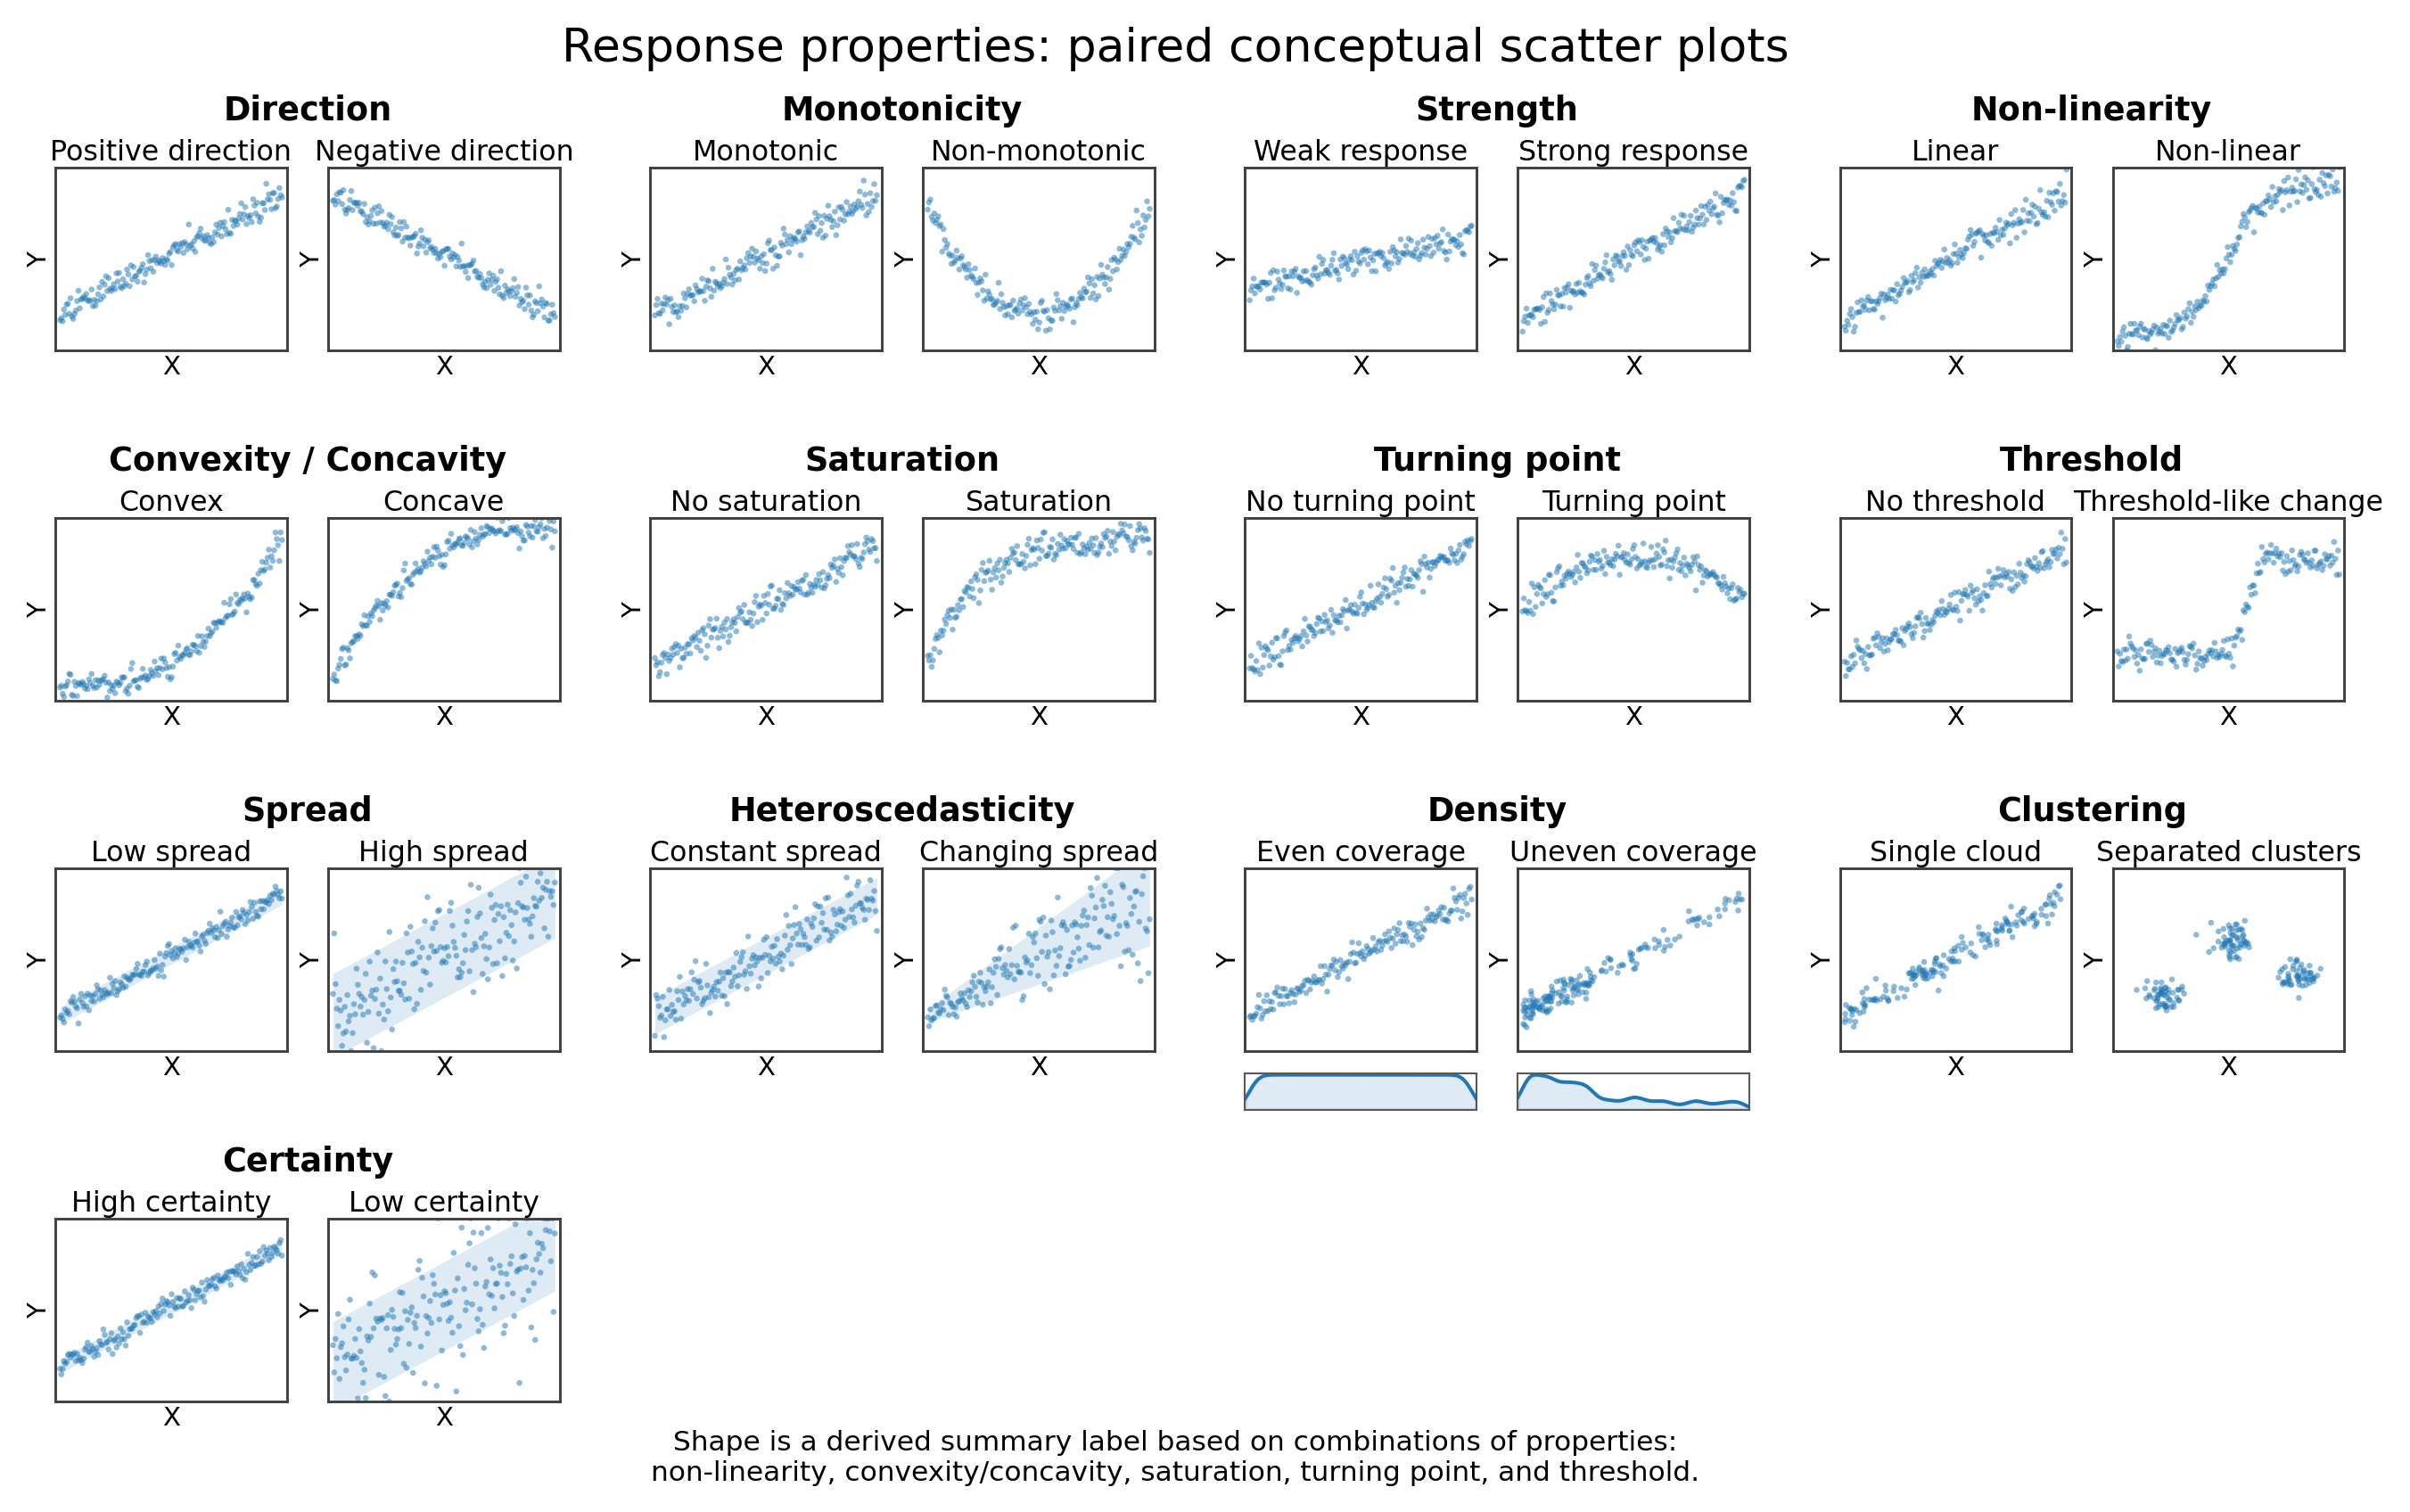

In [179]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# ==========================================================
# 0. Basic settings
# ==========================================================

np.random.seed(88)

x_base = np.linspace(0.02, 0.98, 170)

POINT_COLOR = "C0"
BUFFER_COLOR = "C0"

properties = [
    ("Direction", "Positive direction", "Negative direction"),
    ("Monotonicity", "Monotonic", "Non-monotonic"),
    ("Strength", "Weak response", "Strong response"),
    ("Non-linearity", "Linear", "Non-linear"),
    ("Convexity / Concavity", "Convex", "Concave"),
    ("Saturation", "No saturation", "Saturation"),
    ("Turning point", "No turning point", "Turning point"),
    ("Threshold", "No threshold", "Threshold-like change"),
    ("Spread", "Low spread", "High spread"),
    ("Heteroscedasticity", "Constant spread", "Changing spread"),
    ("Density", "Even coverage", "Uneven coverage"),
    ("Clustering", "Single cloud", "Separated clusters"),
    ("Certainty", "High certainty", "Low certainty"),
]

property_seed_map = {
    prop: 88 + i * 17
    for i, (prop, _, _) in enumerate(properties)
}


# ==========================================================
# 1. Controlled data generation
# ==========================================================

def _clip01(y):
    return np.clip(y, 0, 1)


def _linear_baseline(xx):
    return 0.18 + 0.68 * xx


def _add_noise(y, rng, noise_sd=0.04):
    return _clip01(y + rng.normal(0, noise_sd, len(y)))


def kde_manual(values, grid, bandwidth=0.035):
    values = np.asarray(values)
    grid = np.asarray(grid)

    dens = np.zeros_like(grid, dtype=float)

    for v in values:
        dens += np.exp(-0.5 * ((grid - v) / bandwidth) ** 2)

    dens /= max(len(values), 1)

    if dens.max() > 0:
        dens = dens / dens.max()

    return dens


def curve_data(prop):
    """
    Controlled paired conceptual datasets.

    General rule:
    - For most properties, left case is the same linear baseline.
    - Right case changes only the target property.
    - X distribution, sample size, and noise level are kept as similar as possible.
    """
    rng = np.random.default_rng(property_seed_map[prop])
    xx = x_base.copy()

    base_noise = 0.04
    y_linear = _linear_baseline(xx)

    if prop == "Direction":
        eps = rng.normal(0, base_noise, len(xx))

        y_pos = 0.18 + 0.68 * xx
        y_neg = 0.86 - 0.68 * xx

        return (
            (xx, _clip01(y_pos + eps)),
            (xx, _clip01(y_neg + eps)),
        )

    if prop == "Monotonicity":
        eps = rng.normal(0, base_noise, len(xx))

        y_mono = y_linear
        y_nonmono = 0.20 + 0.62 * ((xx - 0.50) ** 2) / 0.25

        return (
            (xx, _clip01(y_mono + eps)),
            (xx, _clip01(y_nonmono + eps)),
        )

    if prop == "Strength":
        eps = rng.normal(0, base_noise, len(xx))

        y_weak = 0.34 + 0.28 * xx
        y_strong = 0.16 + 0.72 * xx

        return (
            (xx, _clip01(y_weak + eps)),
            (xx, _clip01(y_strong + eps)),
        )

    if prop == "Non-linearity":
        eps = rng.normal(0, base_noise, len(xx))

        y_linear_case = 0.15 + 0.72 * xx
        y_nonlinear = 0.08 + 0.84 / (1 + np.exp(-11.0 * (xx - 0.50)))

        return (
            (xx, _clip01(y_linear_case + eps)),
            (xx, _clip01(y_nonlinear + eps)),
        )

    if prop == "Convexity / Concavity":
        eps = rng.normal(0, base_noise, len(xx))

        y_convex = 0.08 + 0.86 * (xx ** 2.8)
        y_concave = 0.08 + 0.86 * (1 - (1 - xx) ** 2.8)

        return (
            (xx, _clip01(y_convex + eps)),
            (xx, _clip01(y_concave + eps)),
        )

    if prop == "Saturation":
        eps = rng.normal(0, base_noise, len(xx))

        y_no_saturation = y_linear
        y_saturation = 0.14 + 0.76 * (1 - np.exp(-4.5 * xx))

        return (
            (xx, _clip01(y_no_saturation + eps)),
            (xx, _clip01(y_saturation + eps)),
        )

    if prop == "Turning point":
        eps = rng.normal(0, base_noise, len(xx))

        y_no_turning = y_linear
        y_turning = 0.78 - 1.10 * (xx - 0.52) ** 2

        return (
            (xx, _clip01(y_no_turning + eps)),
            (xx, _clip01(y_turning + eps)),
        )

    if prop == "Threshold":
        eps = rng.normal(0, base_noise, len(xx))

        y_no_threshold = y_linear

        threshold = 0.58
        y_threshold = 0.25 + 0.53 / (1 + np.exp(-45 * (xx - threshold)))

        return (
            (xx, _clip01(y_no_threshold + eps)),
            (xx, _clip01(y_threshold + eps)),
        )

    if prop == "Spread":
        y_mean = y_linear

        y_low_spread = _add_noise(y_mean, rng, noise_sd=0.035)
        y_high_spread = _add_noise(y_mean, rng, noise_sd=0.17)

        return (
            (xx, y_low_spread),
            (xx, y_high_spread),
        )

    if prop == "Heteroscedasticity":
        y_mean = y_linear

        y_constant = y_mean + rng.normal(0, 0.075, len(xx))
        y_changing = y_mean + rng.normal(0, 0.025 + 0.18 * xx, len(xx))

        return (
            (xx, _clip01(y_constant)),
            (xx, _clip01(y_changing)),
        )

    if prop == "Density":
        x_even = np.linspace(0.02, 0.98, 170)

        x_uneven = np.concatenate([
            rng.uniform(0.02, 0.34, 110),
            rng.uniform(0.34, 0.98, 60),
        ])
        x_uneven = np.sort(x_uneven)

        y_even = _linear_baseline(x_even)
        y_uneven = _linear_baseline(x_uneven)

        return (
            (x_even, _add_noise(y_even, rng, base_noise)),
            (x_uneven, _add_noise(y_uneven, rng, base_noise)),
        )

    if prop == "Clustering":
        x_single = rng.uniform(0.02, 0.98, 170)
        y_single = _linear_baseline(x_single) + rng.normal(0, base_noise, 170)

        n1, n2, n3 = 55, 60, 55

        x_c1 = rng.normal(0.22, 0.045, n1)
        y_c1 = rng.normal(0.30, 0.045, n1)

        x_c2 = rng.normal(0.52, 0.050, n2)
        y_c2 = rng.normal(0.60, 0.050, n2)

        x_c3 = rng.normal(0.80, 0.045, n3)
        y_c3 = rng.normal(0.40, 0.045, n3)

        x_cluster = np.clip(
            np.concatenate([x_c1, x_c2, x_c3]),
            0.02,
            0.98,
        )
        y_cluster = np.clip(
            np.concatenate([y_c1, y_c2, y_c3]),
            0.05,
            0.95,
        )

        return (
            (x_single, _clip01(y_single)),
            (x_cluster, y_cluster),
        )

    if prop == "Certainty":
        y_mean = y_linear

        y_high_certainty = _add_noise(y_mean, rng, noise_sd=0.030)
        y_low_certainty = _add_noise(y_mean, rng, noise_sd=0.18)

        return (
            (xx, y_high_certainty),
            (xx, y_low_certainty),
        )

    raise ValueError(f"Unknown property: {prop}")


# ==========================================================
# 2. Plotting helpers
# ==========================================================

def style_axis(ax):
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    ax.set_xticks([])
    ax.set_yticks([])

    for spine in ["top", "right", "bottom", "left"]:
        ax.spines[spine].set_visible(True)
        ax.spines[spine].set_linewidth(0.70)
        ax.spines[spine].set_color("0.25")

    ax.set_xlabel("X", fontsize=7, labelpad=1)
    ax.set_ylabel("Y", fontsize=7, labelpad=1)


def add_buffer(ax, xx, yy, buffer_width, alpha=0.14):
    xx = np.asarray(xx)
    yy = np.asarray(yy)

    order = np.argsort(xx)
    xx_o = xx[order]
    yy_o = yy[order]

    if np.isscalar(buffer_width):
        bw = np.full_like(xx_o, buffer_width, dtype=float)
    else:
        bw = np.asarray(buffer_width)[order]

    ax.fill_between(
        xx_o,
        yy_o - bw,
        yy_o + bw,
        color=BUFFER_COLOR,
        alpha=alpha,
        linewidth=0,
        zorder=1,
    )


def draw_density_inset(ax, xx):
    grid = np.linspace(0, 1, 300)
    dens = kde_manual(xx, grid, bandwidth=0.035)

    ax_den = inset_axes(
        ax,
        width="100%",
        height="20%",
        loc="lower left",
        bbox_to_anchor=(0, -0.32, 1, 1),
        bbox_transform=ax.transAxes,
        borderpad=0,
    )

    ax_den.plot(grid, dens, linewidth=0.95, color=POINT_COLOR)
    ax_den.fill_between(grid, 0, dens, color=BUFFER_COLOR, alpha=0.14)

    ax_den.set_xlim(0, 1)
    ax_den.set_ylim(0, 1.05)
    ax_den.set_xticks([])
    ax_den.set_yticks([])

    for spine in ["top", "right", "bottom", "left"]:
        ax_den.spines[spine].set_visible(True)
        ax_den.spines[spine].set_linewidth(0.50)
        ax_den.spines[spine].set_color("0.35")


def draw_panel(ax, xx, yy, title, prop, side):
    xx = np.asarray(xx)
    yy = np.asarray(yy)

    ax.scatter(
        xx,
        yy,
        s=2.5,
        alpha=0.5,
        color=POINT_COLOR,
        edgecolors="none",
        linewidths=0,
        zorder=2,
    )

    # Add buffer only for properties whose target is dispersion/uncertainty
    if prop == "Spread":
        if side == 0:
            add_buffer(ax, xx, _linear_baseline(xx), 0.035 * 1.35, alpha=0.14)
        else:
            add_buffer(ax, xx, _linear_baseline(xx), 0.17 * 1.35, alpha=0.14)

    elif prop == "Heteroscedasticity":
        if side == 0:
            noise_sd = np.full_like(xx, 0.075)
        else:
            noise_sd = 0.025 + 0.18 * xx

        add_buffer(ax, xx, _linear_baseline(xx), noise_sd * 1.35, alpha=0.14)

    elif prop == "Certainty":
        if side == 0:
            add_buffer(ax, xx, _linear_baseline(xx), 0.030 * 1.35, alpha=0.14)
        else:
            add_buffer(ax, xx, _linear_baseline(xx), 0.18 * 1.35, alpha=0.14)

    ax.set_title(title, fontsize=7.6, pad=2)
    style_axis(ax)


# ==========================================================
# 3. Combine 13 groups into one figure
# ==========================================================

n_cols = 4
n_rows = int(np.ceil(len(properties) / n_cols))

fig = plt.figure(figsize=(9.2, 5.5), dpi=300)

outer = GridSpec(
    n_rows,
    n_cols,
    figure=fig,
    hspace=0.32,
    wspace=0.18,
)

for idx, (prop, left_title, right_title) in enumerate(properties):
    row = idx // n_cols
    col = idx % n_cols

    cell = GridSpecFromSubplotSpec(
        2,
        2,
        subplot_spec=outer[row, col],
        height_ratios=[0.20, 0.80],
        hspace=0.32,
        wspace=0.18,
    )

    title_ax = fig.add_subplot(cell[0, :])
    title_ax.axis("off")

    title_ax.text(
        0.5,
        0.45,
        prop,
        ha="center",
        va="center",
        fontsize=8.8,
        fontweight="bold",
    )

    (xl, yl), (xr, yr) = curve_data(prop)

    ax_l = fig.add_subplot(cell[1, 0])
    ax_r = fig.add_subplot(cell[1, 1])

    draw_panel(ax_l, xl, yl, left_title, prop, 0)
    draw_panel(ax_r, xr, yr, right_title, prop, 1)

    if prop == "Density":
        ax_l.set_xlabel("")
        ax_r.set_xlabel("")
        draw_density_inset(ax_l, xl)
        draw_density_inset(ax_r, xr)

# Empty cell for the 14th position
if len(properties) % n_cols != 0:
    empty_ax = fig.add_subplot(outer[-1, -1])
    empty_ax.axis("off")

fig.suptitle(
    "Response properties: paired conceptual scatter plots",
    fontsize=12.5,
    y=0.995,
)

shape_note = (
    "Shape is a derived summary label based on combinations of properties:\n"
    "non-linearity, convexity/concavity, saturation, turning point, and threshold."
)

fig.text(
    0.5,
    0.022,
    shape_note,
    ha="center",
    va="center",
    fontsize=7.5,
)

plt.subplots_adjust(
    left=0.045,
    right=0.975,
    top=0.955,
    bottom=0.06,
)

os.makedirs("./output", exist_ok=True)

# plt.savefig(
#     "./output/controlled_response_properties_pairs.png",
#     dpi=300,
#     bbox_inches="tight",
# )

# plt.savefig(
#     "./output/controlled_response_properties_pairs.pdf",
#     bbox_inches="tight",
# )

plt.show()

In [181]:
# import os
# import numpy as np
# import pandas as pd

# from scipy.stats import pearsonr, spearmanr, ks_2samp, wasserstein_distance
# from scipy.spatial.distance import pdist, squareform
# from statsmodels.nonparametric.smoothers_lowess import lowess


# # ==========================================================
# # 0. Simulated conceptual datasets
# # ==========================================================

# np.random.seed(88)

# x_base = np.linspace(0.02, 0.98, 170)

# properties = [
#     ("Direction", "Positive direction", "Negative direction"),
#     ("Monotonicity", "Monotonic", "Non-monotonic"),
#     ("Strength", "Weak response", "Strong response"),
#     ("Non-linearity", "Linear", "Non-linear"),
#     ("Convexity / Concavity", "Convex", "Concave"),
#     ("Saturation", "No saturation", "Saturation"),
#     ("Turning point", "No turning point", "Turning point"),
#     ("Threshold", "No threshold", "Threshold-like change"),
#     ("Spread", "Low spread", "High spread"),
#     ("Heteroscedasticity", "Constant spread", "Changing spread"),
#     ("Density", "Even coverage", "Uneven coverage"),
#     ("Clustering", "Single cloud", "Separated clusters"),
#     ("Certainty", "High certainty", "Low certainty"),
# ]

# property_seed_map = {
#     prop: 88 + i * 17
#     for i, (prop, _, _) in enumerate(properties)
# }


# def _clip01(y):
#     return np.clip(y, 0, 1)


# def _linear_baseline(xx):
#     return 0.18 + 0.68 * xx


# def _add_noise(y, rng, noise_sd=0.04):
#     return _clip01(y + rng.normal(0, noise_sd, len(y)))


# def curve_data(prop):
#     """
#     Controlled paired conceptual datasets.

#     General rule:
#     - For most properties, use the same X and similar noise.
#     - The left case is usually a linear baseline.
#     - The right case changes only the target response property.
#     """
#     rng = np.random.default_rng(property_seed_map[prop])
#     xx = x_base.copy()

#     base_noise = 0.04
#     y_linear = _linear_baseline(xx)

#     if prop == "Direction":
#         # Same strength and noise; only direction changes.
#         eps = rng.normal(0, base_noise, len(xx))

#         y_pos = 0.18 + 0.68 * xx
#         y_neg = 0.86 - 0.68 * xx

#         return (
#             (xx, _clip01(y_pos + eps)),
#             (xx, _clip01(y_neg + eps)),
#         )

#     if prop == "Monotonicity":
#         # Same X and noise; only monotonic vs non-monotonic structure changes.
#         eps = rng.normal(0, base_noise, len(xx))

#         y_mono = y_linear
#         y_nonmono = 0.20 + 0.62 * ((xx - 0.50) ** 2) / 0.25

#         return (
#             (xx, _clip01(y_mono + eps)),
#             (xx, _clip01(y_nonmono + eps)),
#         )

#     if prop == "Strength":
#         # Same X, same noise, same linear form; only slope/amplitude changes.
#         eps = rng.normal(0, base_noise, len(xx))

#         y_weak = 0.34 + 0.28 * xx
#         y_strong = 0.16 + 0.72 * xx

#         return (
#             (xx, _clip01(y_weak + eps)),
#             (xx, _clip01(y_strong + eps)),
#         )

#     if prop == "Non-linearity":
#         # Same X and noise; only linear vs nonlinear form changes.
#         eps = rng.normal(0, base_noise, len(xx))

#         y_linear = 0.15 + 0.72 * xx
#         y_nonlinear = 0.08 + 0.84 / (1 + np.exp(-11.0 * (xx - 0.50)))

#         return (
#             (xx, _clip01(y_linear + eps)),
#             (xx, _clip01(y_nonlinear + eps)),
#         )

#     if prop == "Convexity / Concavity":
#         # Same X and noise; only curvature direction changes.
#         eps = rng.normal(0, base_noise, len(xx))

#         y_convex = 0.08 + 0.86 * (xx ** 2.8)
#         y_concave = 0.08 + 0.86 * (1 - (1 - xx) ** 2.8)

#         return (
#             (xx, _clip01(y_convex + eps)),
#             (xx, _clip01(y_concave + eps)),
#         )

#     if prop == "Saturation":
#         # Left is linear baseline; right only adds saturation.
#         eps = rng.normal(0, base_noise, len(xx))

#         y_no_saturation = y_linear
#         y_saturation = 0.14 + 0.76 * (1 - np.exp(-4.5 * xx))

#         return (
#             (xx, _clip01(y_no_saturation + eps)),
#             (xx, _clip01(y_saturation + eps)),
#         )

#     if prop == "Turning point":
#         # Left is linear baseline; right only introduces a turning point.
#         eps = rng.normal(0, base_noise, len(xx))

#         y_no_turning = y_linear
#         y_turning = 0.78 - 1.10 * (xx - 0.52) ** 2

#         return (
#             (xx, _clip01(y_no_turning + eps)),
#             (xx, _clip01(y_turning + eps)),
#         )

#     if prop == "Threshold":
#         # Left is linear baseline; right introduces a regime-shift threshold.
#         eps = rng.normal(0, base_noise, len(xx))

#         y_no_threshold = y_linear

#         threshold = 0.58
#         y_threshold = 0.25 + 0.53 / (1 + np.exp(-45 * (xx - threshold)))

#         return (
#             (xx, _clip01(y_no_threshold + eps)),
#             (xx, _clip01(y_threshold + eps)),
#         )

#     if prop == "Spread":
#         # Same X and same mean response; only overall spread changes.
#         y_mean = y_linear

#         y_low_spread = _add_noise(y_mean, rng, noise_sd=0.035)
#         y_high_spread = _add_noise(y_mean, rng, noise_sd=0.17)

#         return (
#             (xx, y_low_spread),
#             (xx, y_high_spread),
#         )

#     if prop == "Heteroscedasticity":
#         # Same X and same mean response; only spread pattern changes across X.
#         y_mean = y_linear

#         y_constant = y_mean + rng.normal(0, 0.075, len(xx))
#         y_changing = y_mean + rng.normal(0, 0.025 + 0.18 * xx, len(xx))

#         return (
#             (xx, _clip01(y_constant)),
#             (xx, _clip01(y_changing)),
#         )

#     if prop == "Density":
#         # Same response function and similar noise; only X sampling density changes.
#         x_even = np.linspace(0.02, 0.98, 170)

#         x_uneven = np.concatenate([
#             rng.uniform(0.02, 0.34, 110),
#             rng.uniform(0.34, 0.98, 60),
#         ])
#         x_uneven = np.sort(x_uneven)

#         y_even = _linear_baseline(x_even)
#         y_uneven = _linear_baseline(x_uneven)

#         return (
#             (x_even, _add_noise(y_even, rng, base_noise)),
#             (x_uneven, _add_noise(y_uneven, rng, base_noise)),
#         )

#     if prop == "Clustering":
#         # Clustering necessarily changes spatial arrangement.
#         # Keep sample size and global range similar.
#         x_single = rng.uniform(0.02, 0.98, 170)
#         y_single = _linear_baseline(x_single) + rng.normal(0, base_noise, 170)

#         n1, n2, n3 = 55, 60, 55

#         x_c1 = rng.normal(0.22, 0.045, n1)
#         y_c1 = rng.normal(0.30, 0.045, n1)

#         x_c2 = rng.normal(0.52, 0.050, n2)
#         y_c2 = rng.normal(0.60, 0.050, n2)

#         x_c3 = rng.normal(0.80, 0.045, n3)
#         y_c3 = rng.normal(0.40, 0.045, n3)

#         x_cluster = np.clip(
#             np.concatenate([x_c1, x_c2, x_c3]),
#             0.02,
#             0.98,
#         )
#         y_cluster = np.clip(
#             np.concatenate([y_c1, y_c2, y_c3]),
#             0.05,
#             0.95,
#         )

#         return (
#             (x_single, _clip01(y_single)),
#             (x_cluster, y_cluster),
#         )

#     if prop == "Certainty":
#         # Same X and same mean response; only noise/uncertainty level changes.
#         y_mean = y_linear

#         y_high_certainty = _add_noise(y_mean, rng, noise_sd=0.030)
#         y_low_certainty = _add_noise(y_mean, rng, noise_sd=0.18)

#         return (
#             (xx, y_high_certainty),
#             (xx, y_low_certainty),
#         )

#     raise ValueError(f"Unknown property: {prop}")


# # ==========================================================
# # 1. Basic helper functions
# # ==========================================================

# def _to_valid_arrays(x, y):
#     x = np.asarray(x, dtype=float).ravel()
#     y = np.asarray(y, dtype=float).ravel()

#     valid = np.isfinite(x) & np.isfinite(y)
#     return x[valid], y[valid]


# def _safe_divide(a, b):
#     if b == 0 or not np.isfinite(b):
#         return np.nan
#     return a / b


# def _minmax_norm(v):
#     v = np.asarray(v, dtype=float)

#     v_min = np.nanmin(v)
#     v_max = np.nanmax(v)

#     if not np.isfinite(v_min) or not np.isfinite(v_max) or v_max == v_min:
#         return np.full_like(v, np.nan, dtype=float)

#     return (v - v_min) / (v_max - v_min)


# def _endpoint_slope(x, y):
#     if len(x) < 2:
#         return np.nan

#     return _safe_divide(y[-1] - y[0], x[-1] - x[0])


# def _segment_masks_by_order(n):
#     i1 = n // 3
#     i2 = 2 * n // 3

#     early = np.zeros(n, dtype=bool)
#     middle = np.zeros(n, dtype=bool)
#     late = np.zeros(n, dtype=bool)

#     early[:i1] = True
#     middle[i1:i2] = True
#     late[i2:] = True

#     return early, middle, late


# def _residual_sd(y, y_hat):
#     residuals = y - y_hat

#     if len(residuals) < 2:
#         return np.nan

#     return np.nanstd(residuals, ddof=1)


# def _r2_score(y, y_hat):
#     ss_res = np.nansum((y - y_hat) ** 2)
#     ss_tot = np.nansum((y - np.nanmean(y)) ** 2)

#     if ss_tot == 0:
#         return np.nan

#     return 1 - ss_res / ss_tot


# def _count_derivative_sign_changes(x_curve, y_curve, slope_tol=1e-6):
#     x_curve = np.asarray(x_curve, dtype=float)
#     y_curve = np.asarray(y_curve, dtype=float)

#     valid = np.isfinite(x_curve) & np.isfinite(y_curve)
#     x_curve = x_curve[valid]
#     y_curve = y_curve[valid]

#     if len(x_curve) < 4:
#         return np.nan

#     order = np.argsort(x_curve)
#     x_curve = x_curve[order]
#     y_curve = y_curve[order]

#     dx = np.diff(x_curve)
#     dy = np.diff(y_curve)

#     valid_diff = dx != 0

#     if valid_diff.sum() < 3:
#         return np.nan

#     slopes = dy[valid_diff] / dx[valid_diff]

#     signs = np.zeros_like(slopes, dtype=int)
#     signs[slopes > slope_tol] = 1
#     signs[slopes < -slope_tol] = -1

#     nonzero_signs = signs[signs != 0]

#     if len(nonzero_signs) < 2:
#         return 0

#     return int(np.sum(nonzero_signs[1:] != nonzero_signs[:-1]))


# # ==========================================================
# # 2. X coverage / density metrics
# # ==========================================================

# def compute_x_coverage_metrics(x, n_bins=10):
#     x = np.asarray(x, dtype=float).ravel()
#     x = x[np.isfinite(x)]

#     result = {
#         "x_uniform_ks_distance": np.nan,
#         "equal_width_bin_x_bin_count_cv": np.nan,
#     }

#     if len(x) < 3:
#         return result

#     x_min = np.nanmin(x)
#     x_max = np.nanmax(x)

#     if x_max > x_min:
#         x_norm = (x - x_min) / (x_max - x_min)
#         x_sorted = np.sort(x_norm)
#         n = len(x_sorted)

#         d_plus = np.max(np.arange(1, n + 1) / n - x_sorted)
#         d_minus = np.max(x_sorted - np.arange(0, n) / n)

#         result["x_uniform_ks_distance"] = max(d_plus, d_minus)

#     if len(x) >= n_bins:
#         counts, _ = np.histogram(x, bins=n_bins)

#         mean_count = np.mean(counts)
#         sd_count = np.std(counts, ddof=1)

#         if mean_count > 0:
#             result["equal_width_bin_x_bin_count_cv"] = sd_count / mean_count

#     return result


# # ==========================================================
# # 3. Correlation-based metrics
# # ==========================================================

# def compute_correlation_metrics(x, y):
#     x, y = _to_valid_arrays(x, y)

#     result = {
#         "pearson_r": np.nan,
#         "spearman_rho": np.nan,
#         "covariance": np.nan,
#     }

#     if len(x) < 3:
#         return result

#     if np.nanstd(x) == 0 or np.nanstd(y) == 0:
#         return result

#     result["pearson_r"] = pearsonr(x, y)[0]
#     result["spearman_rho"] = spearmanr(x, y)[0]
#     result["covariance"] = np.cov(x, y, ddof=1)[0, 1]

#     return result


# # ==========================================================
# # 4. Distance-based metrics
# # ==========================================================

# def _double_center_distance_matrix(a):
#     a = np.asarray(a, dtype=float).reshape(-1, 1)

#     dist = squareform(pdist(a, metric="euclidean"))

#     row_mean = dist.mean(axis=1, keepdims=True)
#     col_mean = dist.mean(axis=0, keepdims=True)
#     grand_mean = dist.mean()

#     return dist - row_mean - col_mean + grand_mean


# def compute_distance_metrics(x, y):
#     x, y = _to_valid_arrays(x, y)

#     result = {
#         "distance_covariance": np.nan,
#         "distance_correlation": np.nan,
#     }

#     if len(x) < 3:
#         return result

#     if np.nanstd(x) == 0 or np.nanstd(y) == 0:
#         return result

#     A = _double_center_distance_matrix(x)
#     B = _double_center_distance_matrix(y)

#     dcov2_xy = np.mean(A * B)
#     dcov2_xx = np.mean(A * A)
#     dcov2_yy = np.mean(B * B)

#     dcov_xy = np.sqrt(max(dcov2_xy, 0))
#     dcov_xx = np.sqrt(max(dcov2_xx, 0))
#     dcov_yy = np.sqrt(max(dcov2_yy, 0))

#     result["distance_covariance"] = dcov_xy
#     result["distance_correlation"] = _safe_divide(
#         dcov_xy,
#         np.sqrt(dcov_xx * dcov_yy),
#     )

#     return result


# # ==========================================================
# # 5. Distribution-based metrics
# # ==========================================================

# def _make_bins(x, n_bins=10, bin_type="equal_width"):
#     x = np.asarray(x, dtype=float)

#     if bin_type == "equal_width":
#         bins = pd.cut(
#             x,
#             bins=n_bins,
#             labels=False,
#             include_lowest=True,
#             duplicates="drop",
#         )

#     elif bin_type == "equal_count":
#         bins = pd.qcut(
#             x,
#             q=n_bins,
#             labels=False,
#             duplicates="drop",
#         )

#     else:
#         raise ValueError("bin_type must be 'equal_width' or 'equal_count'.")

#     return np.asarray(bins, dtype=float)


# def compute_distribution_metrics(x, y, n_bins=10, bin_type="equal_width"):
#     x, y = _to_valid_arrays(x, y)

#     prefix = f"{bin_type}_distribution"

#     result = {
#         f"{prefix}_ks_distance": np.nan,
#         f"{prefix}_wasserstein_distance": np.nan,
#     }

#     if len(x) < n_bins:
#         return result

#     bins = _make_bins(x, n_bins=n_bins, bin_type=bin_type)

#     df = pd.DataFrame({
#         "x": x,
#         "y": y,
#         "bin": bins,
#     }).dropna()

#     if df.empty:
#         return result

#     valid_bins = np.sort(df["bin"].unique())

#     if len(valid_bins) < 3:
#         return result

#     n_valid_bins = len(valid_bins)
#     i1 = n_valid_bins // 3
#     i2 = 2 * n_valid_bins // 3

#     low_bins = valid_bins[:i1]
#     high_bins = valid_bins[i2:]

#     y_low = df[df["bin"].isin(low_bins)]["y"].values
#     y_high = df[df["bin"].isin(high_bins)]["y"].values

#     if len(y_low) < 2 or len(y_high) < 2:
#         return result

#     result[f"{prefix}_ks_distance"] = ks_2samp(y_low, y_high).statistic
#     result[f"{prefix}_wasserstein_distance"] = wasserstein_distance(y_low, y_high)

#     return result


# # ==========================================================
# # 6. Slope-based metrics
# # ==========================================================

# def compute_slope_metrics(x, y, prefix="raw"):
#     x, y = _to_valid_arrays(x, y)

#     result = {
#         f"{prefix}_overall_slope": np.nan,
#         f"{prefix}_early_slope": np.nan,
#         f"{prefix}_middle_slope": np.nan,
#         f"{prefix}_late_slope": np.nan,
#         f"{prefix}_segment_strength": np.nan,
#     }

#     if len(x) < 6:
#         return result

#     order = np.argsort(x)
#     x_sorted = x[order]
#     y_sorted = y[order]

#     result[f"{prefix}_overall_slope"] = _endpoint_slope(x_sorted, y_sorted)

#     early_mask, middle_mask, late_mask = _segment_masks_by_order(len(x_sorted))

#     segment_slopes = {}

#     for name, mask in zip(
#         ["early", "middle", "late"],
#         [early_mask, middle_mask, late_mask],
#     ):
#         xs = x_sorted[mask]
#         ys = y_sorted[mask]

#         segment_slopes[name] = _endpoint_slope(xs, ys)
#         result[f"{prefix}_{name}_slope"] = segment_slopes[name]

#     result[f"{prefix}_segment_strength"] = np.nanmean([
#         abs(segment_slopes["early"]),
#         abs(segment_slopes["middle"]),
#         abs(segment_slopes["late"]),
#     ])

#     return result


# def compute_standardized_slope_metrics(x, y):
#     x, y = _to_valid_arrays(x, y)

#     x_norm = _minmax_norm(x)
#     y_norm = _minmax_norm(y)

#     return compute_slope_metrics(
#         x_norm,
#         y_norm,
#         prefix="standardized",
#     )


# # ==========================================================
# # 7. Information-based metrics
# # ==========================================================

# def compute_information_metrics(x, y):
#     x, y = _to_valid_arrays(x, y)

#     result = {
#         "MIC": np.nan,
#         "MAS": np.nan,
#         "MEV": np.nan,
#         "MCN": np.nan,
#         "MIC_minus_r2": np.nan,
#     }

#     if len(x) < 5:
#         return result

#     try:
#         from minepy import MINE

#         mine = MINE(alpha=0.6, c=15)
#         mine.compute_score(x, y)

#         mic = mine.mic()
#         mas = mine.mas()
#         mev = mine.mev()
#         mcn = mine.mcn()

#         r = pearsonr(x, y)[0] if np.nanstd(x) > 0 and np.nanstd(y) > 0 else np.nan

#         result["MIC"] = mic
#         result["MAS"] = mas
#         result["MEV"] = mev
#         result["MCN"] = mcn
#         result["MIC_minus_r2"] = mic - r ** 2 if np.isfinite(r) else np.nan

#     except Exception:
#         pass

#     return result


# # ==========================================================
# # 8. Bin-based metrics
# # ==========================================================

# def compute_bin_metrics(
#     x,
#     y,
#     n_bins=10,
#     bin_type="equal_width",
#     buffer_method="q95_q05",
#     min_count_per_bin=5,
# ):
#     x, y = _to_valid_arrays(x, y)

#     prefix = f"{bin_type}_bin"

#     result = {
#         f"{prefix}_amplitude": np.nan,
#         f"{prefix}_eta_squared": np.nan,
#         f"{prefix}_buffer_width_mean": np.nan,
#         f"{prefix}_early_buffer_width": np.nan,
#         f"{prefix}_middle_buffer_width": np.nan,
#         f"{prefix}_late_buffer_width": np.nan,
#         f"{prefix}_n_valid_bins": 0,
#     }

#     if len(x) < n_bins:
#         return result

#     bins = _make_bins(x, n_bins=n_bins, bin_type=bin_type)

#     df = pd.DataFrame({
#         "x": x,
#         "y": y,
#         "bin": bins,
#     }).dropna()

#     if df.empty:
#         return result

#     bin_stats = []

#     for bin_id, g in df.groupby("bin", observed=True):
#         if len(g) < min_count_per_bin:
#             continue

#         y_values = g["y"].values

#         if buffer_method == "q95_q05":
#             bw = np.nanpercentile(y_values, 95) - np.nanpercentile(y_values, 5)
#         elif buffer_method == "q75_q25":
#             bw = np.nanpercentile(y_values, 75) - np.nanpercentile(y_values, 25)
#         elif buffer_method == "sd":
#             bw = np.nanstd(y_values, ddof=1)
#         else:
#             raise ValueError("Unknown buffer_method.")

#         bin_stats.append({
#             "bin": bin_id,
#             "x_mean": np.nanmean(g["x"]),
#             "y_mean": np.nanmean(g["y"]),
#             "buffer_width": bw,
#             "count": len(g),
#         })

#     if len(bin_stats) < 2:
#         return result

#     bin_df = pd.DataFrame(bin_stats).sort_values("x_mean").reset_index(drop=True)

#     result[f"{prefix}_amplitude"] = (
#         np.nanmax(bin_df["y_mean"]) - np.nanmin(bin_df["y_mean"])
#     )

#     y_all = df["y"].values
#     y_global_mean = np.nanmean(y_all)

#     ss_total = np.nansum((y_all - y_global_mean) ** 2)

#     ss_between = 0.0
#     for _, row in bin_df.iterrows():
#         g = df[df["bin"] == row["bin"]]
#         ss_between += len(g) * (row["y_mean"] - y_global_mean) ** 2

#     result[f"{prefix}_eta_squared"] = _safe_divide(ss_between, ss_total)

#     result[f"{prefix}_buffer_width_mean"] = np.nanmean(bin_df["buffer_width"])
#     result[f"{prefix}_n_valid_bins"] = len(bin_df)

#     n_valid_bins = len(bin_df)
#     i1 = n_valid_bins // 3
#     i2 = 2 * n_valid_bins // 3

#     result[f"{prefix}_early_buffer_width"] = np.nanmean(
#         bin_df.iloc[:i1]["buffer_width"]
#     )
#     result[f"{prefix}_middle_buffer_width"] = np.nanmean(
#         bin_df.iloc[i1:i2]["buffer_width"]
#     )
#     result[f"{prefix}_late_buffer_width"] = np.nanmean(
#         bin_df.iloc[i2:]["buffer_width"]
#     )

#     return result


# # ==========================================================
# # 9. Curve-based metrics: LOWESS
# # ==========================================================

# def fit_lowess_curve(x, y, frac=0.25):
#     x, y = _to_valid_arrays(x, y)

#     if len(x) < 5:
#         return None, None

#     order = np.argsort(x)
#     x_sorted = x[order]
#     y_sorted = y[order]

#     fitted = lowess(
#         endog=y_sorted,
#         exog=x_sorted,
#         frac=frac,
#         return_sorted=True,
#     )

#     return fitted[:, 0], fitted[:, 1]


# def compute_curve_metrics_from_fit(
#     x,
#     y,
#     x_curve,
#     y_curve,
#     prefix,
#     derivative_slope_tol=1e-6,
# ):
#     x, y = _to_valid_arrays(x, y)

#     result = {
#         f"{prefix}_residual_sd": np.nan,
#         f"{prefix}_curve_amplitude": np.nan,
#         f"{prefix}_r2": np.nan,
#         f"{prefix}_first_derivative_sign_changes": np.nan,
#     }

#     if x_curve is None or y_curve is None:
#         return result

#     x_curve = np.asarray(x_curve, dtype=float)
#     y_curve = np.asarray(y_curve, dtype=float)

#     valid_curve = np.isfinite(x_curve) & np.isfinite(y_curve)
#     x_curve = x_curve[valid_curve]
#     y_curve = y_curve[valid_curve]

#     if len(x_curve) < 2:
#         return result

#     order = np.argsort(x_curve)
#     x_curve = x_curve[order]
#     y_curve = y_curve[order]

#     y_hat = np.interp(x, x_curve, y_curve)

#     result[f"{prefix}_residual_sd"] = _residual_sd(y, y_hat)
#     result[f"{prefix}_curve_amplitude"] = np.nanmax(y_curve) - np.nanmin(y_curve)
#     result[f"{prefix}_r2"] = _r2_score(y, y_hat)

#     result[f"{prefix}_first_derivative_sign_changes"] = (
#         _count_derivative_sign_changes(
#             x_curve,
#             y_curve,
#             slope_tol=derivative_slope_tol,
#         )
#     )

#     return result


# def compute_lowess_metrics(x, y, frac=0.25):
#     x_curve, y_curve = fit_lowess_curve(x, y, frac=frac)

#     return compute_curve_metrics_from_fit(
#         x,
#         y,
#         x_curve,
#         y_curve,
#         prefix="lowess",
#     )


# # ==========================================================
# # 10. Curve-based metrics: GAM
# # ==========================================================

# def fit_gam_curve(x, y, n_splines=10, lam=0.6, grid_size=200):
#     x, y = _to_valid_arrays(x, y)

#     if len(x) < 10:
#         return None, None

#     try:
#         from pygam import LinearGAM, s

#         X = x.reshape(-1, 1)

#         gam = LinearGAM(
#             s(0, n_splines=n_splines),
#             lam=lam,
#         ).fit(X, y)

#         x_curve = np.linspace(np.nanmin(x), np.nanmax(x), grid_size)
#         y_curve = gam.predict(x_curve.reshape(-1, 1))

#         return x_curve, y_curve

#     except Exception:
#         return None, None


# def compute_gam_metrics(
#     x,
#     y,
#     n_splines=10,
#     lam=0.6,
#     grid_size=200,
# ):
#     x_curve, y_curve = fit_gam_curve(
#         x,
#         y,
#         n_splines=n_splines,
#         lam=lam,
#         grid_size=grid_size,
#     )

#     return compute_curve_metrics_from_fit(
#         x,
#         y,
#         x_curve,
#         y_curve,
#         prefix="gam",
#     )


# # ==========================================================
# # 11. Main wrapper
# # ==========================================================

# def compute_all_response_metrics(
#     x,
#     y,
#     n_bins=10,
#     min_count_per_bin=5,
#     lowess_frac=0.25,
#     gam_n_splines=10,
#     gam_lam=0.6,
# ):
#     x, y = _to_valid_arrays(x, y)

#     results = {}

#     results.update(compute_correlation_metrics(x, y))
#     results.update(compute_distance_metrics(x, y))

#     results.update(
#         compute_x_coverage_metrics(
#             x,
#             n_bins=n_bins,
#         )
#     )

#     results.update(
#         compute_distribution_metrics(
#             x,
#             y,
#             n_bins=n_bins,
#             bin_type="equal_width",
#         )
#     )

#     results.update(
#         compute_distribution_metrics(
#             x,
#             y,
#             n_bins=n_bins,
#             bin_type="equal_count",
#         )
#     )

#     results.update(compute_slope_metrics(x, y, prefix="raw"))
#     results.update(compute_standardized_slope_metrics(x, y))

#     results.update(compute_information_metrics(x, y))

#     results.update(
#         compute_bin_metrics(
#             x,
#             y,
#             n_bins=n_bins,
#             bin_type="equal_width",
#             min_count_per_bin=min_count_per_bin,
#         )
#     )

#     results.update(
#         compute_bin_metrics(
#             x,
#             y,
#             n_bins=n_bins,
#             bin_type="equal_count",
#             min_count_per_bin=min_count_per_bin,
#         )
#     )

#     results.update(
#         compute_lowess_metrics(
#             x,
#             y,
#             frac=lowess_frac,
#         )
#     )

#     results.update(
#         compute_gam_metrics(
#             x,
#             y,
#             n_splines=gam_n_splines,
#             lam=gam_lam,
#         )
#     )

#     results["n_valid"] = len(x)

#     return results


# # ==========================================================
# # 12. Compute metrics for all simulated property cases
# # ==========================================================

# all_property_metrics = []

# for prop, left_title, right_title in properties:
#     (xl, yl), (xr, yr) = curve_data(prop)

#     left_metrics = compute_all_response_metrics(
#         xl,
#         yl,
#         n_bins=10,
#         min_count_per_bin=5,
#         lowess_frac=0.25,
#         gam_n_splines=10,
#         gam_lam=0.6,
#     )

#     left_metrics["property"] = prop
#     left_metrics["case"] = left_title
#     left_metrics["side"] = "left"

#     right_metrics = compute_all_response_metrics(
#         xr,
#         yr,
#         n_bins=10,
#         min_count_per_bin=5,
#         lowess_frac=0.25,
#         gam_n_splines=10,
#         gam_lam=0.6,
#     )

#     right_metrics["property"] = prop
#     right_metrics["case"] = right_title
#     right_metrics["side"] = "right"

#     all_property_metrics.append(left_metrics)
#     all_property_metrics.append(right_metrics)


# property_metrics_df = pd.DataFrame(all_property_metrics)

# id_cols = ["property", "case", "side"]
# metric_cols = [c for c in property_metrics_df.columns if c not in id_cols]

# property_metrics_df = property_metrics_df[id_cols + metric_cols]


# # ==========================================================
# # 13. Round results and export to Excel
# # ==========================================================

# property_metrics_df_rounded = property_metrics_df.copy()

# numeric_cols = property_metrics_df_rounded.select_dtypes(include=[np.number]).columns
# property_metrics_df_rounded[numeric_cols] = (
#     property_metrics_df_rounded[numeric_cols].round(4)
# )

# selected_cols = [
#     "property",
#     "case",
#     "side",

#     "pearson_r",
#     "spearman_rho",
#     "covariance",

#     "distance_covariance",
#     "distance_correlation",

#     "x_uniform_ks_distance",
#     "equal_width_bin_x_bin_count_cv",

#     "equal_width_distribution_ks_distance",
#     "equal_width_distribution_wasserstein_distance",
#     "equal_count_distribution_ks_distance",
#     "equal_count_distribution_wasserstein_distance",

#     "raw_overall_slope",
#     "raw_early_slope",
#     "raw_middle_slope",
#     "raw_late_slope",
#     "raw_segment_strength",

#     "standardized_overall_slope",
#     "standardized_early_slope",
#     "standardized_middle_slope",
#     "standardized_late_slope",
#     "standardized_segment_strength",

#     "MIC",
#     "MAS",
#     "MEV",
#     "MCN",
#     "MIC_minus_r2",

#     "equal_width_bin_amplitude",
#     "equal_width_bin_eta_squared",
#     "equal_width_bin_buffer_width_mean",
#     "equal_width_bin_early_buffer_width",
#     "equal_width_bin_middle_buffer_width",
#     "equal_width_bin_late_buffer_width",
#     "equal_width_bin_n_valid_bins",

#     "equal_count_bin_amplitude",
#     "equal_count_bin_eta_squared",
#     "equal_count_bin_buffer_width_mean",
#     "equal_count_bin_early_buffer_width",
#     "equal_count_bin_middle_buffer_width",
#     "equal_count_bin_late_buffer_width",
#     "equal_count_bin_n_valid_bins",

#     "lowess_residual_sd",
#     "lowess_curve_amplitude",
#     "lowess_r2",
#     "lowess_first_derivative_sign_changes",

#     "gam_residual_sd",
#     "gam_curve_amplitude",
#     "gam_r2",
#     "gam_first_derivative_sign_changes",

#     "n_valid",
# ]

# selected_cols_existing = [
#     c for c in selected_cols
#     if c in property_metrics_df_rounded.columns
# ]

# os.makedirs("./output", exist_ok=True)

# output_excel = "./output/conceptual_response_property_metrics_controlled_9.xlsx"

# with pd.ExcelWriter(output_excel, engine="openpyxl") as writer:
#     property_metrics_df_rounded.to_excel(
#         writer,
#         sheet_name="all_metrics",
#         index=False,
#     )

#     property_metrics_df_rounded[selected_cols_existing].to_excel(
#         writer,
#         sheet_name="selected_metrics",
#         index=False,
#     )

# print(f"Excel file saved to: {output_excel}")

# property_metrics_df_rounded

In [182]:
# import os
# import numpy as np
# import pandas as pd

# from scipy.stats import pearsonr, spearmanr, ks_2samp, wasserstein_distance
# from scipy.spatial.distance import pdist, squareform
# from statsmodels.nonparametric.smoothers_lowess import lowess


# # ==========================================================
# # 0. Simulated conceptual datasets
# # ==========================================================

# np.random.seed(88)
# rng = np.random.default_rng(88)

# x_base = np.linspace(0, 1, 170)

# properties = [
#     ("Direction", "Positive direction", "Negative direction"),
#     ("Monotonicity", "Monotonic", "Non-monotonic"),
#     ("Strength", "Weak response", "Strong response"),
#     ("Non-linearity", "Linear", "Non-linear"),
#     ("Convexity / Concavity", "Convex", "Concave"),
#     ("Saturation", "No saturation", "Saturation"),
#     ("Turning point", "No turning point", "Turning point"),
#     ("Threshold", "No threshold", "Threshold-like change"),
#     ("Spread", "Low spread", "High spread"),
#     ("Heteroscedasticity", "Constant spread", "Changing spread"),
#     ("Density", "Even coverage", "Uneven coverage"),
#     ("Clustering", "Single cloud", "Separated clusters"),
#     ("Certainty", "High certainty", "Low certainty"),
# ]


# def _add_noise(y, noise_sd=0.04):
#     """
#     Add observational noise and clip values to [0, 1].
#     """
#     y = np.asarray(y, dtype=float)
#     y_noisy = y + rng.normal(0, noise_sd, len(y))
#     return np.clip(y_noisy, 0, 1)


# def curve_data(prop):
#     """
#     Controlled conceptual datasets.

#     General principle:
#     For each property pair, only the target property changes as much as possible.
#     Other aspects, such as X range, mean response form, and noise level,
#     are kept similar unless they are the target property itself.
#     """
#     xx = x_base.copy()
#     base_noise = 0.04

#     if prop == "Direction":
#         # Only direction changes; slope magnitude and noise remain similar.
#         y_pos = 0.18 + 0.68 * xx
#         y_neg = 0.86 - 0.68 * xx

#         return (
#             (xx, _add_noise(y_pos, base_noise)),
#             (xx, _add_noise(y_neg, base_noise)),
#         )

#     if prop == "Monotonicity":
#         # Same X and similar noise; only monotonic structure differs.
#         y_mono = 0.18 + 0.68 * xx

#         # Non-monotonic U-shaped response with comparable vertical range.
#         y_nonmono = 0.20 + 0.62 * ((xx - 0.50) ** 2) / 0.25

#         return (
#             (xx, _add_noise(y_mono, base_noise)),
#             (xx, _add_noise(y_nonmono, base_noise)),
#         )

#     if prop == "Strength":
#         # Same linear form and same noise;
#         # only response magnitude / slope differs.
#         y_weak = 0.34 + 0.28 * xx
#         y_strong = 0.16 + 0.72 * xx

#         return (
#             (xx, _add_noise(y_weak, base_noise)),
#             (xx, _add_noise(y_strong, base_noise)),
#         )

#     if prop == "Non-linearity":
#         # Similar range and same noise;
#         # only linear vs nonlinear form differs.
#         y_linear = 0.15 + 0.72 * xx
#         y_nonlinear = 0.08 + 0.84 / (1 + np.exp(-11.0 * (xx - 0.50)))

#         return (
#             (xx, _add_noise(y_linear, base_noise)),
#             (xx, _add_noise(y_nonlinear, base_noise)),
#         )

#     if prop == "Convexity / Concavity":
#         # Same X, same noise, similar range;
#         # only curvature direction differs.
#         y_convex = 0.08 + 0.86 * (xx ** 2.8)
#         y_concave = 0.08 + 0.86 * (1 - (1 - xx) ** 2.8)

#         return (
#             (xx, _add_noise(y_convex, base_noise)),
#             (xx, _add_noise(y_concave, base_noise)),
#         )

#     if prop == "Saturation":
#         # Same X and noise;
#         # only saturation behavior differs.
#         y_no_saturation = 0.14 + 0.76 * xx
#         y_saturation = 0.14 + 0.76 * (1 - np.exp(-4.5 * xx))

#         return (
#             (xx, _add_noise(y_no_saturation, base_noise)),
#             (xx, _add_noise(y_saturation, base_noise)),
#         )

#     if prop == "Turning point":
#         # Same X and noise;
#         # only presence of turning point differs.
#         y_no_turning = 0.18 + 0.68 * xx
#         y_turning = 0.78 - 1.10 * (xx - 0.52) ** 2

#         return (
#             (xx, _add_noise(y_no_turning, base_noise)),
#             (xx, _add_noise(y_turning, base_noise)),
#         )

#     if prop == "Threshold":
#         # Same X and noise;
#         # only threshold / regime shift differs.
#         y_no_threshold = 0.18 + 0.68 * xx

#         # Stable low state -> rapid transition -> stable high state.
#         threshold = 0.58
#         y_threshold = 0.25 + 0.53 / (1 + np.exp(-45 * (xx - threshold)))

#         return (
#             (xx, _add_noise(y_no_threshold, base_noise)),
#             (xx, _add_noise(y_threshold, base_noise)),
#         )

#     if prop == "Spread":
#         # Same mean response;
#         # only overall vertical spread differs.
#         y_mean = 0.18 + 0.68 * xx

#         y_low_spread = _add_noise(y_mean, 0.035)
#         y_high_spread = _add_noise(y_mean, 0.17)

#         return (
#             (xx, y_low_spread),
#             (xx, y_high_spread),
#         )

#     if prop == "Heteroscedasticity":
#         # Same mean response;
#         # only spread pattern changes across X.
#         y_mean = 0.18 + 0.68 * xx

#         y_constant = y_mean + rng.normal(0, 0.075, len(xx))
#         y_changing = y_mean + rng.normal(0, 0.025 + 0.18 * xx, len(xx))

#         return (
#             (xx, np.clip(y_constant, 0, 1)),
#             (xx, np.clip(y_changing, 0, 1)),
#         )

#     if prop == "Density":
#         # Same response function and similar noise;
#         # only X sampling density differs.
#         x_even = np.linspace(0.02, 0.98, 170)

#         x_uneven = np.concatenate([
#             rng.uniform(0.02, 0.34, 110),
#             rng.uniform(0.34, 0.98, 60),
#         ])
#         x_uneven = np.sort(x_uneven)

#         y_even = 0.18 + 0.68 * x_even
#         y_uneven = 0.18 + 0.68 * x_uneven

#         return (
#             (x_even, _add_noise(y_even, base_noise)),
#             (x_uneven, _add_noise(y_uneven, base_noise)),
#         )

#     if prop == "Clustering":
#         # Clustering necessarily changes point arrangement.
#         # Keep the number of points and overall range similar.
#         x_single = rng.uniform(0.02, 0.98, 170)
#         y_single = 0.18 + 0.68 * x_single + rng.normal(0, 0.04, 170)

#         n1, n2, n3 = 55, 60, 55

#         x_c1 = rng.normal(0.22, 0.045, n1)
#         y_c1 = rng.normal(0.30, 0.045, n1)

#         x_c2 = rng.normal(0.52, 0.050, n2)
#         y_c2 = rng.normal(0.60, 0.050, n2)

#         x_c3 = rng.normal(0.80, 0.045, n3)
#         y_c3 = rng.normal(0.40, 0.045, n3)

#         x_cluster = np.clip(
#             np.concatenate([x_c1, x_c2, x_c3]),
#             0.02,
#             0.98,
#         )

#         y_cluster = np.clip(
#             np.concatenate([y_c1, y_c2, y_c3]),
#             0.05,
#             0.95,
#         )

#         return (
#             (x_single, np.clip(y_single, 0, 1)),
#             (x_cluster, y_cluster),
#         )

#     if prop == "Certainty":
#         # Same mean response and same X;
#         # only uncertainty / noise level differs.
#         y_mean = 0.18 + 0.68 * xx

#         y_high_certainty = _add_noise(y_mean, 0.030)
#         y_low_certainty = _add_noise(y_mean, 0.18)

#         return (
#             (xx, y_high_certainty),
#             (xx, y_low_certainty),
#         )

#     raise ValueError(f"Unknown property: {prop}")


# # ==========================================================
# # 1. Basic helper functions
# # ==========================================================

# def _to_valid_arrays(x, y):
#     x = np.asarray(x, dtype=float).ravel()
#     y = np.asarray(y, dtype=float).ravel()

#     valid = np.isfinite(x) & np.isfinite(y)
#     return x[valid], y[valid]


# def _safe_divide(a, b):
#     if b == 0 or not np.isfinite(b):
#         return np.nan
#     return a / b


# def _minmax_norm(v):
#     v = np.asarray(v, dtype=float)

#     v_min = np.nanmin(v)
#     v_max = np.nanmax(v)

#     if not np.isfinite(v_min) or not np.isfinite(v_max) or v_max == v_min:
#         return np.full_like(v, np.nan, dtype=float)

#     return (v - v_min) / (v_max - v_min)


# def _endpoint_slope(x, y):
#     if len(x) < 2:
#         return np.nan

#     return _safe_divide(y[-1] - y[0], x[-1] - x[0])


# def _segment_masks_by_order(n):
#     i1 = n // 3
#     i2 = 2 * n // 3

#     early = np.zeros(n, dtype=bool)
#     middle = np.zeros(n, dtype=bool)
#     late = np.zeros(n, dtype=bool)

#     early[:i1] = True
#     middle[i1:i2] = True
#     late[i2:] = True

#     return early, middle, late


# def _residual_sd(y, y_hat):
#     residuals = y - y_hat

#     if len(residuals) < 2:
#         return np.nan

#     return np.nanstd(residuals, ddof=1)


# def _r2_score(y, y_hat):
#     ss_res = np.nansum((y - y_hat) ** 2)
#     ss_tot = np.nansum((y - np.nanmean(y)) ** 2)

#     if ss_tot == 0:
#         return np.nan

#     return 1 - ss_res / ss_tot


# def _count_derivative_sign_changes(x_curve, y_curve, slope_tol=1e-6):
#     x_curve = np.asarray(x_curve, dtype=float)
#     y_curve = np.asarray(y_curve, dtype=float)

#     valid = np.isfinite(x_curve) & np.isfinite(y_curve)
#     x_curve = x_curve[valid]
#     y_curve = y_curve[valid]

#     if len(x_curve) < 4:
#         return np.nan

#     order = np.argsort(x_curve)
#     x_curve = x_curve[order]
#     y_curve = y_curve[order]

#     dx = np.diff(x_curve)
#     dy = np.diff(y_curve)

#     valid_diff = dx != 0

#     if valid_diff.sum() < 3:
#         return np.nan

#     slopes = dy[valid_diff] / dx[valid_diff]

#     signs = np.zeros_like(slopes, dtype=int)
#     signs[slopes > slope_tol] = 1
#     signs[slopes < -slope_tol] = -1

#     nonzero_signs = signs[signs != 0]

#     if len(nonzero_signs) < 2:
#         return 0

#     return int(np.sum(nonzero_signs[1:] != nonzero_signs[:-1]))


# # ==========================================================
# # 2. X coverage / density metrics
# # ==========================================================

# def compute_x_coverage_metrics(x, n_bins=10):
#     """
#     x_uniform_ks_distance:
#         KS distance between observed X and a uniform distribution
#         over the observed X range.

#     equal_width_bin_x_bin_count_cv:
#         Coefficient of variation of X counts across equal-width bins.
#     """
#     x = np.asarray(x, dtype=float).ravel()
#     x = x[np.isfinite(x)]

#     result = {
#         "x_uniform_ks_distance": np.nan,
#         "equal_width_bin_x_bin_count_cv": np.nan,
#     }

#     if len(x) < 3:
#         return result

#     x_min = np.nanmin(x)
#     x_max = np.nanmax(x)

#     if x_max > x_min:
#         x_norm = (x - x_min) / (x_max - x_min)
#         x_sorted = np.sort(x_norm)
#         n = len(x_sorted)

#         d_plus = np.max(np.arange(1, n + 1) / n - x_sorted)
#         d_minus = np.max(x_sorted - np.arange(0, n) / n)

#         result["x_uniform_ks_distance"] = max(d_plus, d_minus)

#     if len(x) >= n_bins:
#         counts, _ = np.histogram(x, bins=n_bins)

#         mean_count = np.mean(counts)
#         sd_count = np.std(counts, ddof=1)

#         if mean_count > 0:
#             result["equal_width_bin_x_bin_count_cv"] = sd_count / mean_count

#     return result


# # ==========================================================
# # 3. Correlation-based metrics
# # ==========================================================

# def compute_correlation_metrics(x, y):
#     x, y = _to_valid_arrays(x, y)

#     result = {
#         "pearson_r": np.nan,
#         "spearman_rho": np.nan,
#         "covariance": np.nan,
#     }

#     if len(x) < 3:
#         return result

#     if np.nanstd(x) == 0 or np.nanstd(y) == 0:
#         return result

#     result["pearson_r"] = pearsonr(x, y)[0]
#     result["spearman_rho"] = spearmanr(x, y)[0]
#     result["covariance"] = np.cov(x, y, ddof=1)[0, 1]

#     return result


# # ==========================================================
# # 4. Distance-based metrics
# # ==========================================================

# def _double_center_distance_matrix(a):
#     a = np.asarray(a, dtype=float).reshape(-1, 1)

#     dist = squareform(pdist(a, metric="euclidean"))

#     row_mean = dist.mean(axis=1, keepdims=True)
#     col_mean = dist.mean(axis=0, keepdims=True)
#     grand_mean = dist.mean()

#     return dist - row_mean - col_mean + grand_mean


# def compute_distance_metrics(x, y):
#     x, y = _to_valid_arrays(x, y)

#     result = {
#         "distance_covariance": np.nan,
#         "distance_correlation": np.nan,
#     }

#     if len(x) < 3:
#         return result

#     if np.nanstd(x) == 0 or np.nanstd(y) == 0:
#         return result

#     A = _double_center_distance_matrix(x)
#     B = _double_center_distance_matrix(y)

#     dcov2_xy = np.mean(A * B)
#     dcov2_xx = np.mean(A * A)
#     dcov2_yy = np.mean(B * B)

#     dcov_xy = np.sqrt(max(dcov2_xy, 0))
#     dcov_xx = np.sqrt(max(dcov2_xx, 0))
#     dcov_yy = np.sqrt(max(dcov2_yy, 0))

#     result["distance_covariance"] = dcov_xy
#     result["distance_correlation"] = _safe_divide(
#         dcov_xy,
#         np.sqrt(dcov_xx * dcov_yy),
#     )

#     return result


# # ==========================================================
# # 5. Distribution-based metrics
# # ==========================================================

# def _make_bins(x, n_bins=10, bin_type="equal_width"):
#     x = np.asarray(x, dtype=float)

#     if bin_type == "equal_width":
#         bins = pd.cut(
#             x,
#             bins=n_bins,
#             labels=False,
#             include_lowest=True,
#             duplicates="drop",
#         )

#     elif bin_type == "equal_count":
#         bins = pd.qcut(
#             x,
#             q=n_bins,
#             labels=False,
#             duplicates="drop",
#         )

#     else:
#         raise ValueError("bin_type must be 'equal_width' or 'equal_count'.")

#     return np.asarray(bins, dtype=float)


# def compute_distribution_metrics(x, y, n_bins=10, bin_type="equal_width"):
#     """
#     Compare Y distributions under low-X and high-X conditions.
#     """
#     x, y = _to_valid_arrays(x, y)

#     prefix = f"{bin_type}_distribution"

#     result = {
#         f"{prefix}_ks_distance": np.nan,
#         f"{prefix}_wasserstein_distance": np.nan,
#     }

#     if len(x) < n_bins:
#         return result

#     bins = _make_bins(x, n_bins=n_bins, bin_type=bin_type)

#     df = pd.DataFrame({
#         "x": x,
#         "y": y,
#         "bin": bins,
#     }).dropna()

#     if df.empty:
#         return result

#     valid_bins = np.sort(df["bin"].unique())

#     if len(valid_bins) < 3:
#         return result

#     n_valid_bins = len(valid_bins)
#     i1 = n_valid_bins // 3
#     i2 = 2 * n_valid_bins // 3

#     low_bins = valid_bins[:i1]
#     high_bins = valid_bins[i2:]

#     y_low = df[df["bin"].isin(low_bins)]["y"].values
#     y_high = df[df["bin"].isin(high_bins)]["y"].values

#     if len(y_low) < 2 or len(y_high) < 2:
#         return result

#     result[f"{prefix}_ks_distance"] = ks_2samp(y_low, y_high).statistic
#     result[f"{prefix}_wasserstein_distance"] = wasserstein_distance(y_low, y_high)

#     return result


# # ==========================================================
# # 6. Slope-based metrics
# # ==========================================================

# def compute_slope_metrics(x, y, prefix="raw"):
#     x, y = _to_valid_arrays(x, y)

#     result = {
#         f"{prefix}_overall_slope": np.nan,
#         f"{prefix}_early_slope": np.nan,
#         f"{prefix}_middle_slope": np.nan,
#         f"{prefix}_late_slope": np.nan,
#         f"{prefix}_segment_strength": np.nan,
#     }

#     if len(x) < 6:
#         return result

#     order = np.argsort(x)
#     x_sorted = x[order]
#     y_sorted = y[order]

#     result[f"{prefix}_overall_slope"] = _endpoint_slope(x_sorted, y_sorted)

#     early_mask, middle_mask, late_mask = _segment_masks_by_order(len(x_sorted))

#     segment_slopes = {}

#     for name, mask in zip(
#         ["early", "middle", "late"],
#         [early_mask, middle_mask, late_mask],
#     ):
#         xs = x_sorted[mask]
#         ys = y_sorted[mask]

#         segment_slopes[name] = _endpoint_slope(xs, ys)
#         result[f"{prefix}_{name}_slope"] = segment_slopes[name]

#     result[f"{prefix}_segment_strength"] = np.nanmean([
#         abs(segment_slopes["early"]),
#         abs(segment_slopes["middle"]),
#         abs(segment_slopes["late"]),
#     ])

#     return result


# def compute_standardized_slope_metrics(x, y):
#     x, y = _to_valid_arrays(x, y)

#     x_norm = _minmax_norm(x)
#     y_norm = _minmax_norm(y)

#     return compute_slope_metrics(
#         x_norm,
#         y_norm,
#         prefix="standardized",
#     )


# # ==========================================================
# # 7. Information-based metrics
# # ==========================================================

# def compute_information_metrics(x, y):
#     """
#     MIC / MAS / MEV / MCN require minepy.
#     If minepy is unavailable, these metrics return NaN.
#     """
#     x, y = _to_valid_arrays(x, y)

#     result = {
#         "MIC": np.nan,
#         "MAS": np.nan,
#         "MEV": np.nan,
#         "MCN": np.nan,
#         "MIC_minus_r2": np.nan,
#     }

#     if len(x) < 5:
#         return result

#     try:
#         from minepy import MINE

#         mine = MINE(alpha=0.6, c=15)
#         mine.compute_score(x, y)

#         mic = mine.mic()
#         mas = mine.mas()
#         mev = mine.mev()
#         mcn = mine.mcn()

#         r = pearsonr(x, y)[0] if np.nanstd(x) > 0 and np.nanstd(y) > 0 else np.nan

#         result["MIC"] = mic
#         result["MAS"] = mas
#         result["MEV"] = mev
#         result["MCN"] = mcn
#         result["MIC_minus_r2"] = mic - r ** 2 if np.isfinite(r) else np.nan

#     except Exception:
#         pass

#     return result


# # ==========================================================
# # 8. Bin-based metrics
# # ==========================================================

# def compute_bin_metrics(
#     x,
#     y,
#     n_bins=10,
#     bin_type="equal_width",
#     buffer_method="q95_q05",
#     min_count_per_bin=5,
# ):
#     x, y = _to_valid_arrays(x, y)

#     prefix = f"{bin_type}_bin"

#     result = {
#         f"{prefix}_amplitude": np.nan,
#         f"{prefix}_eta_squared": np.nan,
#         f"{prefix}_buffer_width_mean": np.nan,
#         f"{prefix}_early_buffer_width": np.nan,
#         f"{prefix}_middle_buffer_width": np.nan,
#         f"{prefix}_late_buffer_width": np.nan,
#         f"{prefix}_n_valid_bins": 0,
#     }

#     if len(x) < n_bins:
#         return result

#     bins = _make_bins(x, n_bins=n_bins, bin_type=bin_type)

#     df = pd.DataFrame({
#         "x": x,
#         "y": y,
#         "bin": bins,
#     }).dropna()

#     if df.empty:
#         return result

#     bin_stats = []

#     for bin_id, g in df.groupby("bin", observed=True):
#         if len(g) < min_count_per_bin:
#             continue

#         y_values = g["y"].values

#         if buffer_method == "q95_q05":
#             bw = np.nanpercentile(y_values, 95) - np.nanpercentile(y_values, 5)
#         elif buffer_method == "q75_q25":
#             bw = np.nanpercentile(y_values, 75) - np.nanpercentile(y_values, 25)
#         elif buffer_method == "sd":
#             bw = np.nanstd(y_values, ddof=1)
#         else:
#             raise ValueError("Unknown buffer_method.")

#         bin_stats.append({
#             "bin": bin_id,
#             "x_mean": np.nanmean(g["x"]),
#             "y_mean": np.nanmean(g["y"]),
#             "buffer_width": bw,
#             "count": len(g),
#         })

#     if len(bin_stats) < 2:
#         return result

#     bin_df = pd.DataFrame(bin_stats).sort_values("x_mean").reset_index(drop=True)

#     result[f"{prefix}_amplitude"] = (
#         np.nanmax(bin_df["y_mean"]) - np.nanmin(bin_df["y_mean"])
#     )

#     y_all = df["y"].values
#     y_global_mean = np.nanmean(y_all)

#     ss_total = np.nansum((y_all - y_global_mean) ** 2)

#     ss_between = 0.0
#     for _, row in bin_df.iterrows():
#         g = df[df["bin"] == row["bin"]]
#         ss_between += len(g) * (row["y_mean"] - y_global_mean) ** 2

#     result[f"{prefix}_eta_squared"] = _safe_divide(ss_between, ss_total)

#     result[f"{prefix}_buffer_width_mean"] = np.nanmean(bin_df["buffer_width"])
#     result[f"{prefix}_n_valid_bins"] = len(bin_df)

#     n_valid_bins = len(bin_df)
#     i1 = n_valid_bins // 3
#     i2 = 2 * n_valid_bins // 3

#     result[f"{prefix}_early_buffer_width"] = np.nanmean(
#         bin_df.iloc[:i1]["buffer_width"]
#     )
#     result[f"{prefix}_middle_buffer_width"] = np.nanmean(
#         bin_df.iloc[i1:i2]["buffer_width"]
#     )
#     result[f"{prefix}_late_buffer_width"] = np.nanmean(
#         bin_df.iloc[i2:]["buffer_width"]
#     )

#     return result


# # ==========================================================
# # 9. Curve-based metrics: LOWESS
# # ==========================================================

# def fit_lowess_curve(x, y, frac=0.25):
#     x, y = _to_valid_arrays(x, y)

#     if len(x) < 5:
#         return None, None

#     order = np.argsort(x)
#     x_sorted = x[order]
#     y_sorted = y[order]

#     fitted = lowess(
#         endog=y_sorted,
#         exog=x_sorted,
#         frac=frac,
#         return_sorted=True,
#     )

#     return fitted[:, 0], fitted[:, 1]


# def compute_curve_metrics_from_fit(
#     x,
#     y,
#     x_curve,
#     y_curve,
#     prefix,
#     derivative_slope_tol=1e-6,
# ):
#     x, y = _to_valid_arrays(x, y)

#     result = {
#         f"{prefix}_residual_sd": np.nan,
#         f"{prefix}_curve_amplitude": np.nan,
#         f"{prefix}_r2": np.nan,
#         f"{prefix}_first_derivative_sign_changes": np.nan,
#     }

#     if x_curve is None or y_curve is None:
#         return result

#     x_curve = np.asarray(x_curve, dtype=float)
#     y_curve = np.asarray(y_curve, dtype=float)

#     valid_curve = np.isfinite(x_curve) & np.isfinite(y_curve)
#     x_curve = x_curve[valid_curve]
#     y_curve = y_curve[valid_curve]

#     if len(x_curve) < 2:
#         return result

#     order = np.argsort(x_curve)
#     x_curve = x_curve[order]
#     y_curve = y_curve[order]

#     y_hat = np.interp(x, x_curve, y_curve)

#     result[f"{prefix}_residual_sd"] = _residual_sd(y, y_hat)
#     result[f"{prefix}_curve_amplitude"] = np.nanmax(y_curve) - np.nanmin(y_curve)
#     result[f"{prefix}_r2"] = _r2_score(y, y_hat)

#     result[f"{prefix}_first_derivative_sign_changes"] = (
#         _count_derivative_sign_changes(
#             x_curve,
#             y_curve,
#             slope_tol=derivative_slope_tol,
#         )
#     )

#     return result


# def compute_lowess_metrics(x, y, frac=0.25):
#     x_curve, y_curve = fit_lowess_curve(x, y, frac=frac)

#     return compute_curve_metrics_from_fit(
#         x,
#         y,
#         x_curve,
#         y_curve,
#         prefix="lowess",
#     )


# # ==========================================================
# # 10. Curve-based metrics: GAM
# # ==========================================================

# def fit_gam_curve(x, y, n_splines=10, lam=0.6, grid_size=200):
#     x, y = _to_valid_arrays(x, y)

#     if len(x) < 10:
#         return None, None

#     try:
#         from pygam import LinearGAM, s

#         X = x.reshape(-1, 1)

#         gam = LinearGAM(
#             s(0, n_splines=n_splines),
#             lam=lam,
#         ).fit(X, y)

#         x_curve = np.linspace(np.nanmin(x), np.nanmax(x), grid_size)
#         y_curve = gam.predict(x_curve.reshape(-1, 1))

#         return x_curve, y_curve

#     except Exception:
#         return None, None


# def compute_gam_metrics(
#     x,
#     y,
#     n_splines=10,
#     lam=0.6,
#     grid_size=200,
# ):
#     x_curve, y_curve = fit_gam_curve(
#         x,
#         y,
#         n_splines=n_splines,
#         lam=lam,
#         grid_size=grid_size,
#     )

#     return compute_curve_metrics_from_fit(
#         x,
#         y,
#         x_curve,
#         y_curve,
#         prefix="gam",
#     )


# # ==========================================================
# # 11. Main wrapper
# # ==========================================================

# def compute_all_response_metrics(
#     x,
#     y,
#     n_bins=10,
#     min_count_per_bin=5,
#     lowess_frac=0.25,
#     gam_n_splines=10,
#     gam_lam=0.6,
# ):
#     x, y = _to_valid_arrays(x, y)

#     results = {}

#     results.update(compute_correlation_metrics(x, y))
#     results.update(compute_distance_metrics(x, y))

#     results.update(
#         compute_x_coverage_metrics(
#             x,
#             n_bins=n_bins,
#         )
#     )

#     results.update(
#         compute_distribution_metrics(
#             x,
#             y,
#             n_bins=n_bins,
#             bin_type="equal_width",
#         )
#     )

#     results.update(
#         compute_distribution_metrics(
#             x,
#             y,
#             n_bins=n_bins,
#             bin_type="equal_count",
#         )
#     )

#     results.update(compute_slope_metrics(x, y, prefix="raw"))
#     results.update(compute_standardized_slope_metrics(x, y))

#     results.update(compute_information_metrics(x, y))

#     results.update(
#         compute_bin_metrics(
#             x,
#             y,
#             n_bins=n_bins,
#             bin_type="equal_width",
#             min_count_per_bin=min_count_per_bin,
#         )
#     )

#     results.update(
#         compute_bin_metrics(
#             x,
#             y,
#             n_bins=n_bins,
#             bin_type="equal_count",
#             min_count_per_bin=min_count_per_bin,
#         )
#     )

#     results.update(
#         compute_lowess_metrics(
#             x,
#             y,
#             frac=lowess_frac,
#         )
#     )

#     results.update(
#         compute_gam_metrics(
#             x,
#             y,
#             n_splines=gam_n_splines,
#             lam=gam_lam,
#         )
#     )

#     results["n_valid"] = len(x)

#     return results


# # ==========================================================
# # 12. Compute metrics for all simulated property cases
# # ==========================================================

# all_property_metrics = []

# for prop, left_title, right_title in properties:
#     (xl, yl), (xr, yr) = curve_data(prop)

#     left_metrics = compute_all_response_metrics(
#         xl,
#         yl,
#         n_bins=10,
#         min_count_per_bin=5,
#         lowess_frac=0.25,
#         gam_n_splines=10,
#         gam_lam=0.6,
#     )

#     left_metrics["property"] = prop
#     left_metrics["case"] = left_title
#     left_metrics["side"] = "left"

#     right_metrics = compute_all_response_metrics(
#         xr,
#         yr,
#         n_bins=10,
#         min_count_per_bin=5,
#         lowess_frac=0.25,
#         gam_n_splines=10,
#         gam_lam=0.6,
#     )

#     right_metrics["property"] = prop
#     right_metrics["case"] = right_title
#     right_metrics["side"] = "right"

#     all_property_metrics.append(left_metrics)
#     all_property_metrics.append(right_metrics)


# property_metrics_df = pd.DataFrame(all_property_metrics)

# id_cols = ["property", "case", "side"]
# metric_cols = [c for c in property_metrics_df.columns if c not in id_cols]

# property_metrics_df = property_metrics_df[id_cols + metric_cols]


# # ==========================================================
# # 13. Round results and export to Excel
# # ==========================================================

# property_metrics_df_rounded = property_metrics_df.copy()

# numeric_cols = property_metrics_df_rounded.select_dtypes(include=[np.number]).columns
# property_metrics_df_rounded[numeric_cols] = (
#     property_metrics_df_rounded[numeric_cols].round(4)
# )

# selected_cols = [
#     "property",
#     "case",
#     "side",

#     "pearson_r",
#     "spearman_rho",
#     "covariance",

#     "distance_covariance",
#     "distance_correlation",

#     "x_uniform_ks_distance",
#     "equal_width_bin_x_bin_count_cv",

#     "equal_width_distribution_ks_distance",
#     "equal_width_distribution_wasserstein_distance",
#     "equal_count_distribution_ks_distance",
#     "equal_count_distribution_wasserstein_distance",

#     "raw_overall_slope",
#     "raw_early_slope",
#     "raw_middle_slope",
#     "raw_late_slope",
#     "raw_segment_strength",

#     "standardized_overall_slope",
#     "standardized_early_slope",
#     "standardized_middle_slope",
#     "standardized_late_slope",
#     "standardized_segment_strength",

#     "MIC",
#     "MAS",
#     "MEV",
#     "MCN",
#     "MIC_minus_r2",

#     "equal_width_bin_amplitude",
#     "equal_width_bin_eta_squared",
#     "equal_width_bin_buffer_width_mean",
#     "equal_width_bin_early_buffer_width",
#     "equal_width_bin_middle_buffer_width",
#     "equal_width_bin_late_buffer_width",
#     "equal_width_bin_n_valid_bins",

#     "equal_count_bin_amplitude",
#     "equal_count_bin_eta_squared",
#     "equal_count_bin_buffer_width_mean",
#     "equal_count_bin_early_buffer_width",
#     "equal_count_bin_middle_buffer_width",
#     "equal_count_bin_late_buffer_width",
#     "equal_count_bin_n_valid_bins",

#     "lowess_residual_sd",
#     "lowess_curve_amplitude",
#     "lowess_r2",
#     "lowess_first_derivative_sign_changes",

#     "gam_residual_sd",
#     "gam_curve_amplitude",
#     "gam_r2",
#     "gam_first_derivative_sign_changes",

#     "n_valid",
# ]

# selected_cols_existing = [
#     c for c in selected_cols
#     if c in property_metrics_df_rounded.columns
# ]

# output_dir = "./output"
# os.makedirs(output_dir, exist_ok=True)

# output_excel = "./output/conceptual_response_property_metrics_controlled_10.xlsx"

# with pd.ExcelWriter(output_excel, engine="openpyxl") as writer:
#     property_metrics_df_rounded.to_excel(
#         writer,
#         sheet_name="all_metrics",
#         index=False,
#     )

#     property_metrics_df_rounded[selected_cols_existing].to_excel(
#         writer,
#         sheet_name="selected_metrics",
#         index=False,
#     )

# print(f"Excel file saved to: {output_excel}")

# property_metrics_df_rounded

Excel file saved to: ./output/conceptual_response_property_metrics_controlled_10.xlsx


,property,case,side,pearson_r,spearman_rho,covariance,distance_covariance,distance_correlation,x_uniform_ks_distance,equal_width_bin_x_bin_count_cv,...,equal_count_bin_n_valid_bins,lowess_residual_sd,lowess_curve_amplitude,lowess_r2,lowess_first_derivative_sign_changes,gam_residual_sd,gam_curve_amplitude,gam_r2,gam_first_derivative_sign_changes,n_valid
0,Direction,Positive direction,left,0.9828,0.9851,0.0572,0.1702,0.9816,0.0059,0.0000,...,10,0.0365,0.6913,0.9666,0,0.0365,0.6914,0.9666,0,170
1,Direction,Negative direction,right,-0.9826,-0.9823,-0.0572,0.1738,0.9799,0.0059,0.0000,...,10,0.0355,0.6446,0.9684,0,0.0357,0.6388,0.9681,0,170
2,Monotonicity,Monotonic,left,0.9816,0.9815,0.0577,0.1719,0.9785,0.0059,0.0000,...,10,0.0374,0.6795,0.9656,0,0.0380,0.6804,0.9646,0,170
3,Monotonicity,Non-monotonic,right,0.0154,0.0130,0.0009,0.0819,0.4804,0.0059,0.0000,...,10,0.0384,0.6329,0.9597,1,0.0386,0.6297,0.9609,1,170
4,Strength,Weak response,left,0.9049,0.9084,0.0236,0.1030,0.8947,0.0059,0.0000,...,10,0.0374,0.2733,0.8258,0,0.0376,0.2761,0.8239,0,170
5,Strength,Strong response,right,0.9811,0.9828,0.0599,0.1758,0.9794,0.0059,0.0000,...,10,0.0397,0.6921,0.9642,0,0.0398,0.6964,0.9641,0,170
6,Non-linearity,Linear,left,0.9817,0.9822,0.0612,0.1767,0.9794,0.0059,0.0000,...,10,0.0399,0.7297,0.9652,0,0.0403,0.7235,0.9646,0,170
7,Non-linearity,Non-linear,right,0.9598,0.9571,0.0956,0.2380,0.9706,0.0059,0.0000,...,10,0.0426,0.8323,0.9845,1,0.0425,0.8361,0.9846,1,170
8,Convexity / Concavity,Convex,left,0.9142,0.9510,0.0677,0.1807,0.9370,0.0059,0.0000,...,10,0.0401,0.8725,0.9751,0,0.0399,0.8661,0.9754,1,170
9,Convexity / Concavity,Concave,right,0.9146,0.9422,0.0675,0.1810,0.9380,0.0059,0.0000,...,10,0.0397,0.8669,0.9753,1,0.0399,0.8602,0.9753,1,170
